In [187]:
if (!requireNamespace("changepoint", quietly = TRUE)) { install.packages("changepoint") }
if (!requireNamespace("gridExtra", quietly = TRUE)) { install.packages("gridExtra") }
if (!requireNamespace("patchwork", quietly = TRUE)) { install.packages("patchwork") }
if (!requireNamespace("car", quietly = TRUE)) { install.packages("car") }

# Libraries
library(ggplot2)
library(tidyverse)
library(dplyr)
library(changepoint)
library(gridExtra)
library(patchwork)
library(car)

In [251]:
# Get citations of packaged
# toBibtex(citation("ggplot2"))
# toBibtex(citation("tidyverse"))
# toBibtex(citation("dplyr"))
# toBibtex(citation("changepoint"))
# toBibtex(citation("gridExtra"))
# toBibtex(citation("patchwork"))
# toBibtex(citation("car"))
# R.version.string

[1] "R version 4.5.3 (2026-03-11)"

# Quarterly analysis of Aircraft operation costs

* Data is from [Bureau of Transportation Statistics](https://www.transtats.bts.gov/Fields.asp?gnoyr_VQ=FMK)

In [252]:
# Load in data
# Download the data file from GitHub
file_url <- "https://github.com/littlleHawk/Aircraft_Maintenance/raw/refs/heads/main/plane_data/T_F41SCHEDULE_P52.csv"
craft_lookup_url <- "https://github.com/littlleHawk/Aircraft_Maintenance/raw/refs/heads/main/plane_data/craft_codes_lookup/T_AIRCRAFT_TYPES.csv"

craft_type_lookup <- readr::read_csv(craft_lookup_url, show_col_types = FALSE) %>%
  mutate(AC_TYPEID = as.numeric(AC_TYPEID))
df_raw <- readr::read_csv(file_url, show_col_types = FALSE)

head(craft_type_lookup)

AC_TYPEID,AC_GROUP,SSD_NAME,MANUFACTURER,LONG_NAME,SHORT_NAME,BEGIN_DATE,END_DATE
<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
7,0,AERO COMMANDER 200,ROCKWELL,AERO COMMANDER 200,COMMANDR,1/1/1990 12:00:00 AM,NA
8,0,AERO MACCHI AL-60,AERO MACCHI,AERO MACCHI AL-60,AL-60,1/1/1990 12:00:00 AM,NA
9,0,AERONCA 7-AC,AERONCA,AERONCA 7-AC,AERONCA7,1/1/1990 12:00:00 AM,NA
10,0,BEECH 35/36,BEECHCRAFT,BEECH BONANZA 35A/C/D/E/G/H/J/K/S/V/ 36A,BONANZA,1/1/1990 12:00:00 AM,NA
20,0,BELLANCA CH-300,BELLANCA,BELLANCA CH-300,CH-300,1/1/1990 12:00:00 AM,NA
24,0,BEECH B-23,BEECHCRAFT,BEECH B-23 MUSKETEER,MUSKTEER,1/1/1990 12:00:00 AM,NA


### Initial Cleaning

In [254]:
df <- left_join(df_raw, craft_type_lookup, by = c("AIRCRAFT_TYPE" = "AC_TYPEID")) %>%
  filter(YEAR > 2003) %>%
  filter(MANUFACTURER == "AIRBUS INDUSTRIE" | MANUFACTURER == "BOEING") %>%
  filter(AIRCRAFT_CONFIG %in% c(1, 2))%>%
  select(# Identifiers
    YEAR, QUARTER, MANUFACTURER,
    UNIQUE_CARRIER, CARRIER_NAME, CARRIER_GROUP,
    AIRCRAFT_TYPE, SHORT_NAME, LONG_NAME, AC_GROUP,
    AIRCRAFT_CONFIG, REGION, BEGIN_DATE,
    TOTAL_AIR_HOURS, AIR_DAYS_ASSIGN, AIR_FUELS_ISSUED, TOT_FLY_OPS,
    TOT_DIR_MAINT, TOT_FLT_MAINT_MEMO, TOT_AIR_OP_EXPENSES, AP_MT_BURDEN,
    AIRFRAME_LABOR, ENGINE_LABOR,
    AIRFRAME_REPAIR, ENGINE_REPAIRS,
    AIRFRAME_MATERIALS, ENGINE_MATERIALS,
    AIRFRAME_OVERHAULS, ENGINE_OVERHAULS) %>%
    mutate(TIME_POINT = as.numeric(YEAR + 0.25*(QUARTER-1))) %>%
    filter(!is.na(TOT_DIR_MAINT)) %>%
    filter(!is.na(TOTAL_AIR_HOURS)) %>%
    filter(!is.na(TOT_FLY_OPS)) %>%
    filter(TOTAL_AIR_HOURS > 0) %>%
    mutate(MAINT_PER_AIR_HR = TOT_DIR_MAINT/(TOTAL_AIR_HOURS*1000))
dim(df)

# ── Aggregate to manufacturer x quarter for SARIMA ─────────────────────
df_sarima <- df %>%
  group_by(MANUFACTURER, YEAR, QUARTER, TIME_POINT) %>%
  summarise(
    TOT_DIR_MAINT    = sum(TOT_DIR_MAINT,    na.rm = TRUE),
    TOTAL_AIR_HOURS  = sum(TOTAL_AIR_HOURS,  na.rm = TRUE),
    TOT_FLY_OPS      = sum(TOT_FLY_OPS,      na.rm = TRUE),
    AIR_DAYS_ASSIGN  = sum(AIR_DAYS_ASSIGN,  na.rm = TRUE),
    AIR_FUELS_ISSUED = sum(AIR_FUELS_ISSUED, na.rm = TRUE),
    AIRFRAME_LABOR   = sum(AIRFRAME_LABOR,   na.rm = TRUE),
    ENGINE_LABOR     = sum(ENGINE_LABOR,     na.rm = TRUE),
    AIRFRAME_OVERHAULS = sum(AIRFRAME_OVERHAULS, na.rm = TRUE),
    ENGINE_OVERHAULS   = sum(ENGINE_OVERHAULS,   na.rm = TRUE),
    N_CARRIERS       = n_distinct(UNIQUE_CARRIER),
    .groups = "drop"
  ) %>%
  mutate(
    MAINT_PER_AIR_HR = TOT_DIR_MAINT / (TOTAL_AIR_HOURS * 1000),
    UTILISATION      = if_else(AIR_DAYS_ASSIGN > 0,
                               (TOTAL_AIR_HOURS * 1000) / AIR_DAYS_ASSIGN, NA_real_)
  ) %>%
  arrange(MANUFACTURER, TIME_POINT)
#write.csv(df_sarima, "df_summed.csv") # for handing data to RNN
print(paste("Data now contains", nrow(df_sarima), "rows"))
dim(df_sarima)
head(df_sarima)
summary(df_sarima)

[1] 20525    31

[1] "Data now contains 174 rows"


[1] 174  16

MANUFACTURER,YEAR,QUARTER,TIME_POINT,TOT_DIR_MAINT,TOTAL_AIR_HOURS,TOT_FLY_OPS,AIR_DAYS_ASSIGN,AIR_FUELS_ISSUED,AIRFRAME_LABOR,ENGINE_LABOR,AIRFRAME_OVERHAULS,ENGINE_OVERHAULS,N_CARRIERS,MAINT_PER_AIR_HR,UTILISATION
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
AIRBUS INDUSTRIE,2004,1,2004.00,279668.1,590.71,1363451,68.85,590277.3,54390.98,5666.68,151.91,0.00,11,0.4734441,8579.666
AIRBUS INDUSTRIE,2004,2,2004.25,272317.1,613.42,1466093,70.04,621992.4,50392.22,5350.59,340.57,0.00,11,0.4439325,8758.138
AIRBUS INDUSTRIE,2004,3,2004.50,289246.8,632.31,1596444,70.93,652665.2,52454.17,4452.36,457.56,45.16,13,0.4574445,8914.564
AIRBUS INDUSTRIE,2004,4,2004.75,295232.6,648.71,1716230,73.79,660837.7,53090.27,4172.37,531.73,674.19,13,0.4551072,8791.300
AIRBUS INDUSTRIE,2005,1,2005.00,321326.8,672.36,1772146,75.14,671829.4,56333.56,4304.91,738.50,1181.20,14,0.4779089,8948.097
AIRBUS INDUSTRIE,2005,2,2005.25,336909.0,703.06,2007337,77.29,708606.2,59608.05,3985.36,795.41,1835.64,14,0.4792038,9096.390


 MANUFACTURER            YEAR         QUARTER        TIME_POINT  
 Length:174         Min.   :2004   Min.   :1.000   Min.   :2004  
 Class :character   1st Qu.:2009   1st Qu.:1.250   1st Qu.:2009  
 Mode  :character   Median :2014   Median :2.000   Median :2015  
                    Mean   :2014   Mean   :2.483   Mean   :2015  
                    3rd Qu.:2020   3rd Qu.:3.000   3rd Qu.:2020  
                    Max.   :2025   Max.   :4.000   Max.   :2026  
 TOT_DIR_MAINT     TOTAL_AIR_HOURS   TOT_FLY_OPS       AIR_DAYS_ASSIGN 
 Min.   : 272317   Min.   : 327.9   Min.   : 1363451   Min.   : 68.85  
 1st Qu.: 693581   1st Qu.: 827.4   1st Qu.: 3560751   1st Qu.:104.53  
 Median :1377645   Median :1483.8   Median : 7396925   Median :205.11  
 Mean   :1298149   Mean   :1601.8   Mean   : 7212518   Mean   :190.49  
 3rd Qu.:1678185   3rd Qu.:2241.9   3rd Qu.: 9969589   3rd Qu.:252.34  
 Max.   :3165367   Max.   :2922.4   Max.   :16688882   Max.   :338.91  
 AIR_FUELS_ISSUED  AIRFRAME_LABOR 

# Data versions used
 **df_raw** : raw BTS download (one row per carrier × aircraft type × quarter)


---


 **df** : cleaned carrier-level data (Boeing/Airbus only, config 1&2, 2004+)

 `MAINT_PER_AIR_HR = TOT_DIR_MAINT / (TOTAL_AIR_HOURS * 1000)`
               Used only for EDA plots at carrier level.


---



 **df_sarima** : manufacturer × quarter aggregate. Primary dataset for all modelling

 `MAINT_PER_AIR_HR = sum(TOT_DIR_MAINT) / (sum(TOTAL_AIR_HOURS) * 1000)`


---


 **df_sarima_a** : df_sarima filtered to AIRBUS INDUSTRIE

 **df_sarima_b** : df_sarima filtered to BOEING


---



 Transformation applied to response for all ARIMA/ARIMAX models:

 `ly.t = log(MAINT_PER_AIR_HR)`

# Initial EDA

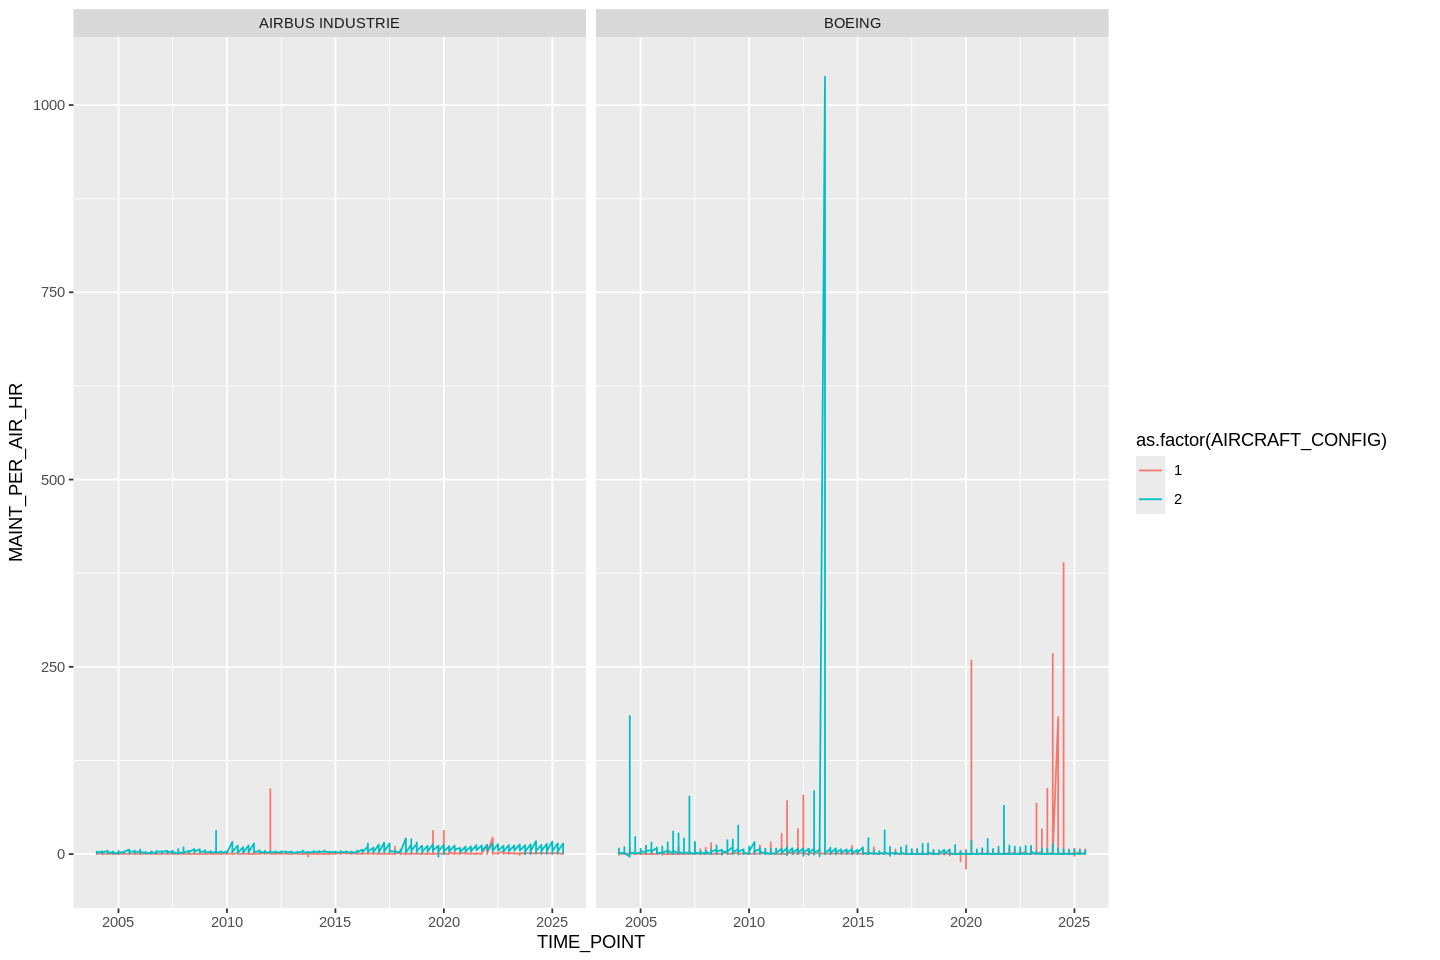

In [191]:
# plot maintainence per air hour over time
ggplot(df, aes(x = TIME_POINT)) + geom_line(aes(y = MAINT_PER_AIR_HR, color = as.factor(AIRCRAFT_CONFIG))) +
  facet_wrap(MANUFACTURER~.)

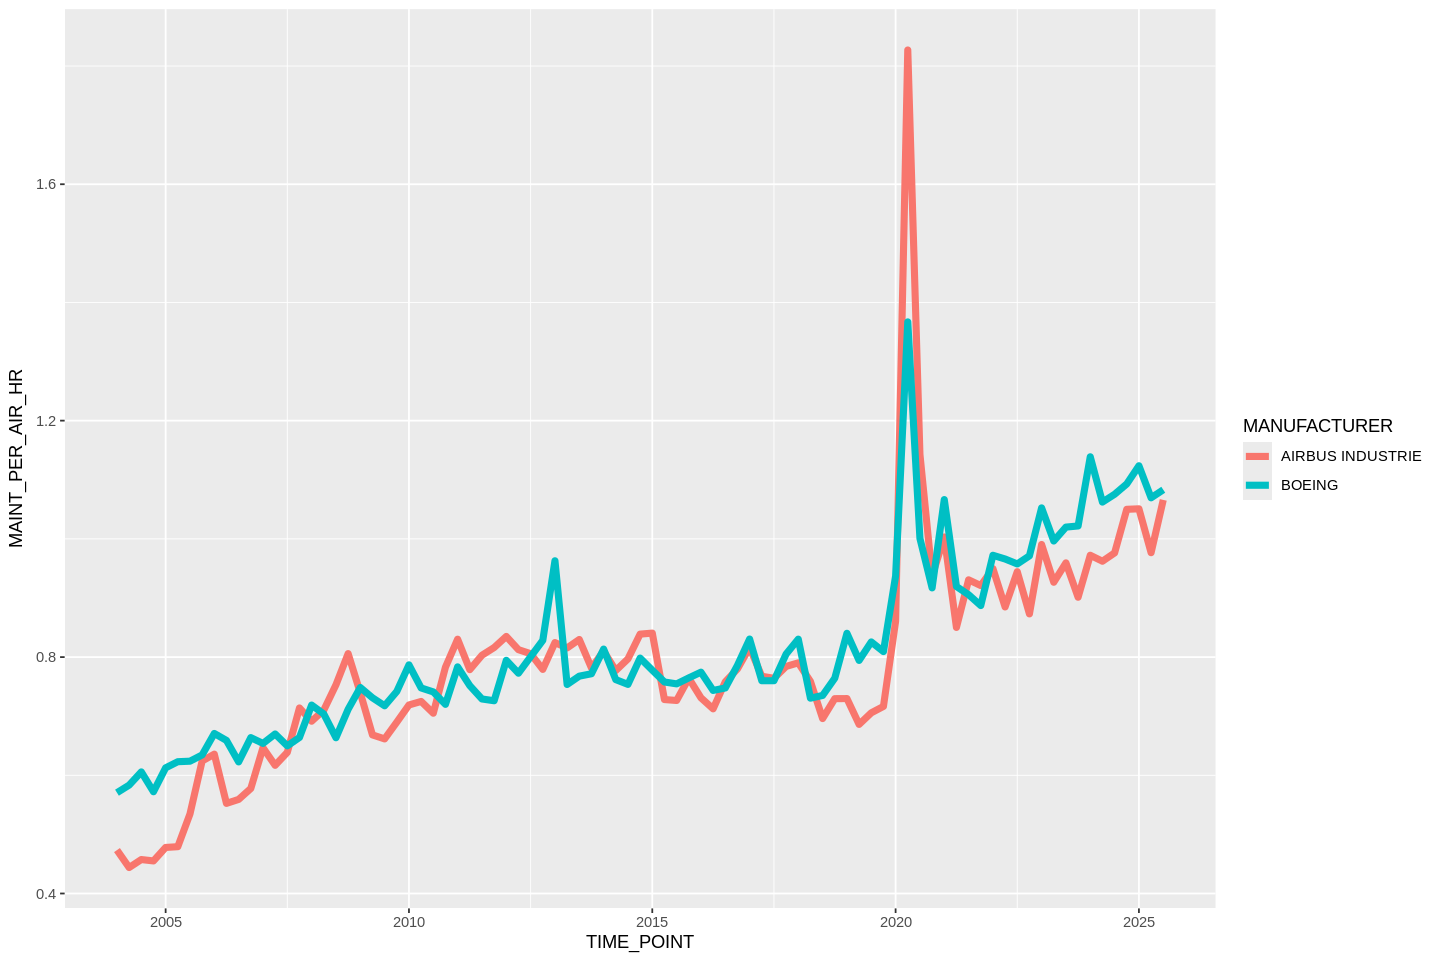

In [264]:
# Timeplot of total maintainance costs over time
eda <- ggplot(df_sarima, aes(x = TIME_POINT)) +
  geom_line(aes(y = MAINT_PER_AIR_HR, color = MANUFACTURER), size = 2) +
  scale_x_continuous(limits = c(min(df_sarima$TIME_POINT, na.rm = TRUE),
                                max(df_sarima$TIME_POINT, na.rm = TRUE)))

eda

# Create 'visuals' directory if it doesn't exist
if (!dir.exists("visuals")) {
  dir.create("visuals")
}

# Save the plot using ggsave
#ggsave(filename = "visuals/fit_1_eda.png", plot = eda, width = 10, height = 6, units = "in")

In [193]:
# data summary table
print("Summary of time analysed")
summary(df_sarima$TIME_POINT)

print("Summary of Response (MAINT_PER_AIR_HR)")
summary(df_sarima$MAINT_PER_AIR_HR)

[1] "Summary of time analysed"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2004    2009    2015    2015    2020    2026 

[1] "Summary of Response (MAINT_PER_AIR_HR)"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.4439  0.7128  0.7736  0.7988  0.8819  1.8271 

# Modeling:
1. SARIMA
2. ARIMAX
3. RNN

# SARIMA

In [194]:
df_boeing <- df_sarima %>%
  filter(MANUFACTURER == "BOEING") %>%
  arrange(TIME_POINT)

df_airbus <- df_sarima %>%
  filter(MANUFACTURER == "AIRBUS INDUSTRIE") %>%
  arrange(TIME_POINT)

y.t <- ts(df_boeing$MAINT_PER_AIR_HR,
          start = c(floor(min(df_boeing$TIME_POINT)), 1),
          frequency = 4)

y.t_airbus <- ts(df_airbus$MAINT_PER_AIR_HR,
                 start = c(floor(min(df_airbus$TIME_POINT)), 1),
                 frequency = 4)

# Boeing
x.t_train <- window(y.t, end = c(2023,4))
x.t_test  <- window(y.t, start = c(2024,1))
# Airbus
x.t_train_airbus <- window(y.t_airbus, end = c(2023,4))
x.t_test_airbus  <- window(y.t_airbus, start = c(2024,1))


# Replace names so modelling runs with train split only
y.t <- x.t_train # Boeing
y.t_airbus <- x.t_train_airbus

cbind(
  c("Boeing Train", "Boeing Test", "Airbus Train", "Airbus Test"),
  rbind( length(x.t_train),
        length(x.t_test),
        length(x.t_train_airbus),
        length(x.t_test_airbus)))

Boeing Train,80
Boeing Test,7
Airbus Train,80
Airbus Test,7


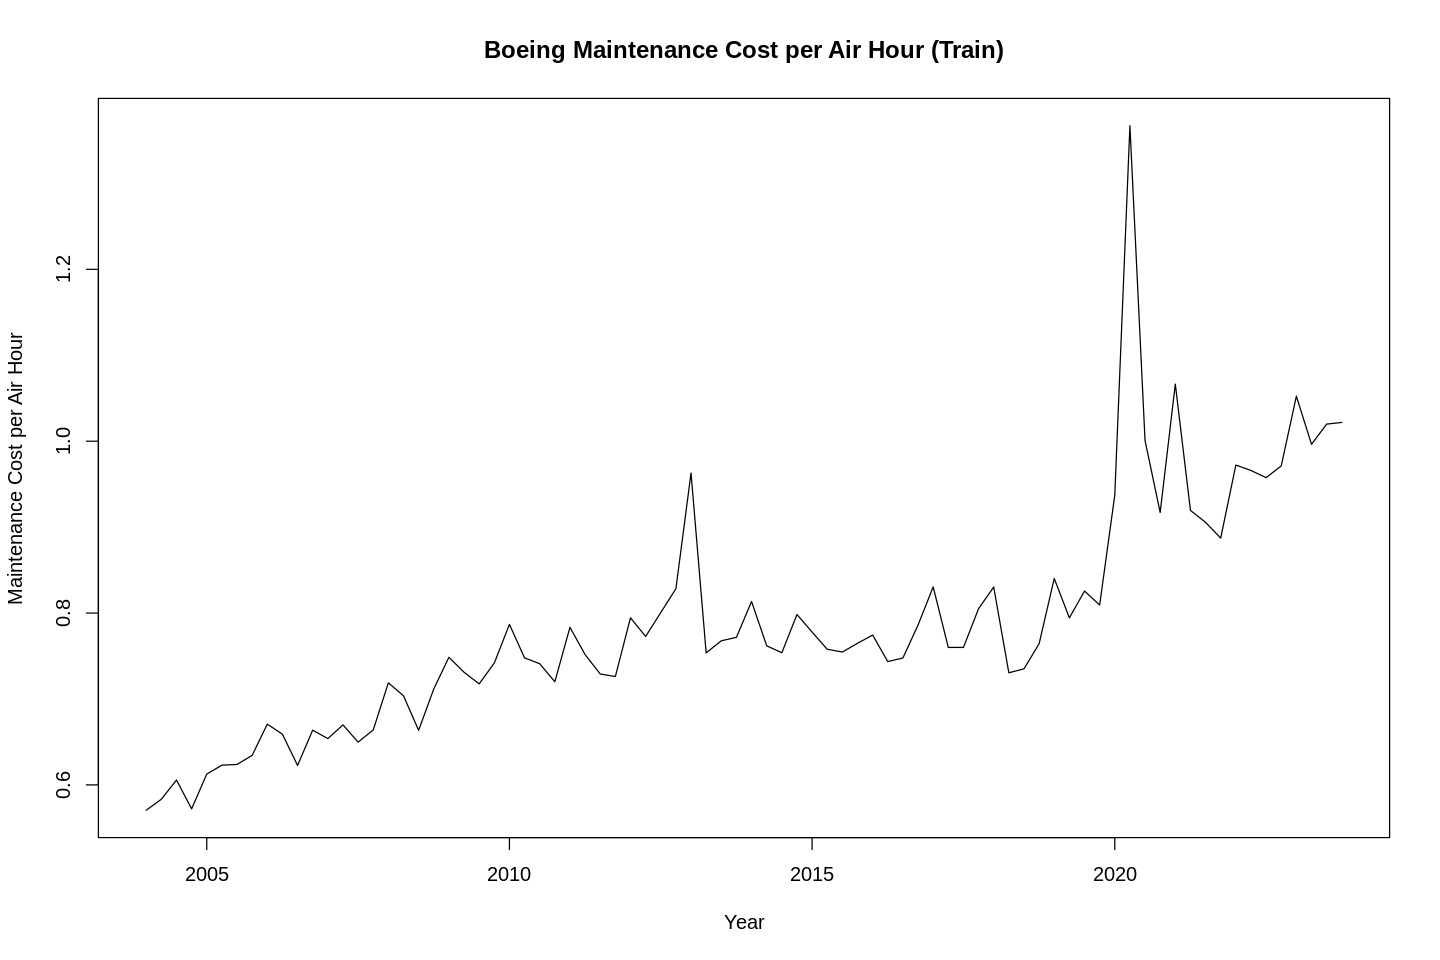

In [195]:
plot.ts(y.t,
        main = "Boeing Maintenance Cost per Air Hour (Train)",
        xlab = "Year",
        ylab = "Maintenance Cost per Air Hour")

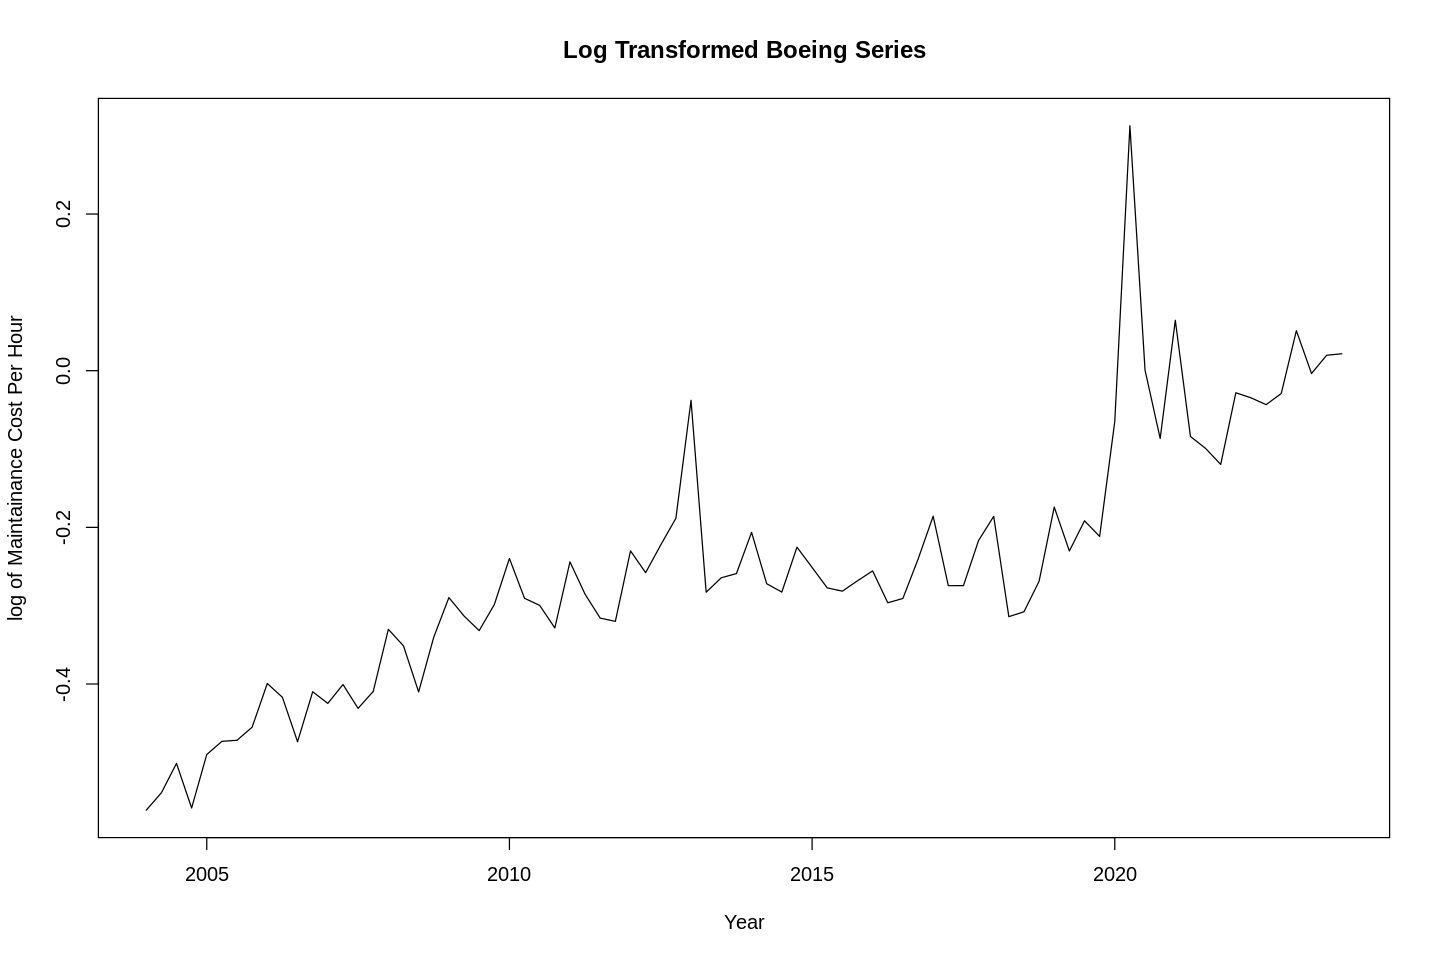

In [196]:
ly.t <- log(y.t)

plot.ts(ly.t,
        main = "Log Transformed Boeing Series",
        xlab = "Year",
        ylab = "log of Maintainance Cost Per Hour")

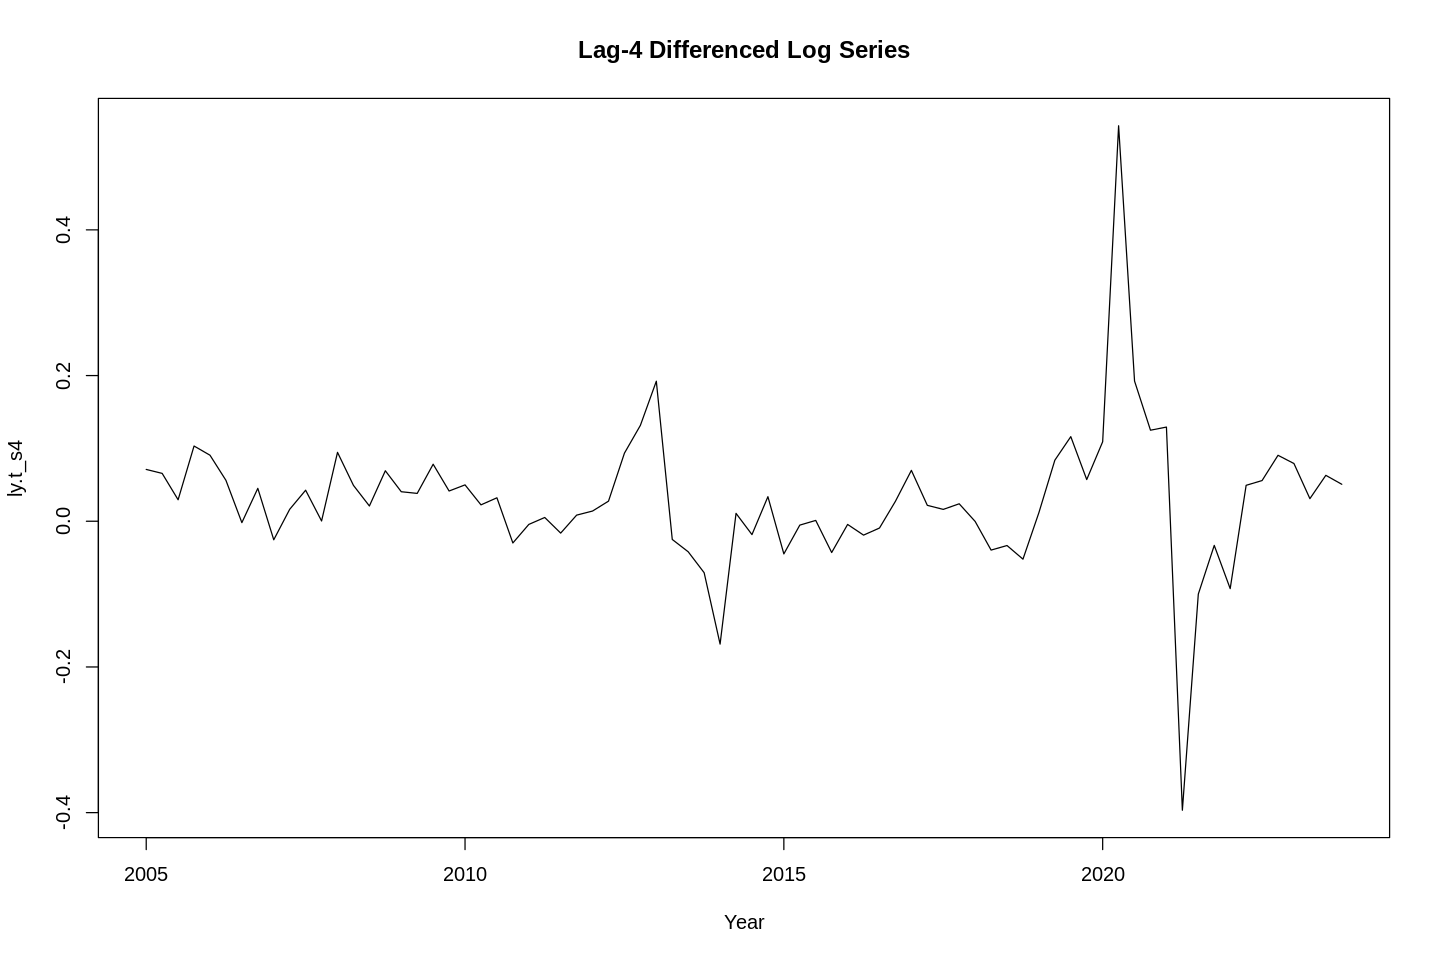

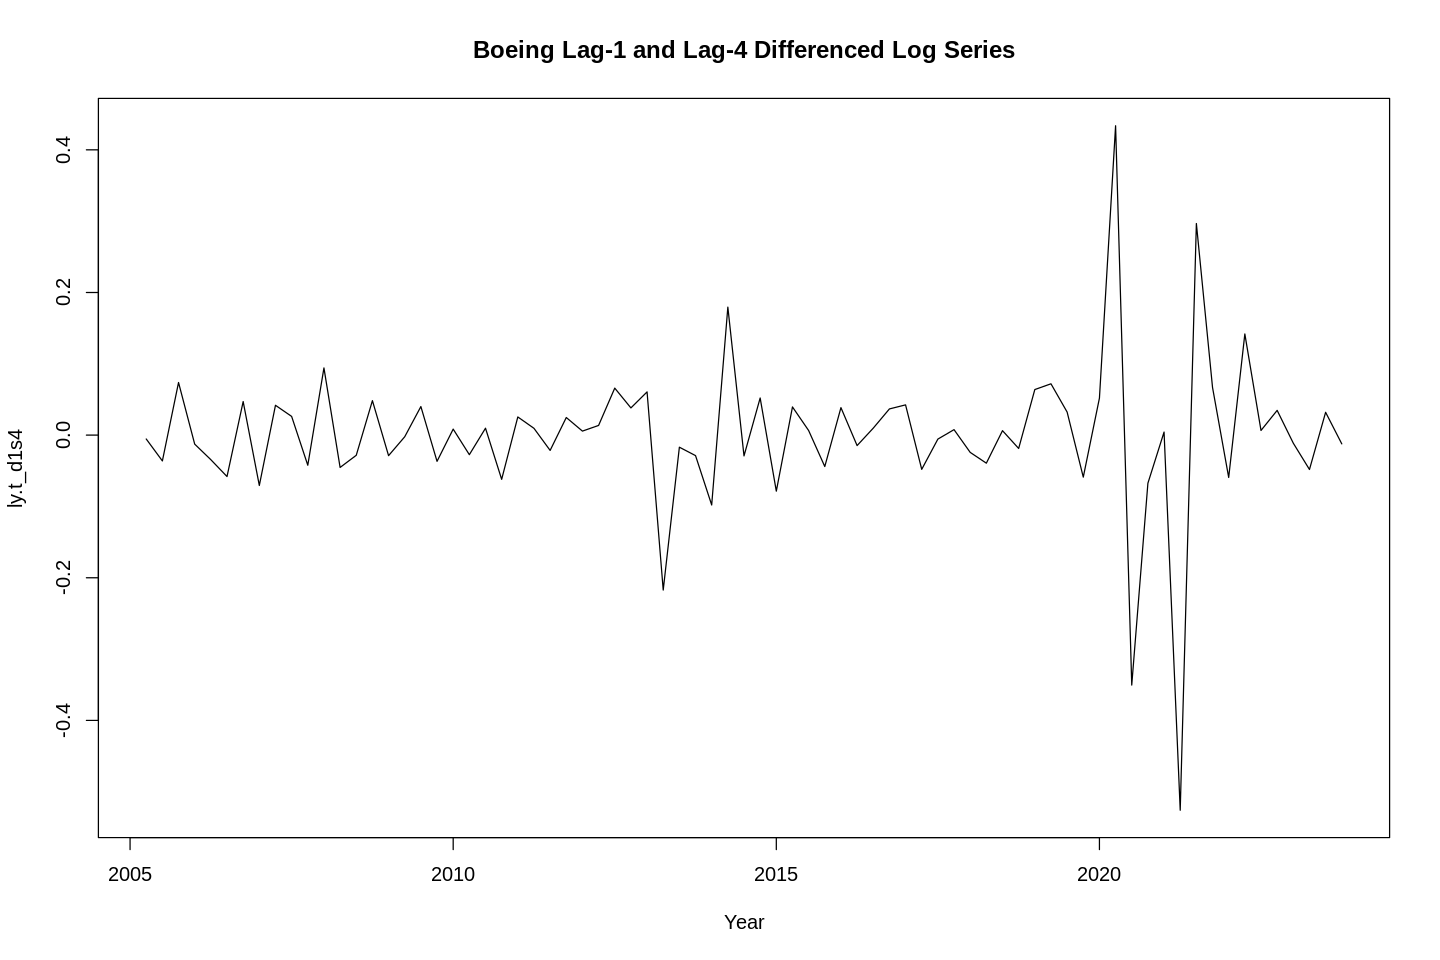

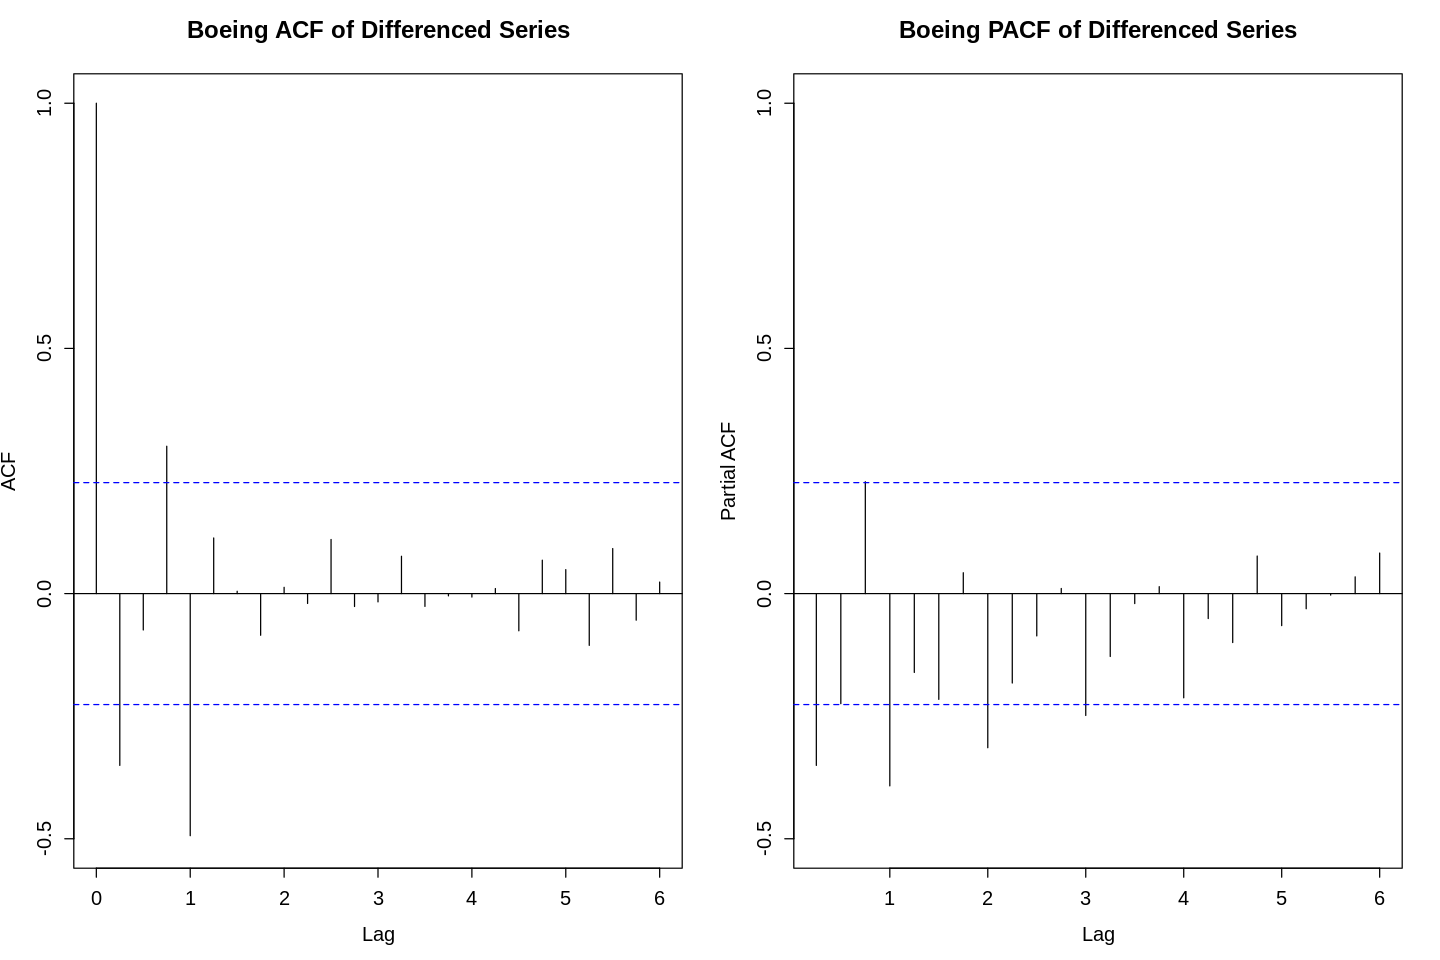

In [197]:
ly.t_s4 <- diff(ly.t, lag = 4)

plot.ts(ly.t_s4,
        main = "Lag-4 Differenced Log Series",
        xlab = "Year")

ly.t_d1s4 <- diff(ly.t_s4, differences = 1)

plot.ts(ly.t_d1s4,
        main = "Boeing Lag-1 and Lag-4 Differenced Log Series",
        xlab = "Year")

par(mfrow = c(1,2), mex = 0.75)
acf(ly.t_d1s4,
     ylim = c(-0.5, 1),
    lag.max = 24,
    main = "Boeing ACF of Differenced Series")
pacf(ly.t_d1s4,
     ylim = c(-0.5, 1),
     lag.max = 24,
     main = "Boeing PACF of Differenced Series")
par(mfrow = c(1,1))

In [198]:
arma.AICC <- function(...) {
  models <- list(...)
  model_names <- sapply(substitute(list(...)), deparse)[-1]

  aicc_values <- sapply(models, function(fit) {
    n.par <- length(fit$coef)
    n <- fit$nobs
    aicc <- -2 * fit$loglik + 2 * (n.par + 1) * n / (n - n.par - 2)
    return(aicc)
  })

  names(aicc_values) <- model_names
  return(aicc_values)
}

In [199]:
fit_011_011 <- arima(ly.t,
                     order = c(0,1,1),
                     seasonal = list(order = c(0,1,1), period = 4),
                     include.mean = FALSE)

fit_110_011 <- arima(ly.t,
                     order = c(1,1,0),
                     seasonal = list(order = c(0,1,1), period = 4),
                     include.mean = FALSE)

fit_111_011 <- arima(ly.t,
                     order = c(1,1,1),
                     seasonal = list(order = c(0,1,1), period = 4),
                     include.mean = FALSE)

fit_011_110 <- arima(ly.t,
                     order = c(0,1,1),
                     seasonal = list(order = c(1,1,0), period = 4),
                     include.mean = FALSE)

fit_011_111 <- arima(ly.t,
                     order = c(0,1,1),
                     seasonal = list(order = c(1,1,1), period = 4),
                     include.mean = FALSE)

fit_210_011 <- arima(ly.t,
                     order = c(2,1,0),
                     seasonal = list(order = c(0,1,1), period = 4),
                     include.mean = FALSE)

fit_012_011 <- arima(ly.t,
                     order = c(0,1,2),
                     seasonal = list(order = c(0,1,1), period = 4),
                     include.mean = FALSE)

In [200]:
IC_table <- data.frame(
  Model = c("SARIMA(0,1,1)(0,1,1)[4]",
            "SARIMA(1,1,0)(0,1,1)[4]",
            "SARIMA(1,1,1)(0,1,1)[4]",
            "SARIMA(0,1,1)(1,1,0)[4]",
            "SARIMA(0,1,1)(1,1,1)[4]",
            "SARIMA(2,1,0)(0,1,1)[4]",
            "SARIMA(0,1,2)(0,1,1)[4]"),

  AIC = c(AIC(fit_011_011),
          AIC(fit_110_011),
          AIC(fit_111_011),
          AIC(fit_011_110),
          AIC(fit_011_111),
          AIC(fit_210_011),
          AIC(fit_012_011)),

  BIC = c(BIC(fit_011_011),
          BIC(fit_110_011),
          BIC(fit_111_011),
          BIC(fit_011_110),
          BIC(fit_011_111),
          BIC(fit_210_011),
          BIC(fit_012_011)),

  AICC = arma.AICC(fit_011_011,
                   fit_110_011,
                   fit_111_011,
                   fit_011_110,
                   fit_011_111,
                   fit_210_011,
                   fit_012_011)
)

IC_table <- IC_table[order(IC_table$AICC), ]
IC_table

,Model,AIC,BIC,AICC
,<chr>,<dbl>,<dbl>,<dbl>
fit_210_011,"SARIMA(2,1,0)(0,1,1)[4]",-169.2890,-160.0190,-168.7175
fit_012_011,"SARIMA(0,1,2)(0,1,1)[4]",-169.2398,-159.9699,-168.6684
fit_011_011,"SARIMA(0,1,1)(0,1,1)[4]",-168.9115,-161.9591,-168.5735
fit_111_011,"SARIMA(1,1,1)(0,1,1)[4]",-168.6618,-159.3919,-168.0904
fit_011_111,"SARIMA(0,1,1)(1,1,1)[4]",-166.9243,-157.6543,-166.3529
fit_110_011,"SARIMA(1,1,0)(0,1,1)[4]",-162.9205,-155.9681,-162.5825
fit_011_110,"SARIMA(0,1,1)(1,1,0)[4]",-144.6565,-137.7040,-144.3184


In [201]:
fit_bst <- fit_011_011
fit_bst


Call:
arima(x = ly.t, order = c(0, 1, 1), seasonal = list(order = c(0, 1, 1), period = 4), 
    include.mean = FALSE)

Coefficients:
          ma1     sma1
      -0.5079  -1.0000
s.e.   0.1223   0.1051

sigma^2 estimated as 0.004821:  log likelihood = 87.46,  aic = -168.91

In [202]:
coef_est <- fit_bst$coef
coef_se <- sqrt(diag(fit_bst$var.coef))
z_value <- coef_est / coef_se
p_value <- 2 * (1 - pnorm(abs(z_value)))

param_table <- data.frame(
  Estimate = coef_est,
  Std_Error = coef_se,
  z_value = z_value,
  p_value = p_value,
  CI_Lower = coef_est - 1.96 * coef_se,
  CI_Upper = coef_est + 1.96 * coef_se
)

round(param_table, 4)

,Estimate,Std_Error,z_value,p_value,CI_Lower,CI_Upper
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ma1,-0.5079,0.1223,-4.1520,0,-0.7477,-0.2681
sma1,-1.0000,0.1051,-9.5155,0,-1.2060,-0.7940


In [203]:
w.t <- fit_bst$residuals

w_mean <- mean(w.t)
w_sd <- sd(w.t)

round(cbind(w_mean, w_sd), 5)
summary(w.t)

w_mean,w_sd
-0.00389,0.06754


     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-0.163280 -0.029740 -0.005228 -0.003892  0.018842  0.454102 

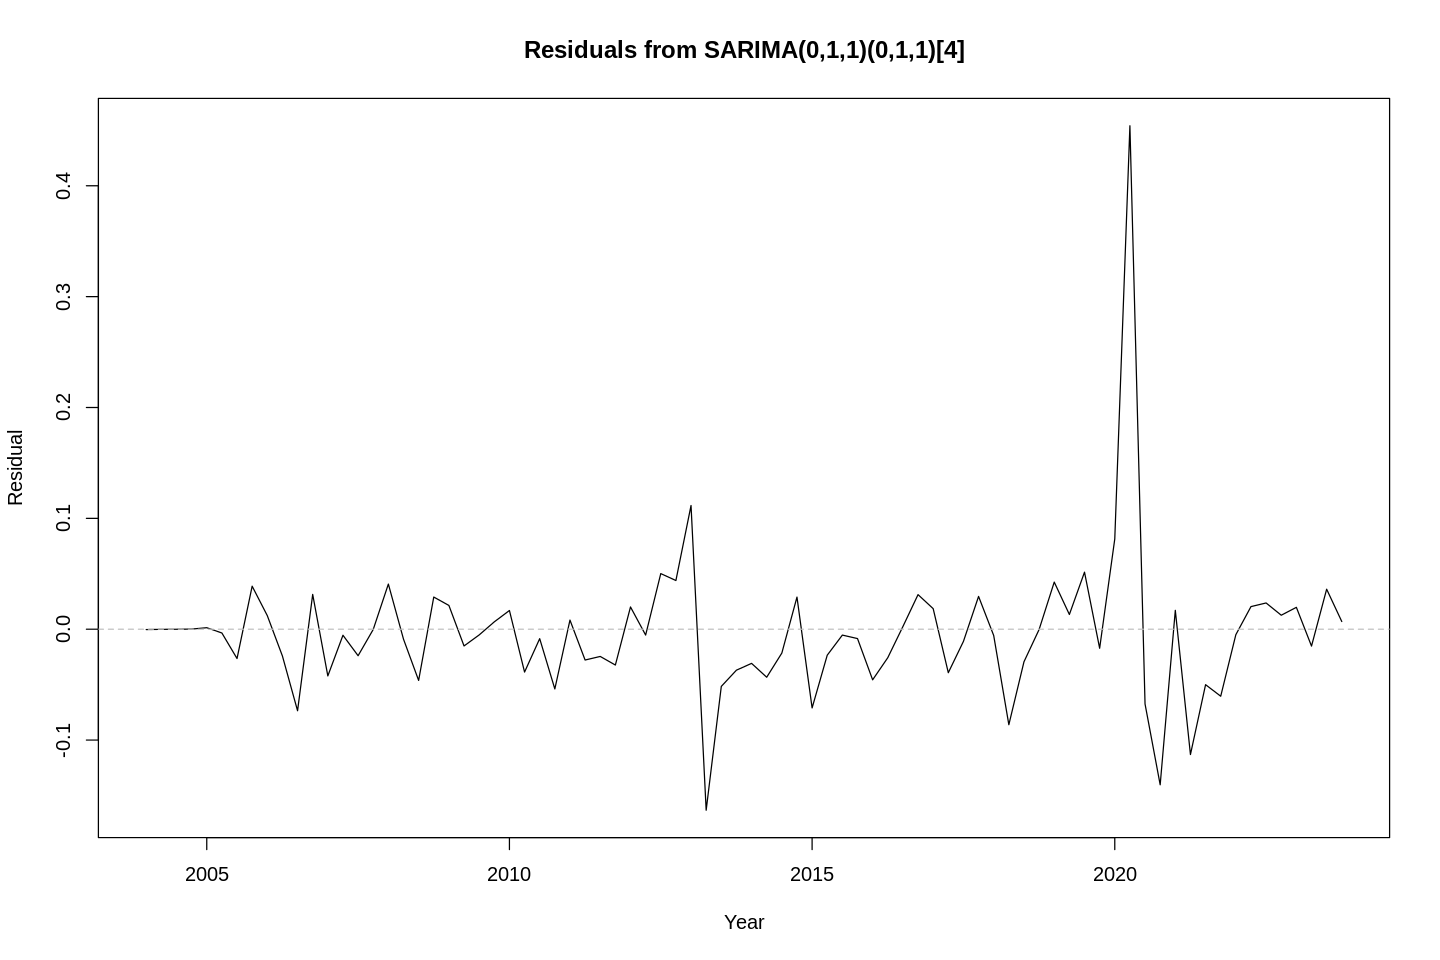

In [204]:
plot.ts(w.t,
        main = "Residuals from SARIMA(0,1,1)(0,1,1)[4]",
        xlab = "Year",
        ylab = "Residual")
abline(h = 0, col = "grey", lty = "dashed")

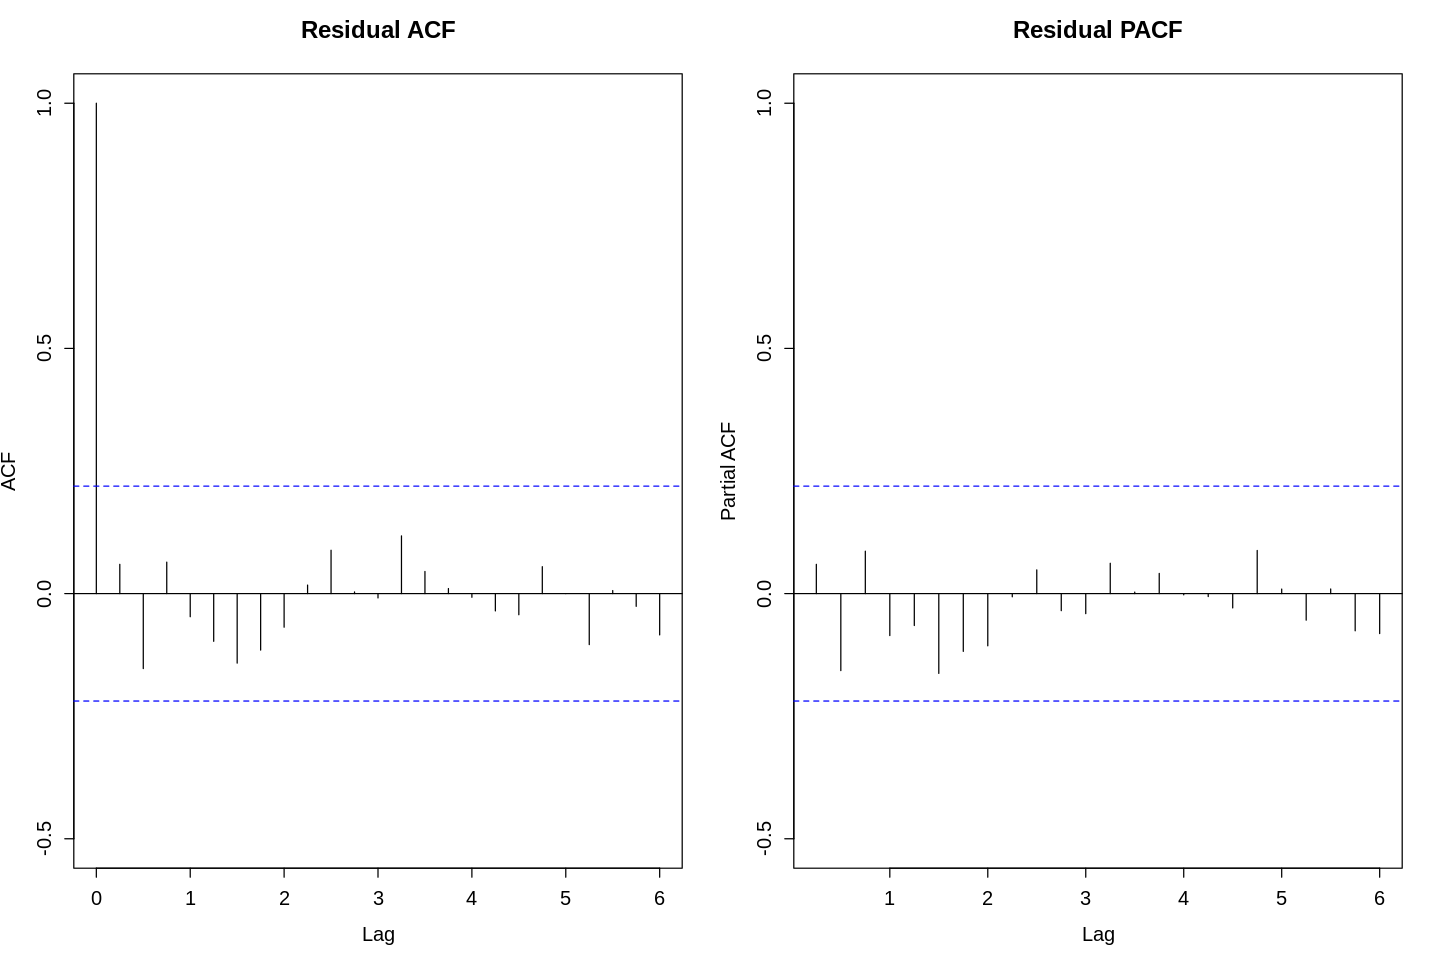

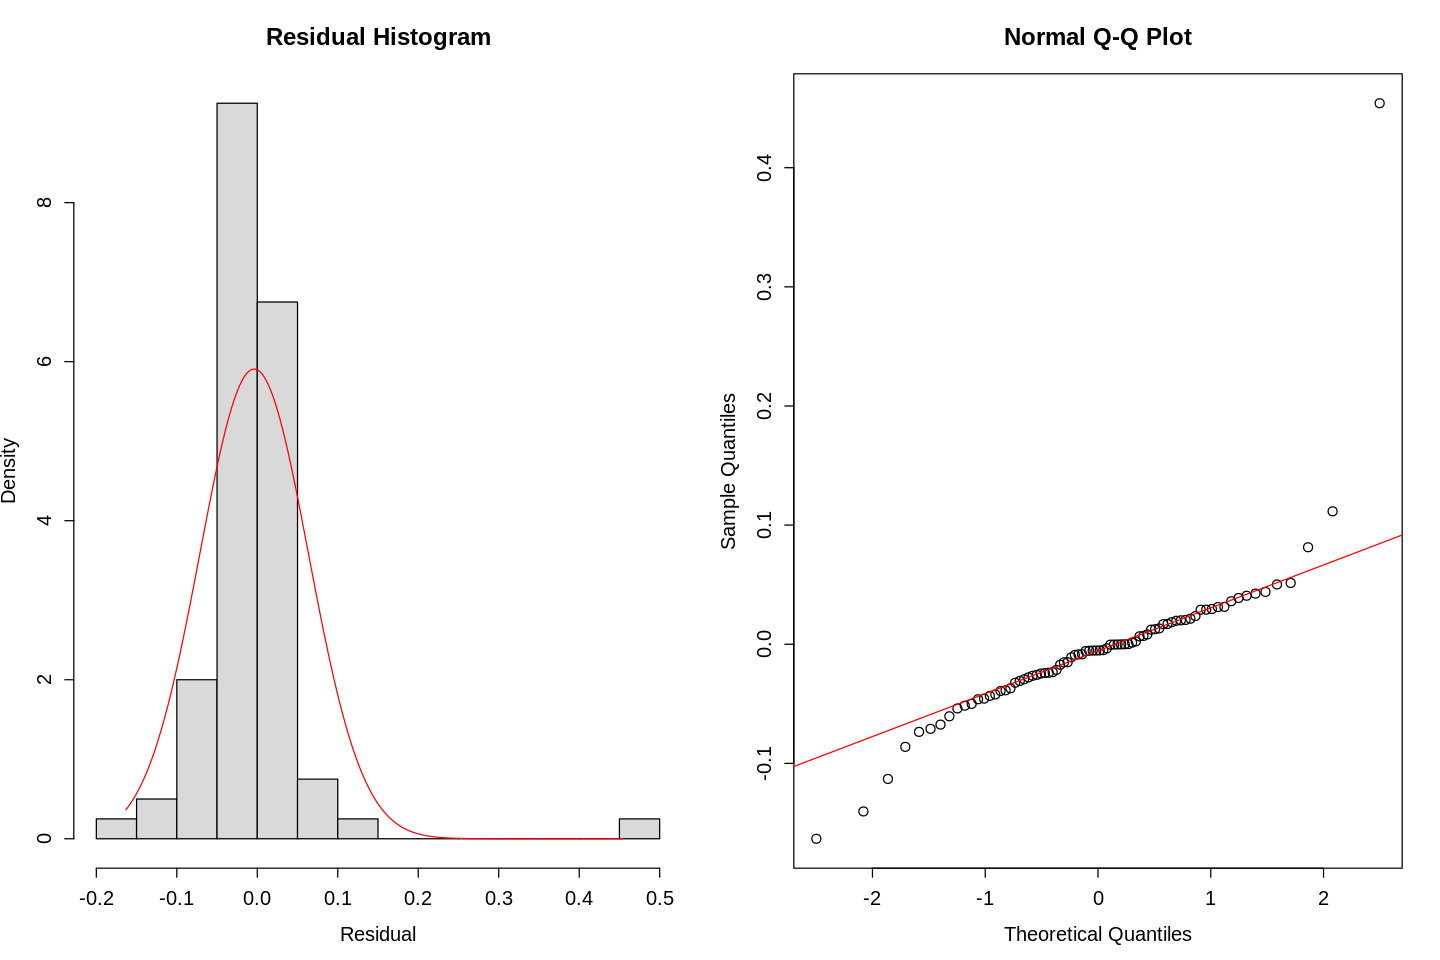

In [205]:
par(mfrow = c(1,2), mex = 0.75)
acf(w.t,
    ylim = c(-0.5, 1),
    lag.max = 24,
    main = "Residual ACF")
pacf(w.t,
    ylim = c(-0.5, 1),
     lag.max = 24,
     main = "Residual PACF")
par(mfrow = c(1,1))

par(mfrow = c(1,2), mex = 0.75)

hist(w.t,
     freq = FALSE,
     breaks = 15,
     col = "grey85",
     main = "Residual Histogram",
     xlab = "Residual")

z <- seq(min(w.t), max(w.t), length = 1000)

lines(z,
      dnorm(z, mean = w_mean, sd = w_sd),
      col = "red")

qqnorm(w.t)
qqline(w.t, col = "red")

In [206]:
par(mfrow = c(1,1))

shapiro.test(w.t)
ks.test(w.t, "pnorm", mean = w_mean, sd = w_sd)

n.par <- length(fit_bst$coef)

Box.test(w.t, lag = 8, type = "Ljung-Box", fitdf = n.par)
Box.test(w.t, lag = 12, type = "Ljung-Box", fitdf = n.par)
Box.test(w.t, lag = 16, type = "Ljung-Box", fitdf = n.par)


	Shapiro-Wilk normality test

data:  w.t
W = 0.68107, p-value = 6.81e-12



	Exact one-sample Kolmogorov-Smirnov test

data:  w.t
D = 0.17704, p-value = 0.01154
alternative hypothesis: two-sided



	Box-Ljung test

data:  w.t
X-squared = 7.0326, df = 6, p-value = 0.3178



	Box-Ljung test

data:  w.t
X-squared = 7.8007, df = 10, p-value = 0.6483



	Box-Ljung test

data:  w.t
X-squared = 9.3742, df = 14, p-value = 0.8064


In [207]:
prd <- predict(fit_bst, n.ahead = length(x.t_test))

log_fc_boeing_sarima <- as.numeric(prd$pred)
log_se_boeing_sarima <- as.numeric(prd$se)


fc_boeing_sarima <- exp(log_fc_boeing_sarima)

lower_95 <- pmax(exp(log_fc_boeing_sarima - 1.96 * log_se_boeing_sarima), min(y.t))
upper_95 <- pmin(exp(log_fc_boeing_sarima + 1.96 * log_se_boeing_sarima), max(y.t) * 2)

fc_start <- tsp(y.t)[2] + 1/4

fc.ts <- ts(fc_boeing_sarima,
            start = fc_start,
            frequency = 4)

lower.ts <- ts(lower_95,
               start = fc_start,
               frequency = 4)

upper.ts <- ts(upper_95,
               start = fc_start,
               frequency = 4)

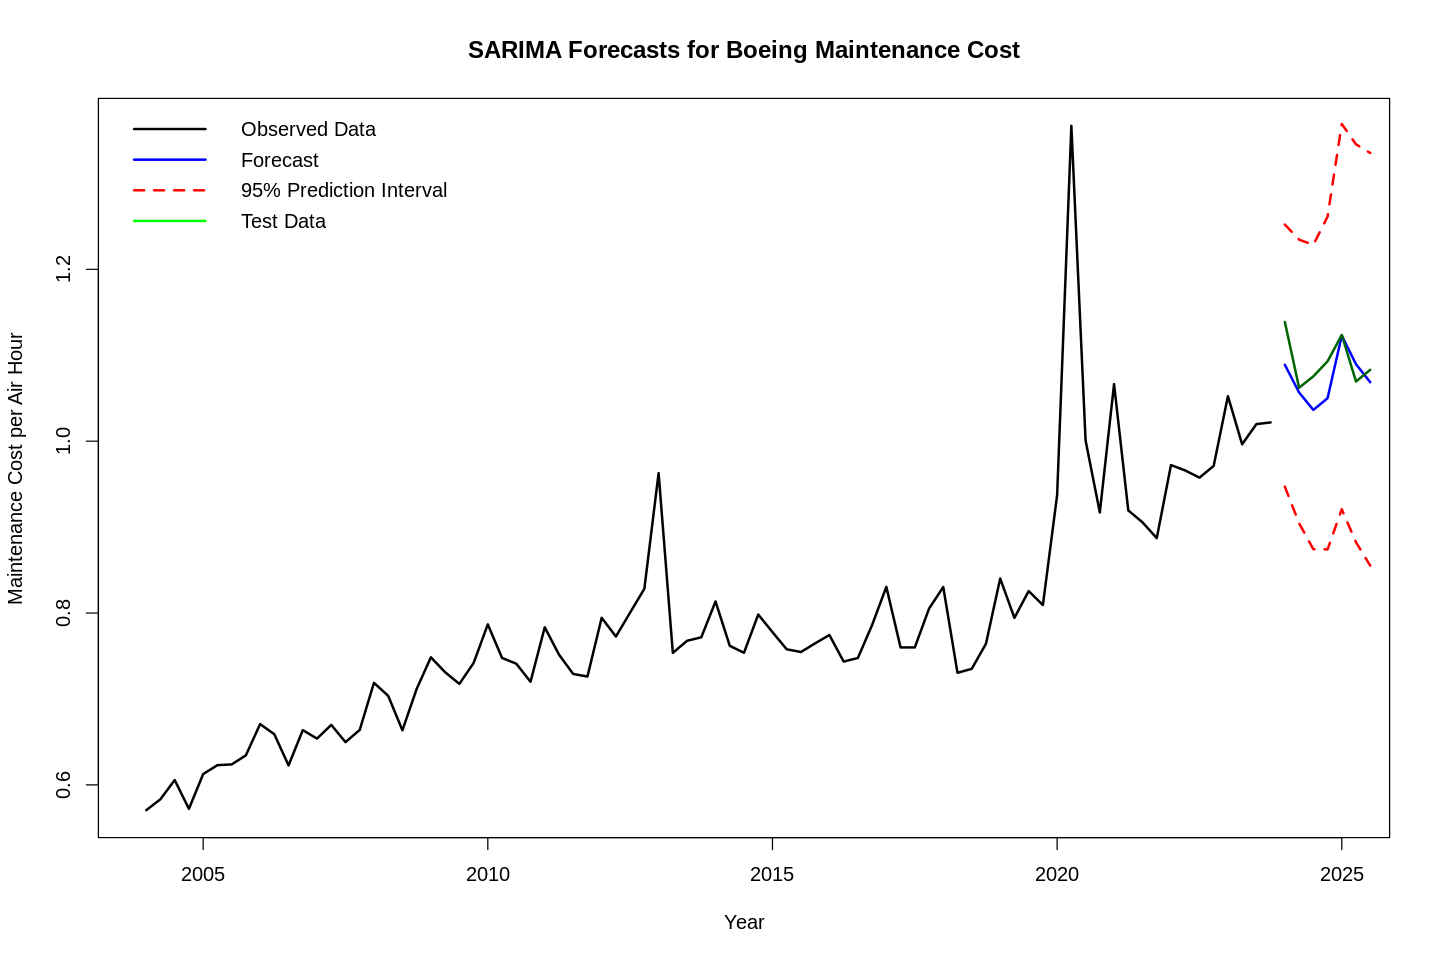

In [208]:
plot.ts(y.t,
        xlim = c(start(y.t)[1], end(y.t)[1] + 2),
        main = "SARIMA Forecasts for Boeing Maintenance Cost",
        xlab = "Year",
        ylab = "Maintenance Cost per Air Hour",
        col = "black",
        lwd = 2)

lines(fc.ts, col = "blue", lwd = 2)
lines(lower.ts, col = "red", lty = 2, lwd = 2)
lines(upper.ts, col = "red", lty = 2, lwd = 2)
lines(x.t_test, col = "dark green", lty = 1, lwd = 2)

legend("topleft",
       legend = c("Observed Data", "Forecast", "95% Prediction Interval", "Test Data"),
       col = c("black", "blue", "red", "green"),
       lty = c(1, 1, 2, 1),
       lwd = c(2, 2, 2, 2),
       bty = "n")

In [209]:
forecast_table <- data.frame(
  Quarter_Ahead = 1:length(x.t_test),
  Forecast = fc_boeing_sarima,
  Lower_95 = lower_95,
  Upper_95 = upper_95
)

round(forecast_table, 5)

Quarter_Ahead,Forecast,Lower_95,Upper_95
<dbl>,<dbl>,<dbl>,<dbl>
1,1.08899,0.94710,1.25213
2,1.05673,0.90450,1.23457
3,1.03642,0.87438,1.22848
4,1.05001,0.87412,1.26129
5,1.12284,0.92081,1.36920
6,1.08958,0.88235,1.34548
7,1.06864,0.85516,1.33540


**SARIMA for Airbus**

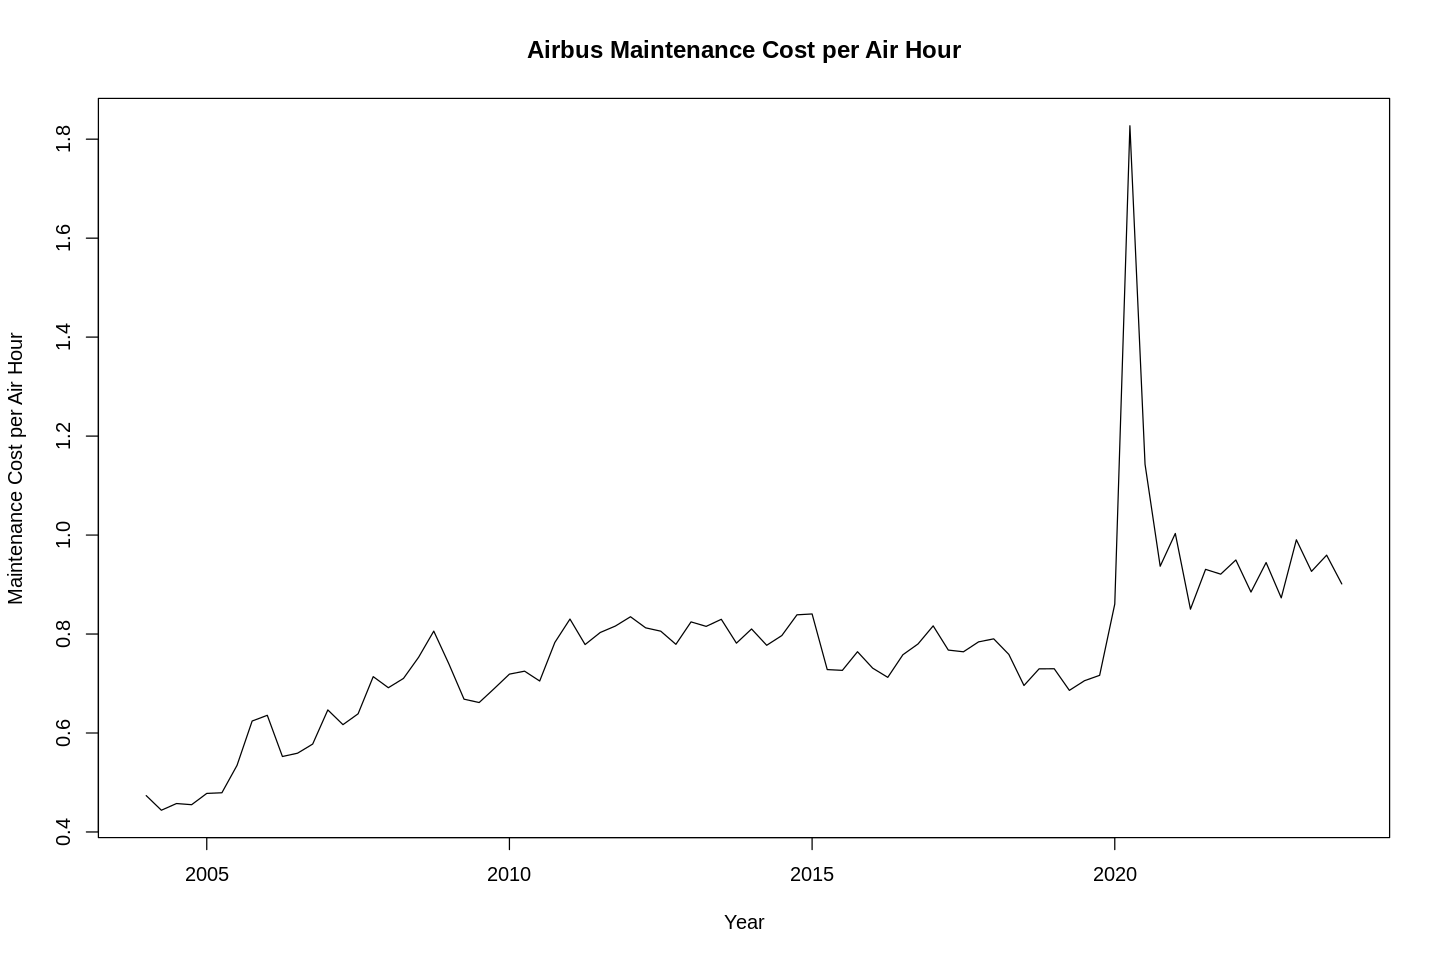

In [210]:
plot.ts(y.t_airbus,
        main = "Airbus Maintenance Cost per Air Hour",
        xlab = "Year",
        ylab = "Maintenance Cost per Air Hour")

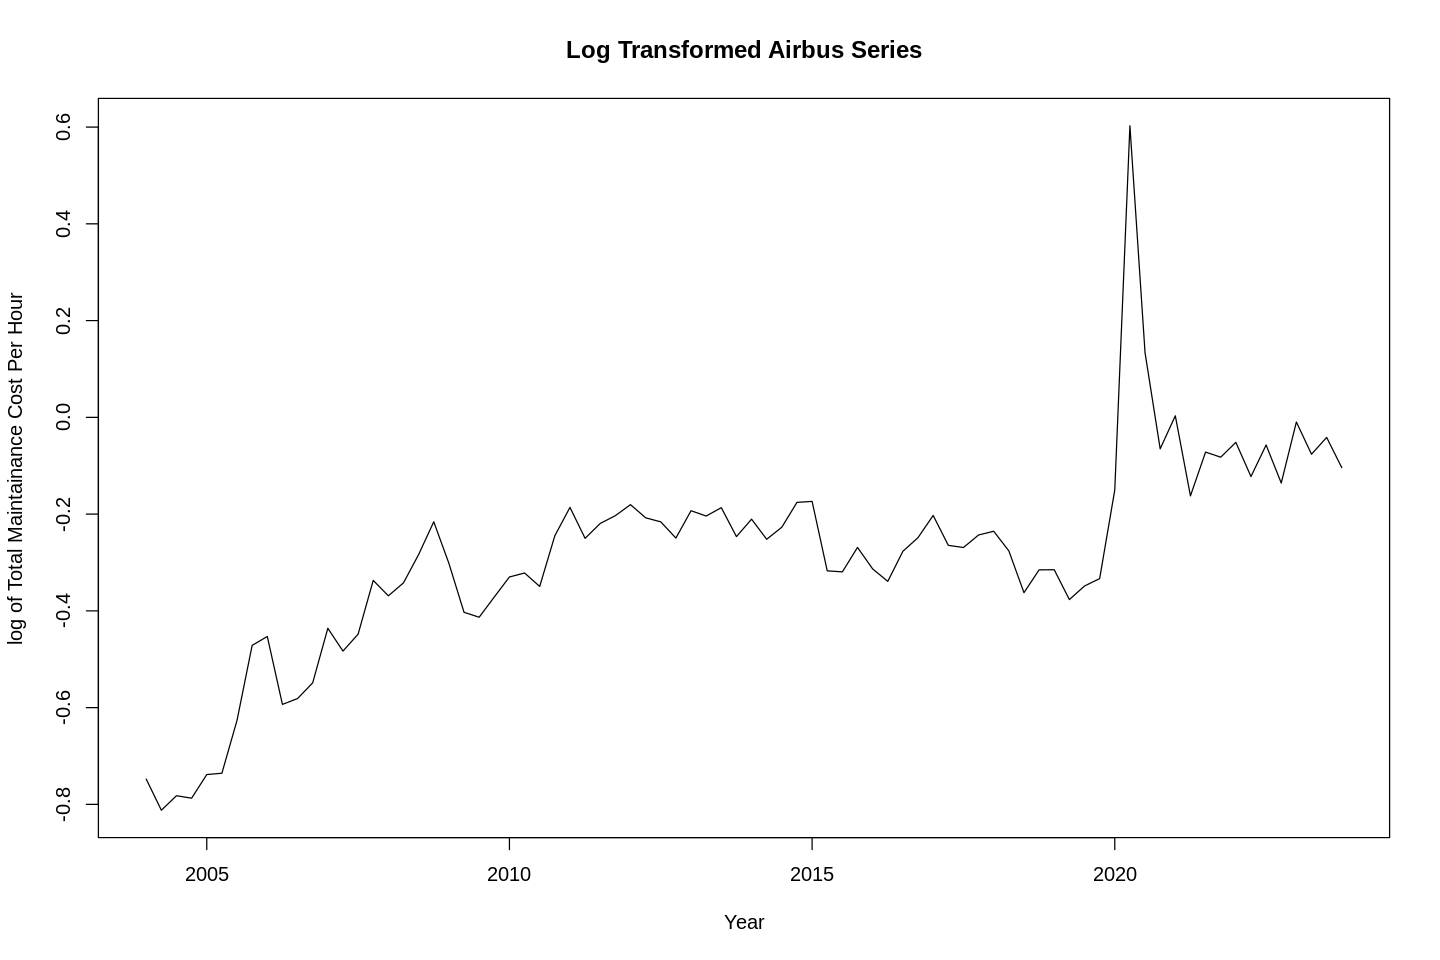

In [211]:
ly.t_airbus <- log(y.t_airbus)

plot.ts(ly.t_airbus,
        main = "Log Transformed Airbus Series",
        xlab = "Year",
        ylab = "log of Total Maintainance Cost Per Hour")

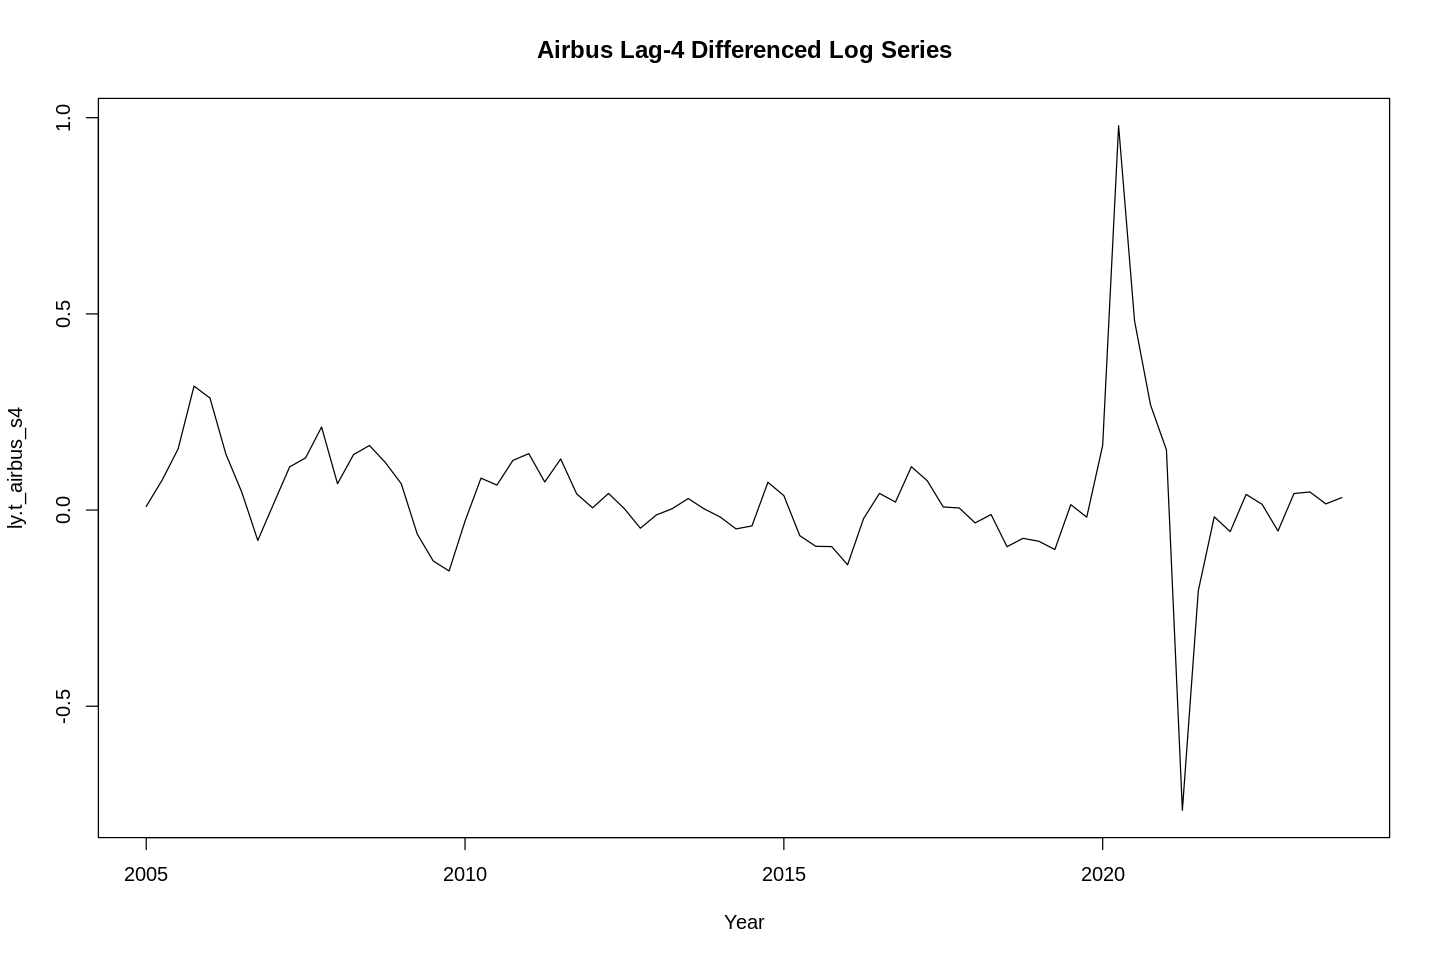

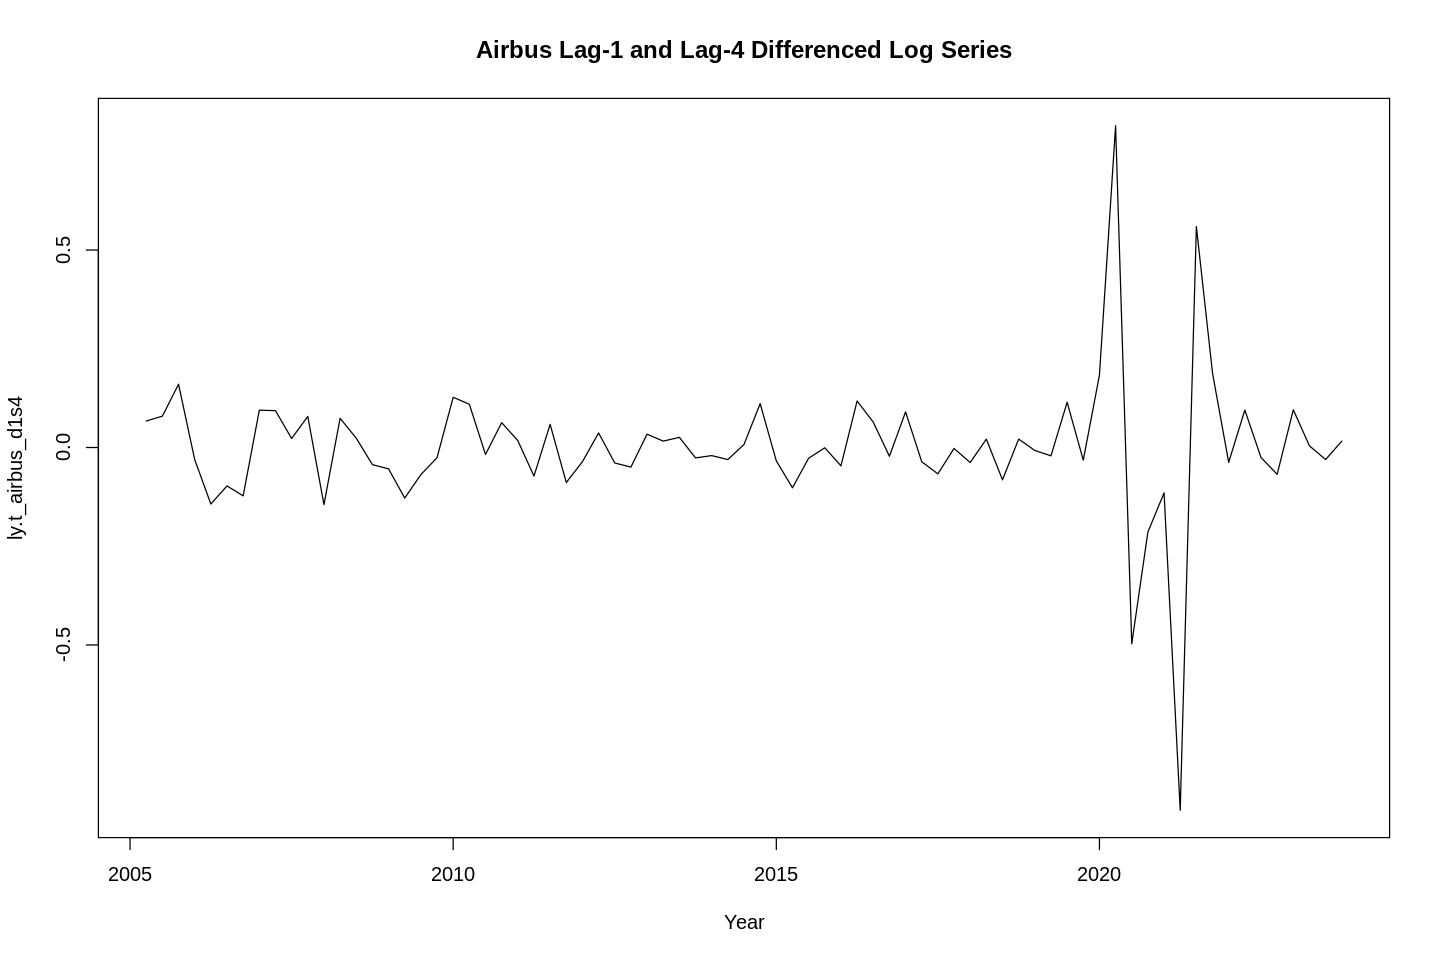

In [212]:
ly.t_airbus_s4 <- diff(ly.t_airbus, lag = 4)

plot.ts(ly.t_airbus_s4,
        main = "Airbus Lag-4 Differenced Log Series",
        xlab = "Year")

ly.t_airbus_d1s4 <- diff(ly.t_airbus_s4, differences = 1)

plot.ts(ly.t_airbus_d1s4,
        main = "Airbus Lag-1 and Lag-4 Differenced Log Series",
        xlab = "Year")

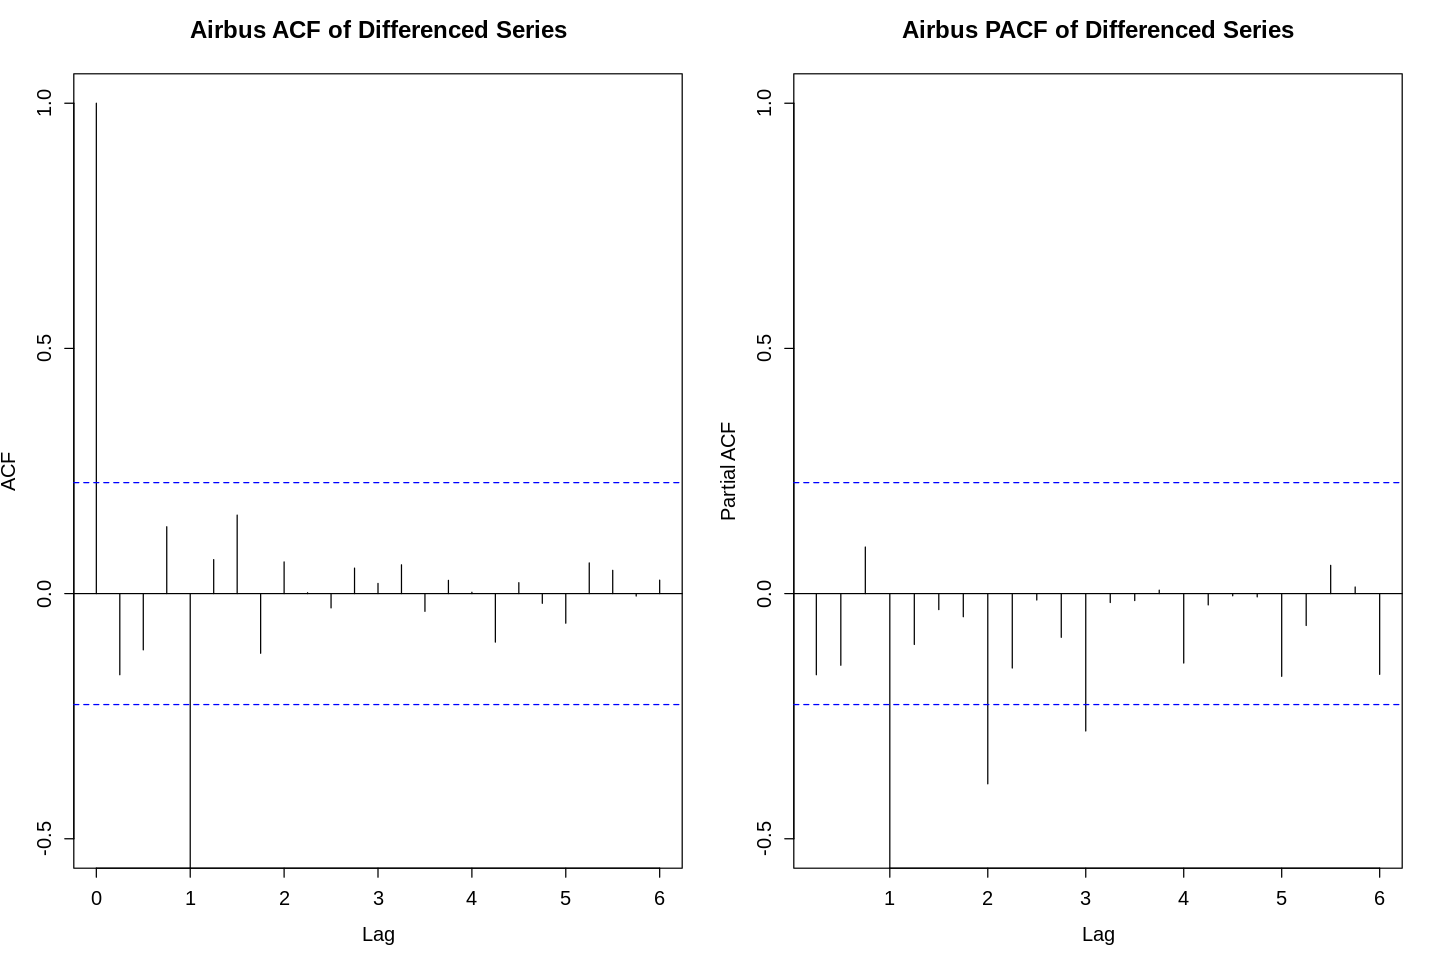

In [213]:
par(mfrow = c(1,2), mex = 0.75)
acf(ly.t_airbus_d1s4, ylim = c(-0.5, 1), lag.max = 24,
    main = "Airbus ACF of Differenced Series")
pacf(ly.t_airbus_d1s4, ylim = c(-0.5, 1), lag.max = 24,
     main = "Airbus PACF of Differenced Series")
par(mfrow = c(1,1))

fit_airbus <- arima(ly.t_airbus,
                    order = c(0,1,1),
                    seasonal = list(order = c(0,1,1), period = 4),
                    include.mean = FALSE)

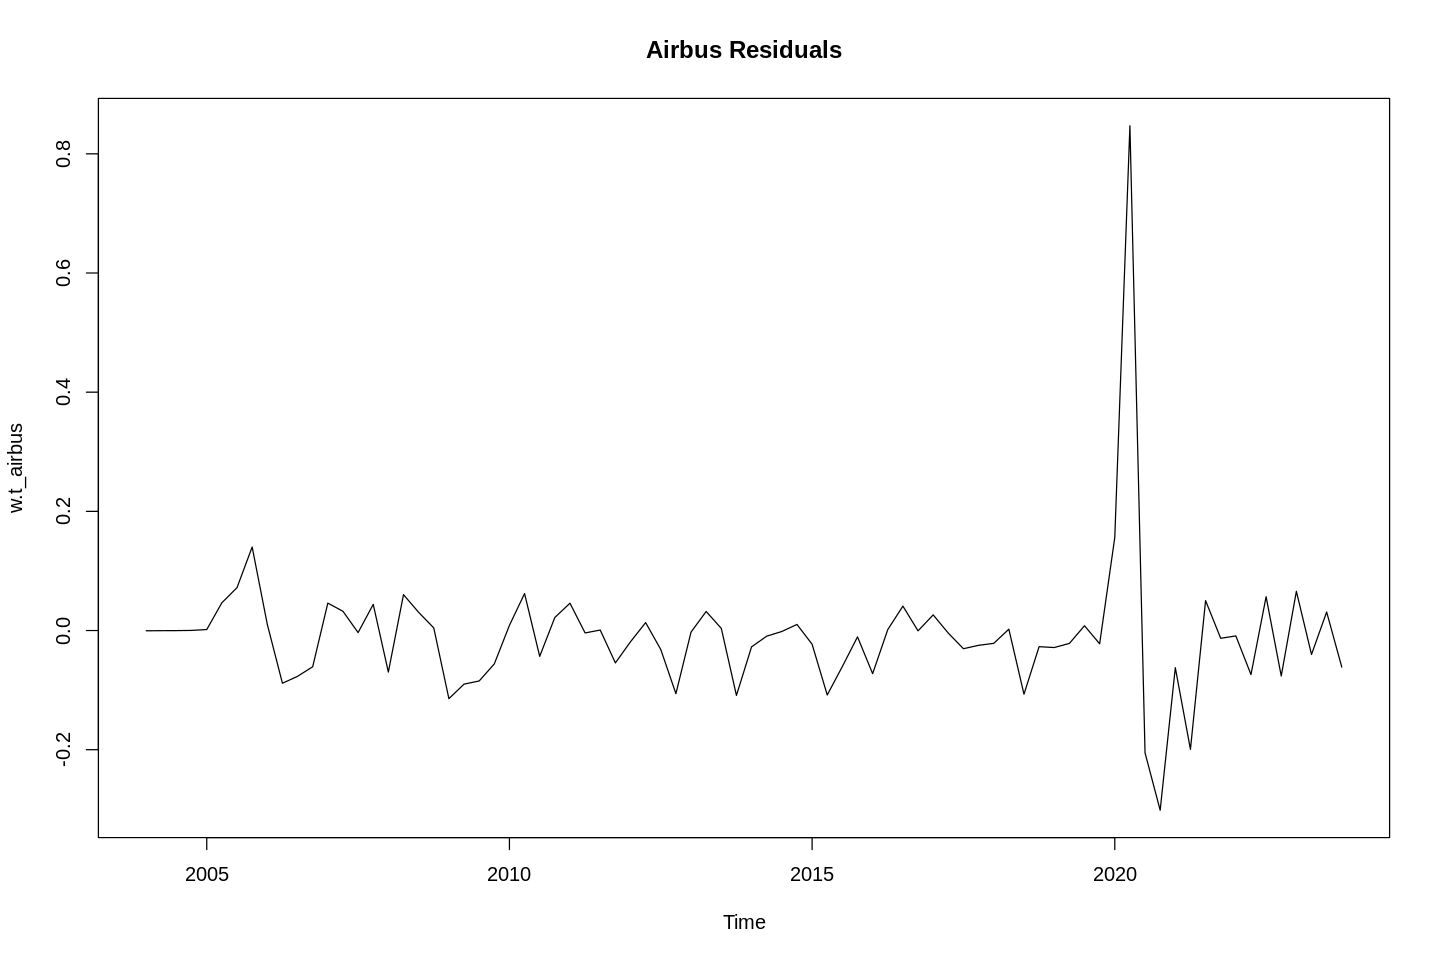

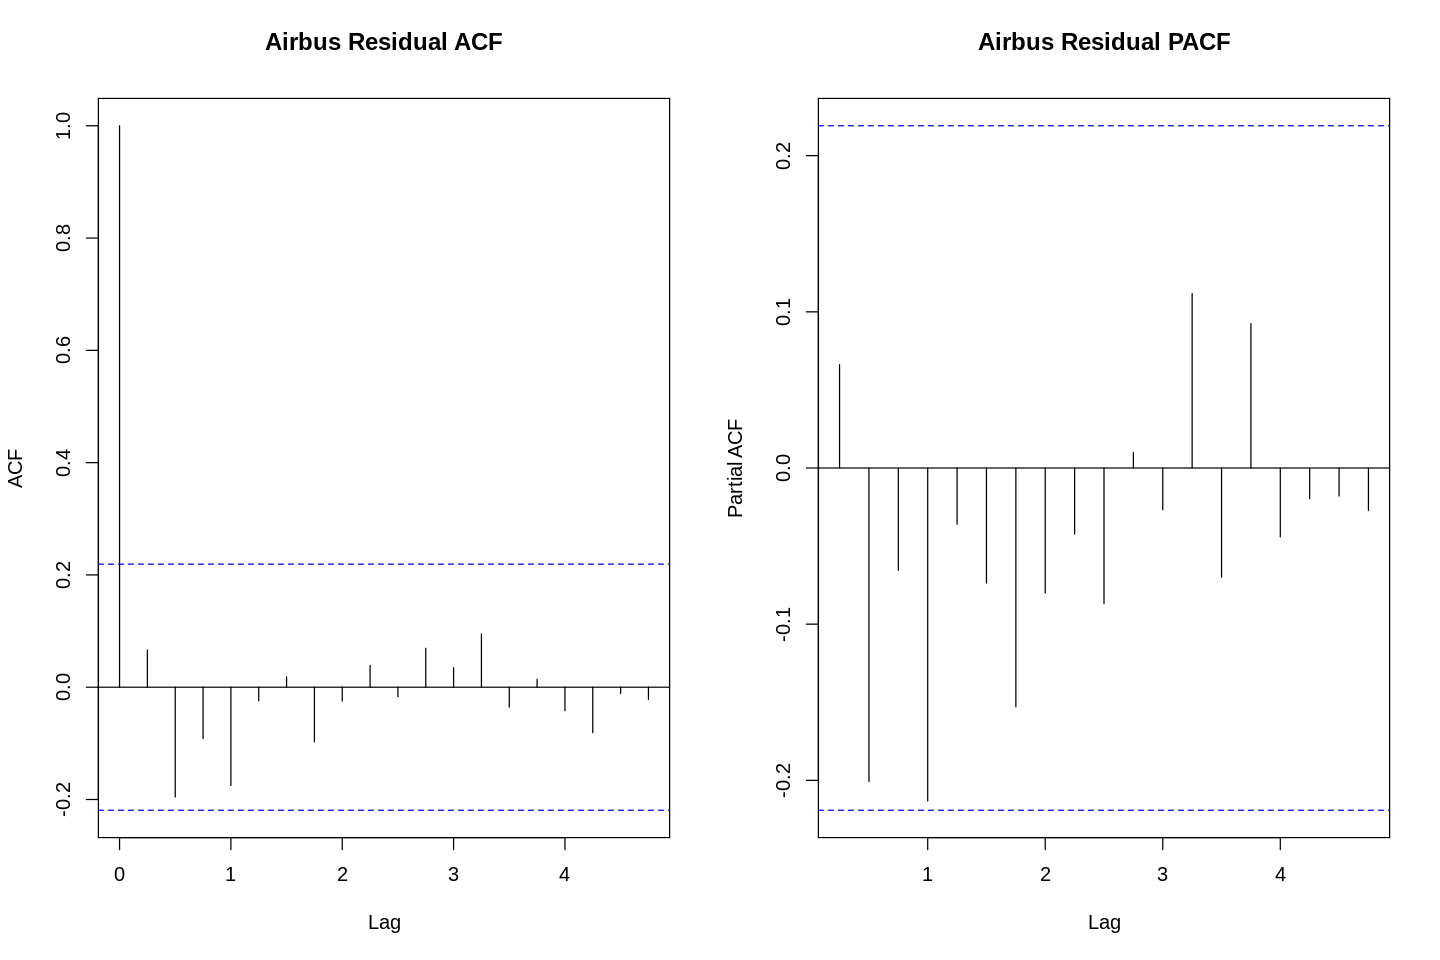

In [214]:
w.t_airbus <- residuals(fit_airbus)

plot.ts(w.t_airbus,
        main = "Airbus Residuals")

par(mfrow = c(1,2))
acf(w.t_airbus, main = "Airbus Residual ACF")
pacf(w.t_airbus, main = "Airbus Residual PACF")
par(mfrow = c(1,1))

In [215]:
par(mfrow = c(1,1))

shapiro.test(w.t_airbus)
ks.test(w.t_airbus, "pnorm", mean = w_mean, sd = w_sd)

n.par <- length(fit_bst$coef)

Box.test(w.t_airbus, lag = 8, type = "Ljung-Box", fitdf = n.par)
Box.test(w.t_airbus, lag = 12, type = "Ljung-Box", fitdf = n.par)
Box.test(w.t_airbus, lag = 16, type = "Ljung-Box", fitdf = n.par)


	Shapiro-Wilk normality test

data:  w.t_airbus
W = 0.59478, p-value = 1.59e-13



	Exact one-sample Kolmogorov-Smirnov test

data:  w.t_airbus
D = 0.15358, p-value = 0.04104
alternative hypothesis: two-sided



	Box-Ljung test

data:  w.t_airbus
X-squared = 7.9169, df = 6, p-value = 0.2443



	Box-Ljung test

data:  w.t_airbus
X-squared = 8.6556, df = 10, p-value = 0.5651



	Box-Ljung test

data:  w.t_airbus
X-squared = 9.8612, df = 14, p-value = 0.7723


In [216]:
prd_airbus <- predict(fit_airbus, n.ahead = length(x.t_test_airbus))

log_fc_airbus_sarima <- prd_airbus$pred
log_se_airbus_sarima <- prd_airbus$se

fc_airbus_sarima <- exp(log_fc_airbus_sarima)
lower_airbus <- exp(log_fc_airbus_sarima - 1.96*log_se_airbus_sarima)
upper_airbus <- exp(log_fc_airbus_sarima + 1.96*log_se_airbus_sarima)

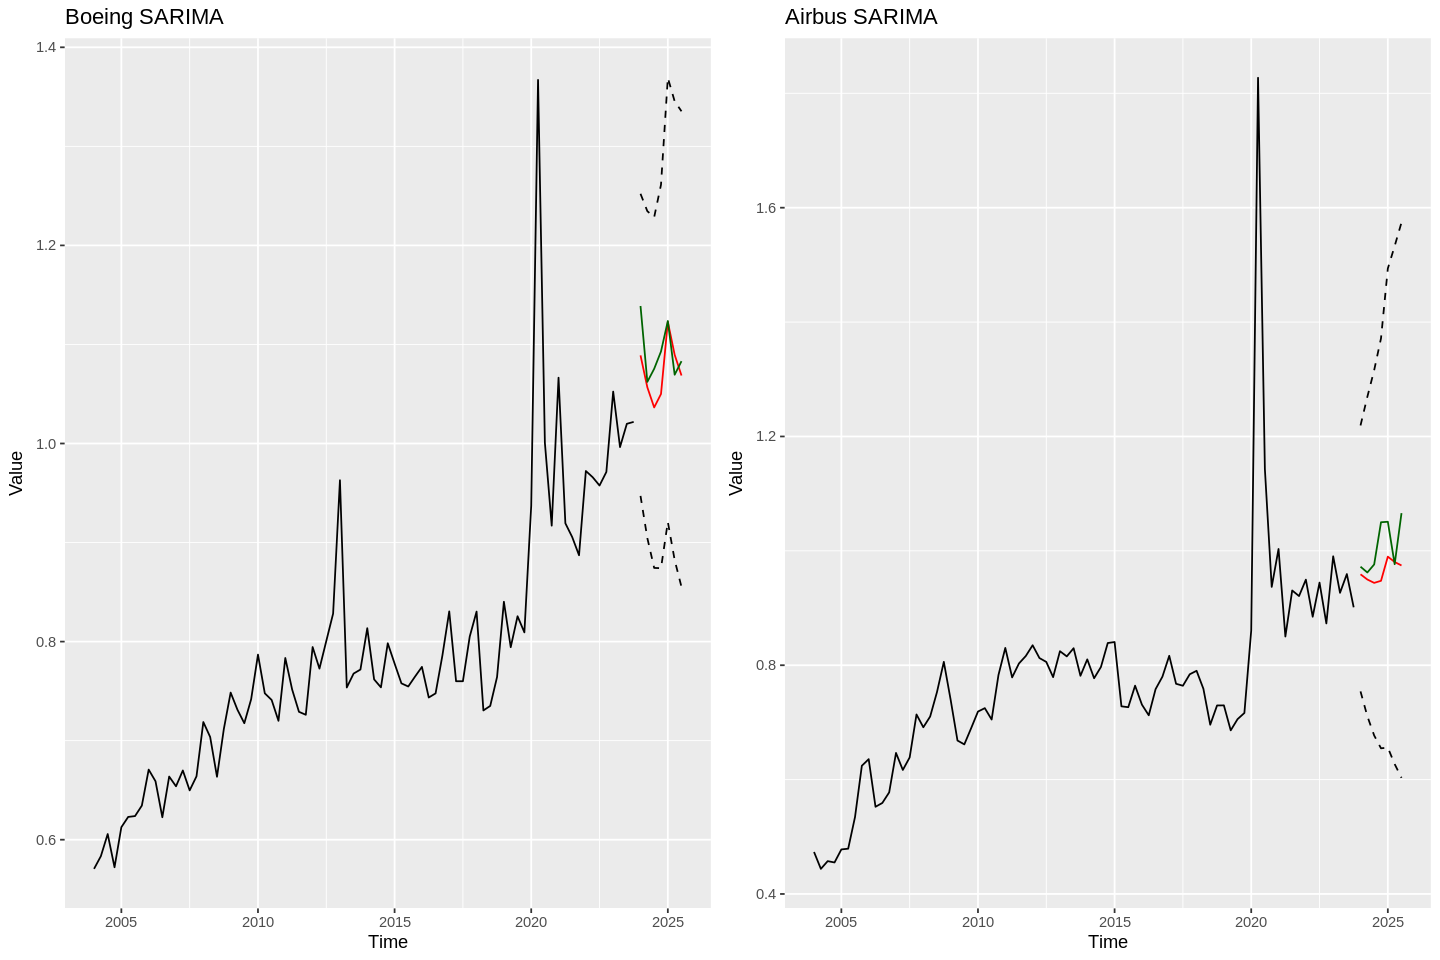

In [217]:
boeing_df <- data.frame(
  Time = as.numeric(time(y.t)),
  Value = as.numeric(y.t)
)

boeing_df_test <- data.frame(
  Time = as.numeric(time(x.t_test)),
  Value = as.numeric(x.t_test)
)

boeing_fc <- data.frame(
  Time = seq(tsp(y.t)[2] + 0.25, by = 0.25, length.out = length(x.t_test)),
  Forecast = fc_boeing_sarima,
  Lower = lower_95,
  Upper = upper_95
)

# Airbus df
airbus_df <- data.frame(
  Time = as.numeric(time(y.t_airbus)),
  Value = as.numeric(y.t_airbus)
)

airbus_df_test <- data.frame(
  Time = as.numeric(time(x.t_test_airbus)),
  Value = as.numeric(x.t_test_airbus)
)

airbus_fc <- data.frame(
  Time = seq(tsp(y.t_airbus)[2] + 0.25, by = 0.25, length.out = length(x.t_test_airbus)),
  Forecast = fc_airbus_sarima,
  Lower = lower_airbus,
  Upper = upper_airbus
)

# Boeing plot
p1 <- ggplot() +
  geom_line(data = boeing_df, aes(Time, Value), color = "black") +
  geom_line(data = boeing_fc, aes(Time, Forecast), color = "red") +
  geom_line(data = boeing_fc, aes(Time, Lower), linetype = "dashed") +
  geom_line(data = boeing_fc, aes(Time, Upper), linetype = "dashed") +
  geom_line(data = boeing_df_test, aes(Time, Value), color = "dark green") +
  labs(title = "Boeing SARIMA")

# Airbus plot
p2 <- ggplot() +
  geom_line(data = airbus_df, aes(Time, Value), color = "black") +
  geom_line(data = airbus_fc, aes(Time, Forecast), color = "red") +
  geom_line(data = airbus_fc, aes(Time, Lower), linetype = "dashed") +
  geom_line(data = airbus_fc, aes(Time, Upper), linetype = "dashed") +
  geom_line(data = airbus_df_test, aes(Time, Value), color = "dark green") +
  labs(title = "Airbus SARIMA")

# Combine plots using grid.arrange from gridExtra
grid.arrange(p1, p2, ncol = 2)

In [218]:
boeing_original <- data.frame(
  Time = as.numeric(time(y.t)),
  Value = as.numeric(y.t)
)

boeing_log <- data.frame(
  Time = as.numeric(time(ly.t)),
  Value = as.numeric(ly.t)
)

boeing_s4 <- data.frame(
  Time = as.numeric(time(ly.t_s4)),
  Value = as.numeric(ly.t_s4)
)

boeing_d1s4 <- data.frame(
  Time = as.numeric(time(ly.t_d1s4)),
  Value = as.numeric(ly.t_d1s4)
)

boeing_resid <- data.frame(
  Time = as.numeric(time(w.t)),
  Residual = as.numeric(w.t)
)

boeing_fc <- data.frame(
  Time = seq(fc_start, by = 0.25, length.out = length(x.t_test)),
  Forecast = fc_boeing_sarima,
  Lower = lower_95,
  Upper = upper_95
)

airbus_original <- data.frame(
  Time = as.numeric(time(y.t_airbus)),
  Value = as.numeric(y.t_airbus)
)

airbus_log <- data.frame(
  Time = as.numeric(time(ly.t_airbus)),
  Value = as.numeric(ly.t_airbus)
)

airbus_s4 <- data.frame(
  Time = as.numeric(time(ly.t_airbus_s4)),
  Value = as.numeric(ly.t_airbus_s4)
)

airbus_d1s4 <- data.frame(
  Time = as.numeric(time(ly.t_airbus_d1s4)),
  Value = as.numeric(ly.t_airbus_d1s4)
)

airbus_resid <- data.frame(
  Time = as.numeric(time(w.t_airbus)),
  Residual = as.numeric(w.t_airbus)
)

airbus_fc <- data.frame(
  Time = seq(tsp(y.t_airbus)[2] + 0.25, by = 0.25, length.out = length(x.t_test_airbus)),
  Forecast = fc_airbus_sarima,
  Lower = lower_airbus,
  Upper = upper_airbus
)

# Create QQ plots for residuals
p_boeing_qq <- ggplot(boeing_resid, aes(sample = Residual)) +
  geom_qq() +
  geom_qq_line(color = "red") +
  labs(title = "Boeing Residual QQ Plot", x = "Theoretical Quantiles", y = "Sample Quantiles")

p_airbus_qq <- ggplot(airbus_resid, aes(sample = Residual)) +
  geom_qq() +
  geom_qq_line(color = "red") +
  labs(title = "Airbus Residual QQ Plot", x = "Theoretical Quantiles", y = "Sample Quantiles")

In [219]:
p_boeing_original <- ggplot(boeing_original, aes(Time, Value)) +
  geom_line() +
  labs(title = "Boeing Original Series", x = "Year", y = "Maintenance Cost")

p_airbus_original <- ggplot(airbus_original, aes(Time, Value)) +
  geom_line() +
  labs(title = "Airbus Original Series", x = "Year", y = "Maintenance Cost")

p_boeing_log <- ggplot(boeing_log, aes(Time, Value)) +
  geom_line() +
  labs(title = "Boeing Log Series", x = "Year", y = "Log Value")

p_airbus_log <- ggplot(airbus_log, aes(Time, Value)) +
  geom_line() +
  labs(title = "Airbus Log Series", x = "Year", y = "Log Value")

p_boeing_s4 <- ggplot(boeing_s4, aes(Time, Value)) +
  geom_line() +
  labs(title = "Boeing Lag-4 Difference", x = "Year", y = "Difference")

p_airbus_s4 <- ggplot(airbus_s4, aes(Time, Value)) +
  geom_line() +
  coord_cartesian(ylim = c(-4, 3)) +
  labs(title = "Airbus Lag-4 Difference", x = "Year", y = "Difference")

p_boeing_d1s4 <- ggplot(boeing_d1s4, aes(Time, Value)) +
  geom_line() +
  labs(title = "Boeing Lag-1 + Lag-4 Difference", x = "Year", y = "Difference")

p_airbus_d1s4 <- ggplot(airbus_d1s4, aes(Time, Value)) +
  geom_line() +
  labs(title = "Airbus Lag-1 + Lag-4 Difference", x = "Year", y = "Difference")

p_boeing_resid <- ggplot(boeing_resid, aes(Time, Residual)) +
  geom_line() +
  geom_hline(yintercept = 0, lty = "dashed") +
  labs(title = "Boeing Residuals", x = "Year", y = "Residual")

p_airbus_resid <- ggplot(airbus_resid, aes(Time, Residual)) +
  geom_line() +
  geom_hline(yintercept = 0, lty = "dashed") +
  labs(title = "Airbus Residuals", x = "Year", y = "Residual")

p_boeing_hist <- ggplot(boeing_resid, aes(Residual)) +
  geom_histogram(aes(y = after_stat(density)),
                 bins = 15,
                 fill = "grey85",
                 color = "black") +
  geom_density(color = "red") +
  labs(title = "Boeing Residual Histogram", x = "Residual", y = "Density")

p_airbus_hist <- ggplot(airbus_resid, aes(Residual)) +
  geom_histogram(aes(y = after_stat(density)),
                 bins = 15,
                 fill = "grey85",
                 color = "black") +
  geom_density(color = "red") +
  labs(title = "Airbus Residual Histogram", x = "Residual", y = "Density")

p_boeing_forecast <- ggplot() +
  geom_line(data = boeing_original, aes(Time, Value), color = "black") +
  geom_line(data = boeing_fc, aes(Time, Forecast), color = "red") +
  geom_line(data = boeing_fc, aes(Time, Lower), color = "blue", lty = "dashed") +
  geom_line(data = boeing_df_test, aes(Time, Value), color = "dark green") +
  geom_line(data = boeing_fc, aes(Time, Upper), color = "blue", lty = "dashed") +
  labs(title = "Boeing Forecast", x = "Year", y = "Maintenance Cost")

p_airbus_forecast <- ggplot() +
  geom_line(data = airbus_original, aes(Time, Value), color = "black") +
  geom_line(data = airbus_fc, aes(Time, Forecast), color = "red") +
  geom_line(data = boeing_fc, aes(Time, Lower), color = "blue", lty = "dashed") +
  geom_line(data = airbus_fc, aes(Time, Upper), color = "blue", lty = "dashed") +
  geom_line(data = airbus_df_test, aes(Time, Value), color = "dark green") +
  labs(title = "Airbus Forecast", x = "Year", y = "Maintenance Cost")

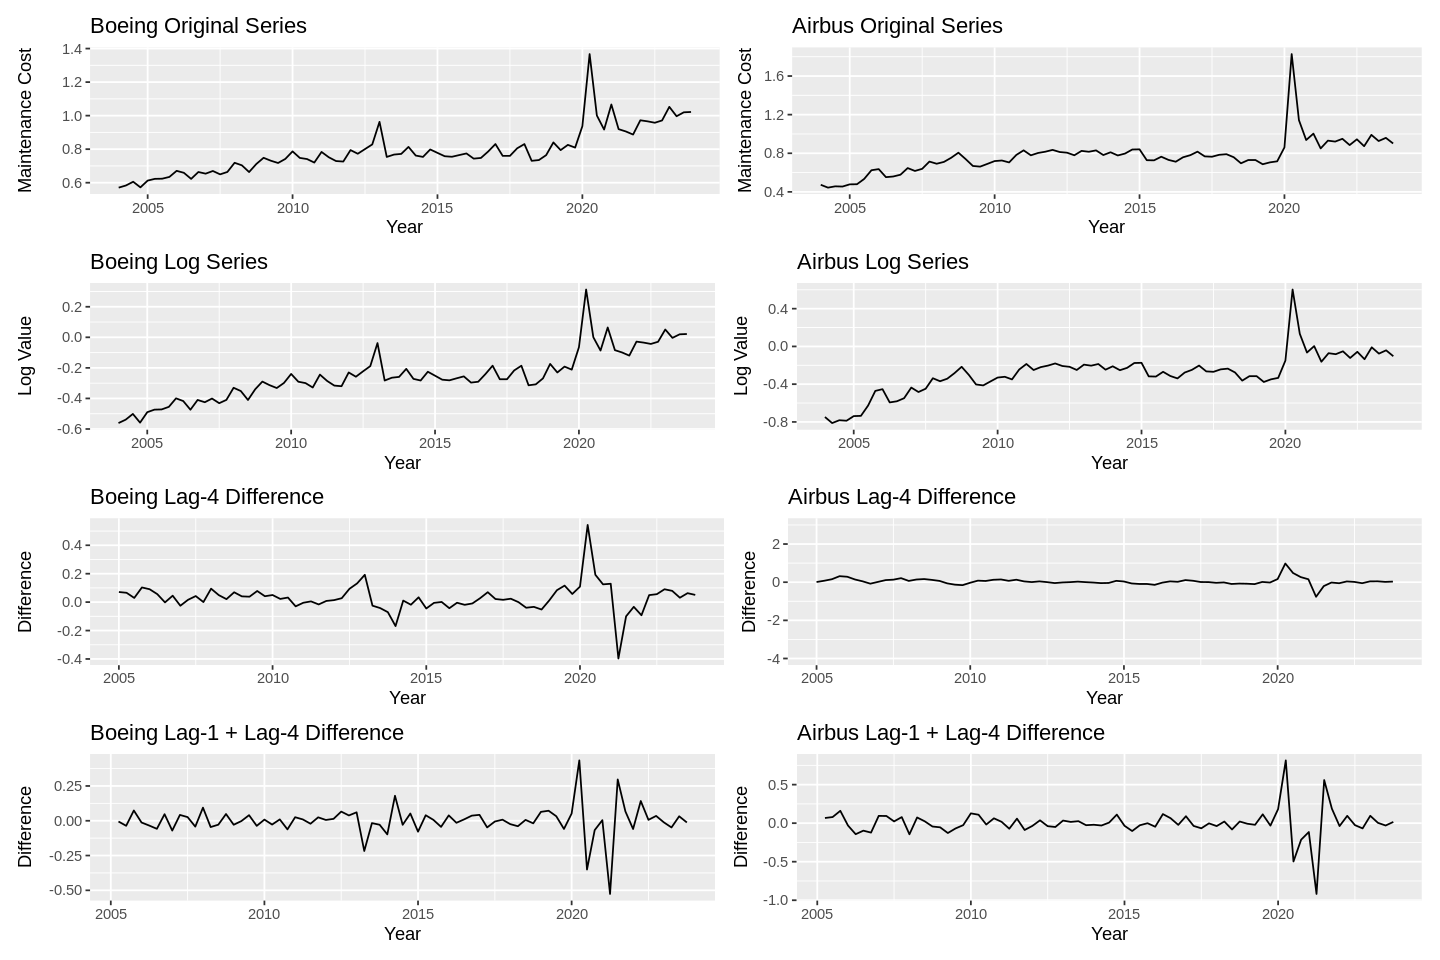

In [220]:
half_model_plots <-
  (p_boeing_original + p_airbus_original) /
  (p_boeing_log + p_airbus_log) /
  (p_boeing_s4 + p_airbus_s4) /
  (p_boeing_d1s4 + p_airbus_d1s4)

half_model_plots

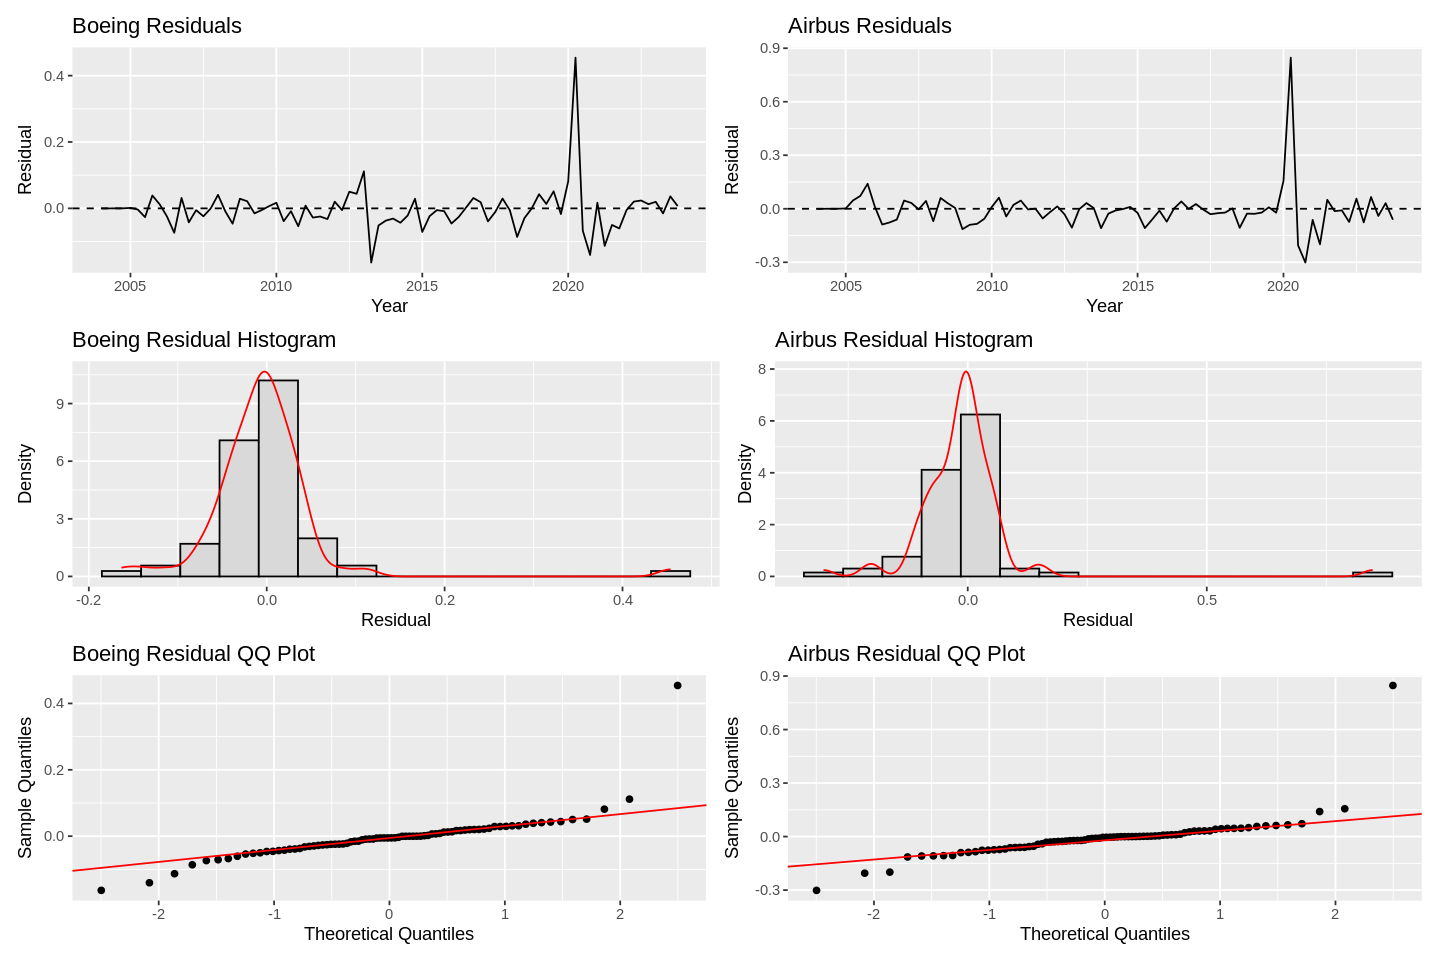

In [221]:
  (p_boeing_resid + p_airbus_resid) /
  (p_boeing_hist + p_airbus_hist)/
  (p_boeing_qq + p_airbus_qq)

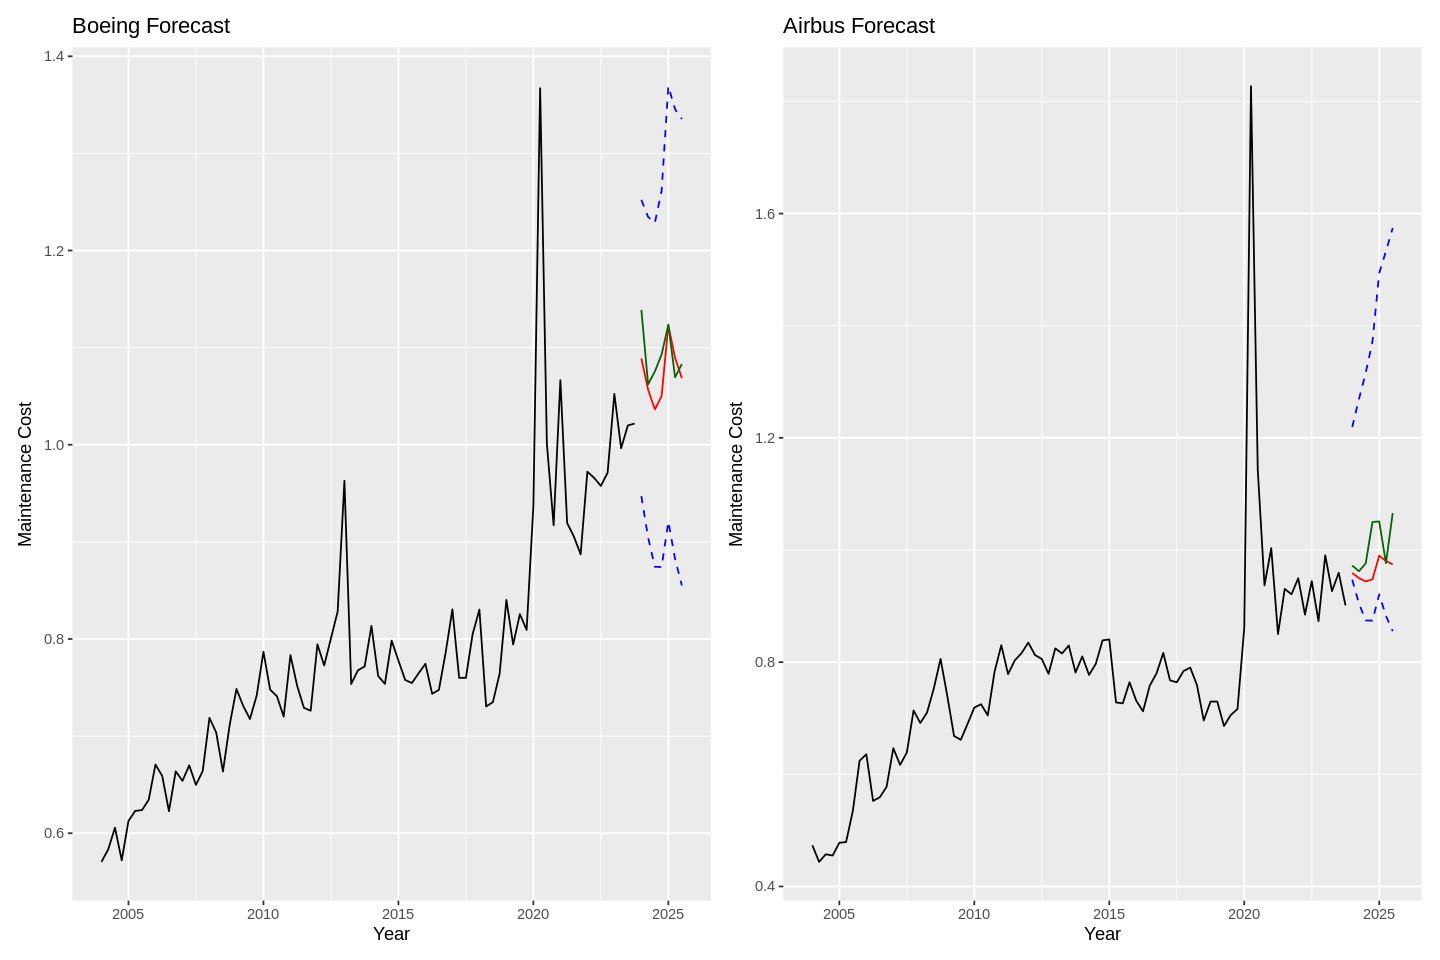

In [250]:
  (p_boeing_forecast + p_airbus_forecast)

In [223]:
# Boeing errors
error_boeing <- fc_boeing_sarima - as.numeric(x.t_test_airbus)
# Airbus errors
error_airbus <- fc_airbus_sarima - as.numeric(x.t_test_airbus)

In [224]:
# Boeing
rmse_boeing <- sqrt(mean(error_boeing^2, na.rm = TRUE))
mae_boeing  <- mean(abs(error_boeing), na.rm = TRUE)

# Airbus
rmse_airbus <- sqrt(mean(error_airbus^2, na.rm = TRUE))
mae_airbus  <- mean(abs(error_airbus), na.rm = TRUE)

# Create the data frame with full precision results
results_full <- data.frame(
  Model = c("Boeing", "Airbus"),
  RMSE = c(rmse_boeing, rmse_airbus),
  MAE  = c(mae_boeing, mae_airbus)
)

# Create a new data frame for printing with rounded numeric columns
results_display <- data.frame(
  Model = results_full$Model,
  RMSE = round(results_full$RMSE, 4),
  MAE = round(results_full$MAE, 4)
)

results_display

Model,RMSE,MAE
<chr>,<dbl>,<dbl>
Boeing,0.0794,0.0656
Airbus,0.0585,0.0452


In [225]:
cbind(
  Actual = as.numeric(x.t_test),
  Forecast = fc_boeing_sarima,
  Error = error_boeing
)

Actual,Forecast,Error
1.138831,1.088986,1.167159e-01
1.062239,1.056727,9.456359e-02
1.075435,1.036415,6.019418e-02
1.092933,1.050005,5.003276e-06
1.123679,1.122842,7.197770e-02
1.069458,1.089579,1.129295e-01
1.083128,1.068636,2.706041e-03


In [253]:
fit_airbus$coef

fit_bst$coef

ma1       sma1 
-0.3236737 -0.9335454

ma1       sma1 
-0.5079168 -0.9999972

# Changepoint Detection

In [226]:
#head(df_sarima)
sarima_cols <- select_if(df_sarima, is.numeric) %>%
  select(-YEAR, -TIME_POINT, -QUARTER) %>% colnames()

# split into airbus and boeing datasets
df_sarima_b <- df_sarima %>% filter(MANUFACTURER == "BOEING")
df_sarima_a <- df_sarima %>% filter(MANUFACTURER == "AIRBUS INDUSTRIE")
# max num changepoints to detect
q = 3
method = "PELT"
penalty = "BIC"
# get changepoints for all numeric columns
print("Airbus")
cpt.var(df_sarima_a$MAINT_PER_AIR_HR, method = method,
         Q = q, penalty = penalty)

print("Boeing")
cpt.var(df_sarima_b$MAINT_PER_AIR_HR, method = method,
         Q = q, penalty = penalty)

[1] "Airbus"


Class 'cpt' : Changepoint Object
       ~~   : S4 class containing 12 slots with names
              cpttype date version data.set method test.stat pen.type pen.value minseglen cpts ncpts.max param.est 

Created on  : Wed May  6 18:30:17 2026 

summary(.)  :
----------
Created Using changepoint version 2.3 
Changepoint type      : Change in variance 
Method of analysis    : PELT 
Test Statistic  : Normal 
Type of penalty       : BIC with value, 8.931816 
Minimum Segment Length : 2 
Maximum no. of cpts   : Inf 
Changepoint Locations : 15 65 67 

[1] "Boeing"


Class 'cpt' : Changepoint Object
       ~~   : S4 class containing 12 slots with names
              cpttype date version data.set method test.stat pen.type pen.value minseglen cpts ncpts.max param.est 

Created on  : Wed May  6 18:30:17 2026 

summary(.)  :
----------
Created Using changepoint version 2.3 
Changepoint type      : Change in variance 
Method of analysis    : PELT 
Test Statistic  : Normal 
Type of penalty       : BIC with value, 8.931816 
Minimum Segment Length : 2 
Maximum no. of cpts   : Inf 
Changepoint Locations : 20 64 

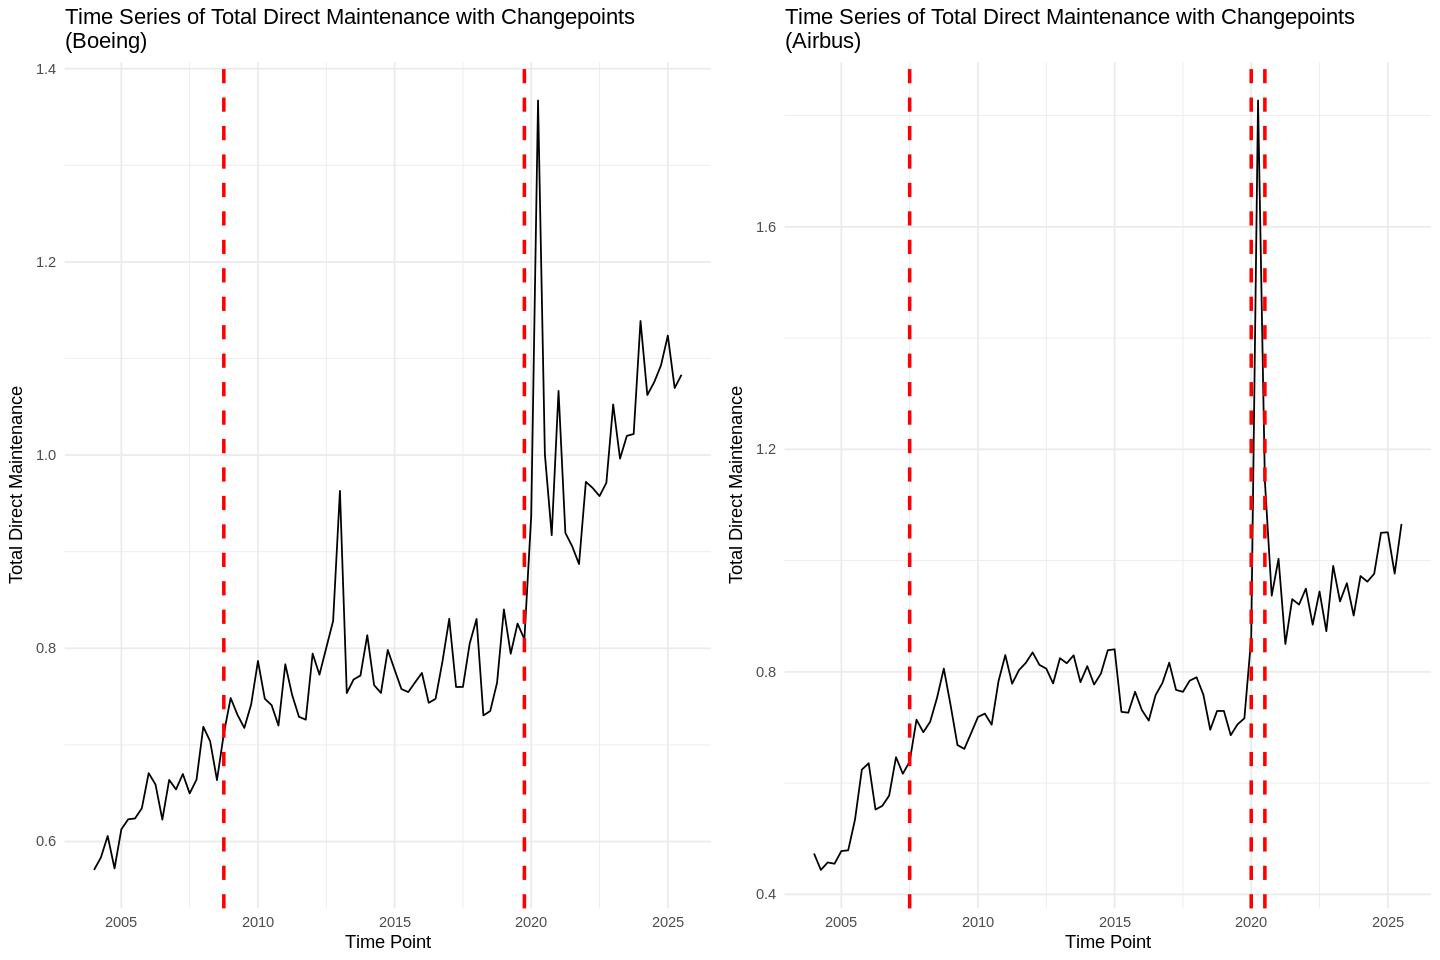

In [227]:
# Get the time points for the changepoint indices
changepoint_times_a <- df_sarima_a$TIME_POINT[c(15, 65, 67)]
changepoint_times_b <- df_sarima_b$TIME_POINT[c(20, 64)]

# Plot the TOT_DIR_MAINT time series with changepoints
airbus <- ggplot(df_sarima_a, aes(x = TIME_POINT, y = MAINT_PER_AIR_HR)) +
  geom_line() +
  geom_vline(xintercept = changepoint_times_a, color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Time Series of Total Direct Maintenance with Changepoints \n(Airbus)",
    x = "Time Point",
    y = "Total Direct Maintenance"
  ) +
  theme_minimal()

boeing <- ggplot(df_sarima_b, aes(x = TIME_POINT, y = MAINT_PER_AIR_HR)) +
  geom_line() +
  geom_vline(xintercept = changepoint_times_b, color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Time Series of Total Direct Maintenance with Changepoints \n(Boeing)",
    x = "Time Point",
    y = "Total Direct Maintenance"
  ) +
  theme_minimal()

# Display both plots
grid.arrange(boeing, airbus, ncol = 2)

`cpt.mean` did not find the correct changepoints, which makes sense given the data has a trend and does not have locations of stationary mean to compare to.For this reason, `cpt.var` is used. `cpt.meanvar`is not used because it detects too many changepoints, even with a BIC penalty.

# Anomaly Detection
Changepoints are not clearly present in this data, especially considering the interval between some (Airbus indicies 65 and 67) contain a single data point. For this reason, anomoly detection is employed to identify where these points in the data occur. To remove the trend and better see what might be anomolies, the lag 1 difference is taken. The mean is constant apart from a spike and correction during the 2008 financial crisis and later during COVID. This makes sense considering nearly all craft in this analysis are passenger craft; when finances are stable people are able to take more flights and maintainance of craft as they rotate into and out of use is a constant part of the aviation market.

### Airbus lag-1 difference
* all maintainance cost predictors as well as response variable MAINT_PER_AIR_HR (maintainance cost per air hour flown)

In [228]:
# Initialize ts objects
y_b <- y.t
y_b_train <- x.t_train
y_b_test <- x.t_test

y_a <- y.t_airbus
y_a_train <- x.t_train_airbus
y_a_test <- x.t_test_airbus

# baseline SARIMAs
fit_sarima_b <- fit_bst
fit_sarima_a <- fit_airbus

# Logged series
ly_b_train <- log(y_b_train)
ly_a_train <- log(y_a_train)

# Full train dataframes
df_sarima_b <- df_sarima %>%
  filter(MANUFACTURER == "BOEING") %>%
  slice(1:length(y_b_train))

df_sarima_a <- df_sarima %>%
  filter(MANUFACTURER == "AIRBUS INDUSTRIE") %>%
  slice(1:length(y_a_train))

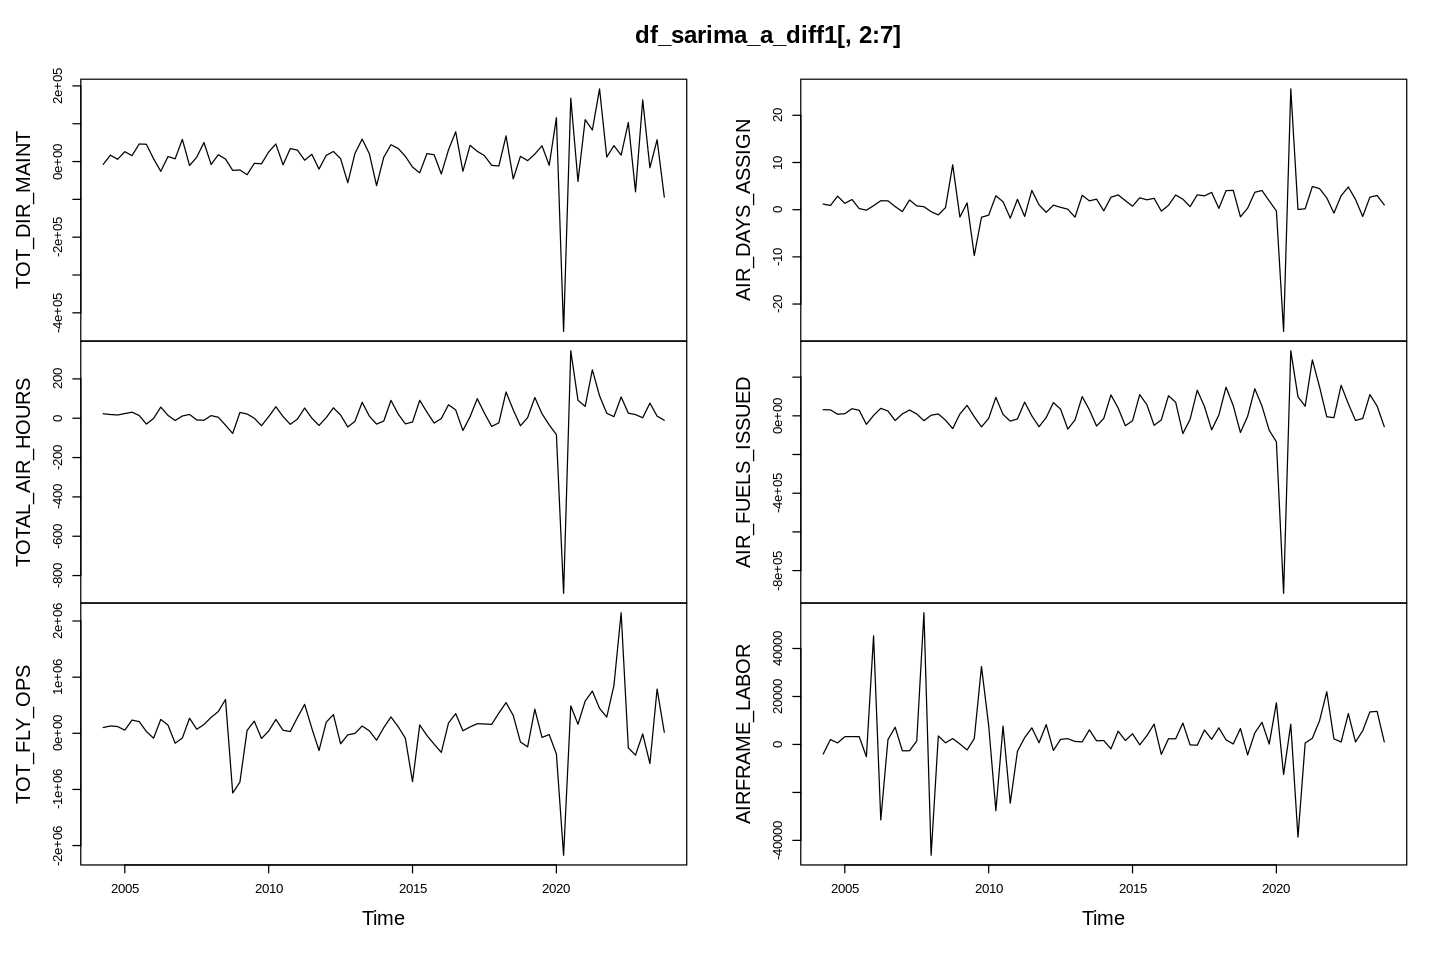

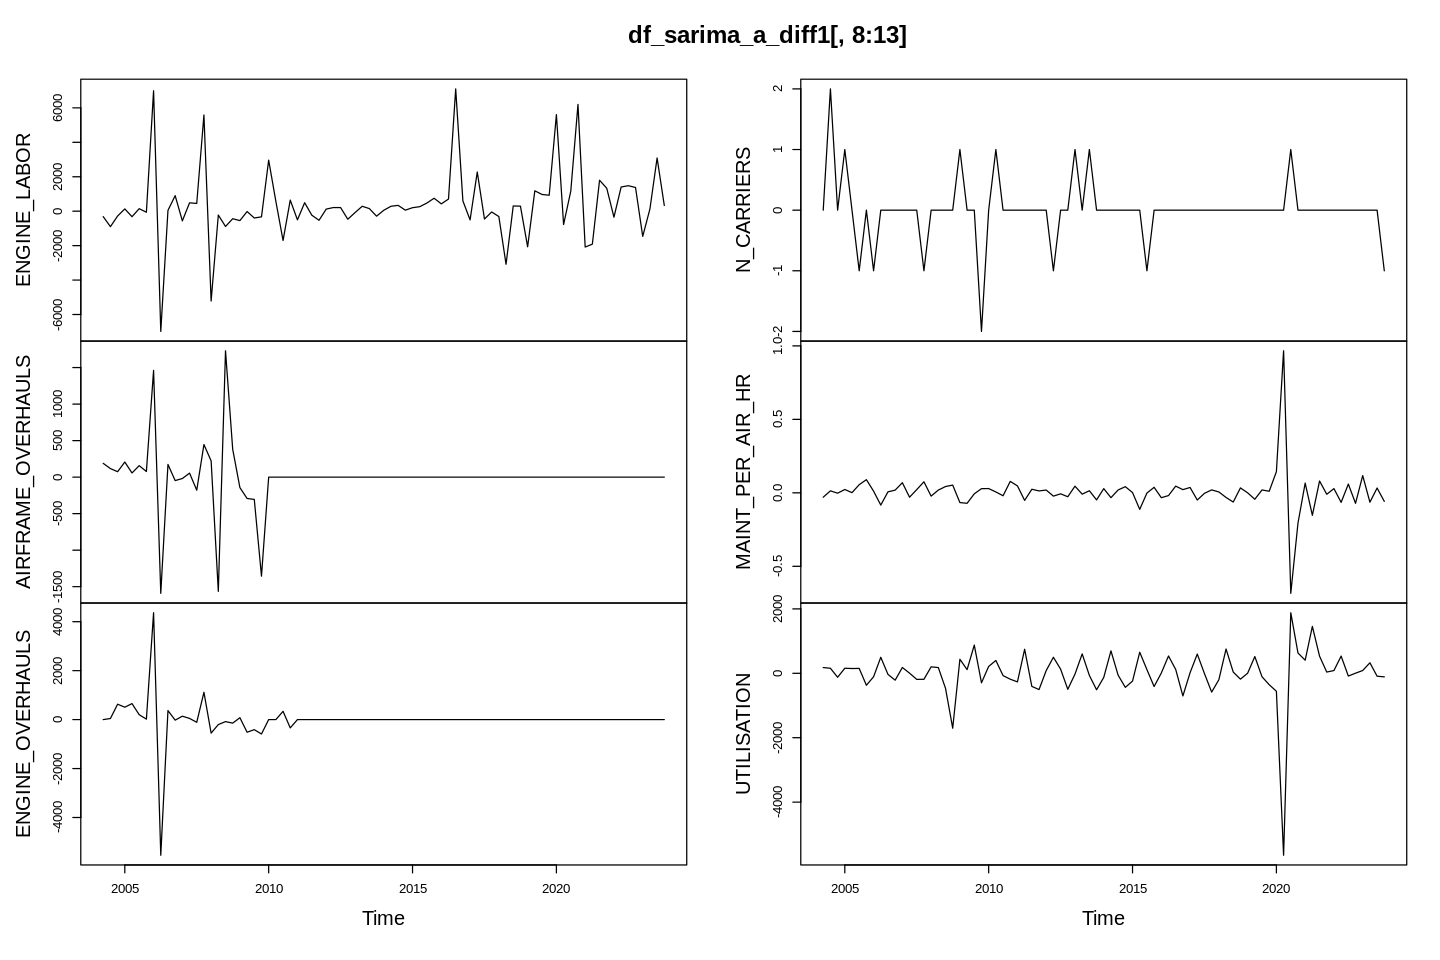

In [229]:
df_sarima_a_ts <- df_sarima_a %>% select(-MANUFACTURER, -YEAR, -QUARTER)
df_sarima_a_ts <- ts(df_sarima_a_ts, start = 2004, freq = 4)

df_sarima_a_diff1 <- diff(df_sarima_a_ts, lag=1)

plot.ts(df_sarima_a_diff1[,2:7])
plot.ts(df_sarima_a_diff1[,8:13])

### Boeing lag-1 difference
* all maintainance cost predictors as well as response variable MAINT_PER_AIR_HR (maintainance cost per air hour flown)

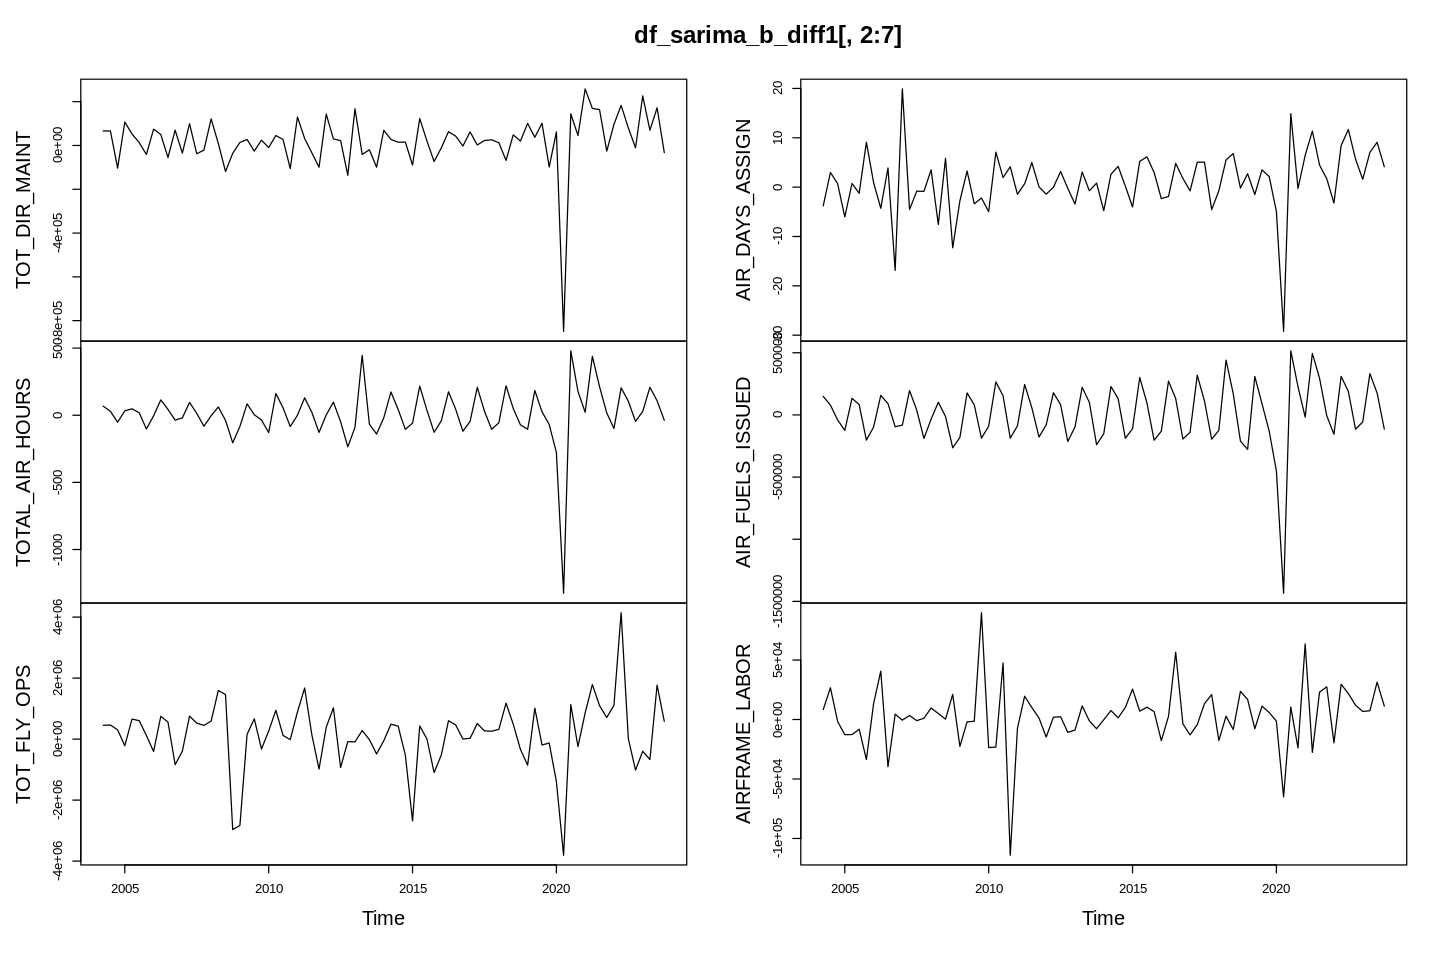

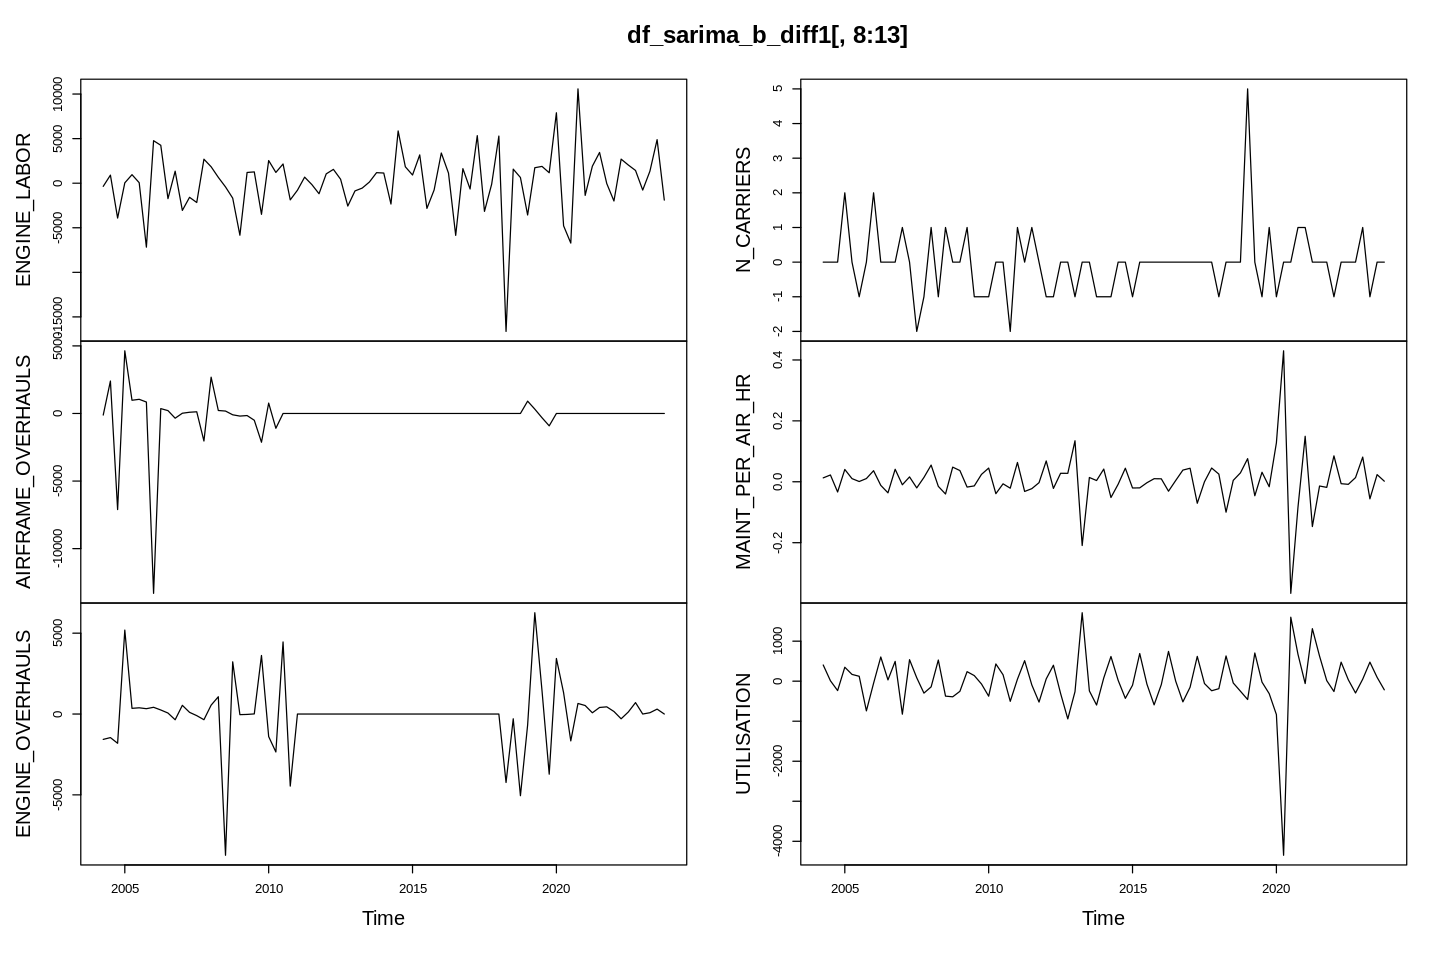

In [230]:
df_sarima_b_ts <- df_sarima_b %>% select(-MANUFACTURER, -YEAR, -QUARTER)
df_sarima_b_ts <- ts(df_sarima_b_ts, start = 2004, freq = 4)

df_sarima_b_diff1 <- diff(df_sarima_b_ts, lag=1)

plot.ts(df_sarima_b_diff1[,2:7])
plot.ts(df_sarima_b_diff1[,8:13])

### Anomoly detection using z-score and Modified Z-score with MAD (Mean Absolute Deviation).
* Anomolies are identified as points with residuals beyond 2.5 standard deviations using the Z-score method and beyond 3 using MAD Modified Z-score


**Detect anomilies and gather their locations**

Note: The residuals are not normally distributed, so the 2.5 s.d. threshold may not accurately detect all of them

In [231]:
zscore_anom <- function(residuals, threshold = 2.5) {
  sigma_hat  <- sd(residuals)
  z_scores   <- residuals / sigma_hat
  time_axis  <- as.numeric(time(residuals))

  flag_idx   <- which(abs(z_scores) > threshold)
  flag_times <- time_axis[flag_idx]
  flag_z     <- as.numeric(z_scores)[flag_idx]

  data.frame(
    idx       = flag_idx,
    Quarter   = format(as.yearqtr(flag_times)),
    z_score   = round(flag_z, 3),
    direction = ifelse(flag_z > 0, "ABOVE trend", "BELOW trend")
  )
}

baseline_sarima_boeing  <- fit_bst
baseline_residuals_boeing <- fit_bst$residuals

baseline_sarima_airbus  <- fit_airbus
baseline_residuals_airbus <- fit_airbus$residuals

flag_df_b <- zscore_anom(baseline_residuals_boeing)
flag_df_a <- zscore_anom(baseline_residuals_airbus)

print("Flagged quarters (|z| > 2.5 SD) from baseline Boeing SARIMA residuals")
print(flag_df_b[order(abs(flag_df_b$z_score), decreasing = TRUE), ])

print("Flagged quarters (|z| > 2.5 SD) from baseline Airbus SARIMA residuals")
print(flag_df_a[order(abs(flag_df_a$z_score), decreasing = TRUE), ])

[1] "Flagged quarters (|z| > 2.5 SD) from baseline Boeing SARIMA residuals"
  idx Quarter z_score   direction
1  66 2020 Q2   6.724 ABOVE trend
[1] "Flagged quarters (|z| > 2.5 SD) from baseline Airbus SARIMA residuals"
  idx Quarter z_score   direction
1  66 2020 Q2   7.150 ABOVE trend
2  68 2020 Q4  -2.545 BELOW trend


**Plot anomalous residuals for both Boeing and Airbus**

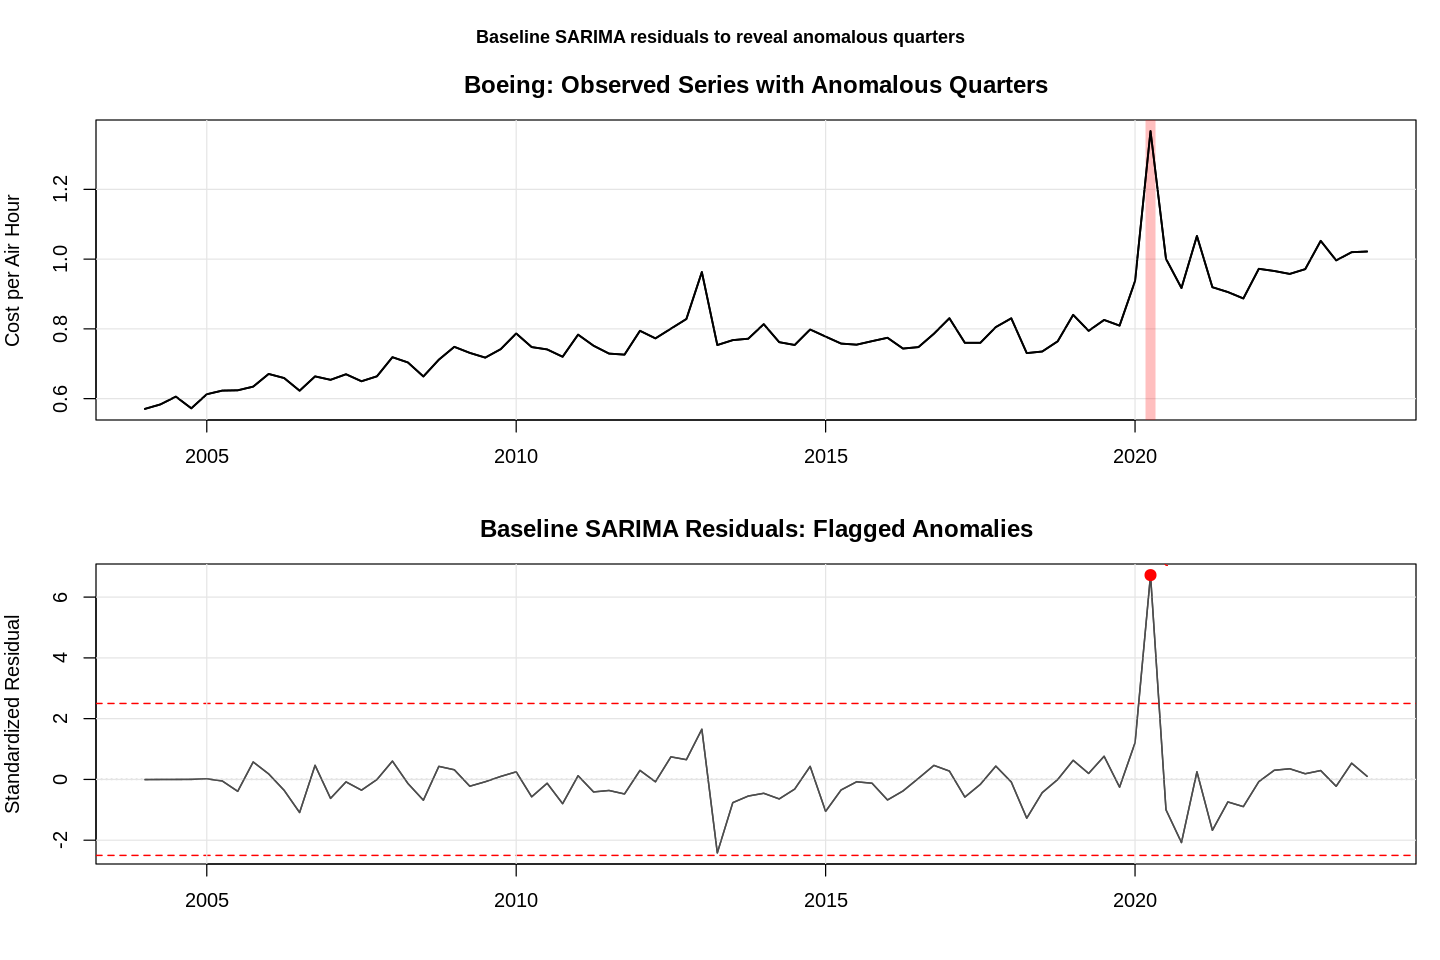

In [232]:
par(mfrow = c(2, 1), mar = c(3, 4, 3, 1), oma = c(1, 0, 2, 0))

# Recalculate necessary variables for Boeing residuals plot
sigma_hat_boeing <- sd(baseline_residuals_boeing)
z_scores_boeing <- baseline_residuals_boeing / sigma_hat_boeing
time_axis_boeing <- as.numeric(time(baseline_residuals_boeing))

# Extract flagged points from already computed flag_df_b
flag_times_boeing <- as.numeric(as.yearqtr(flag_df_b$Quarter))
flag_z_boeing <- flag_df_b$z_score

# Panel 1: Original series
y_orig <- y.t
plot(y_orig, type = "l", lwd = 1.5, col = "black",
     xlab = "", ylab = "Cost per Air Hour",
     main = "Boeing: Observed Series with Anomalous Quarters")
grid(col = "grey90", lty = 1)
for (ft in flag_times_boeing) {
  abline(v = ft, col = adjustcolor("red", alpha = 0.25), lwd = 8)
}
lines(y_orig, lwd = 1.5, col = "black")   # redraw on top

# Panel 2: Standardized residuals
plot(time_axis_boeing, as.numeric(z_scores_boeing), type = "l", lwd = 1.2, col = "grey30",
     xlab = "Year", ylab = "Standardized Residual",
     main = "Baseline SARIMA Residuals: Flagged Anomalies")
abline(h = c(-2.5, 2.5), lty = "dashed", col = "red", lwd = 1.2)
abline(h = 0, lty = "dotted", col = "grey50")
grid(col = "grey90", lty = 1)
lines(time_axis_boeing, as.numeric(z_scores_boeing), lwd = 1.2, col = "grey30")  # redraw
points(flag_times_boeing, flag_z_boeing, pch = 19, col = "red", cex = 1.2)
text(flag_times_boeing, flag_z_boeing,
     labels = format(as.yearqtr(flag_times_boeing)),
     pos = ifelse(flag_z_boeing > 0, 3, 1), cex = 0.7, col = "red")

mtext("Baseline SARIMA residuals to reveal anomalous quarters",
      outer = TRUE, cex = 0.9, font = 2)
par(mfrow = c(1, 1), oma = c(0,0,0,0), mar = c(5,4,4,2))

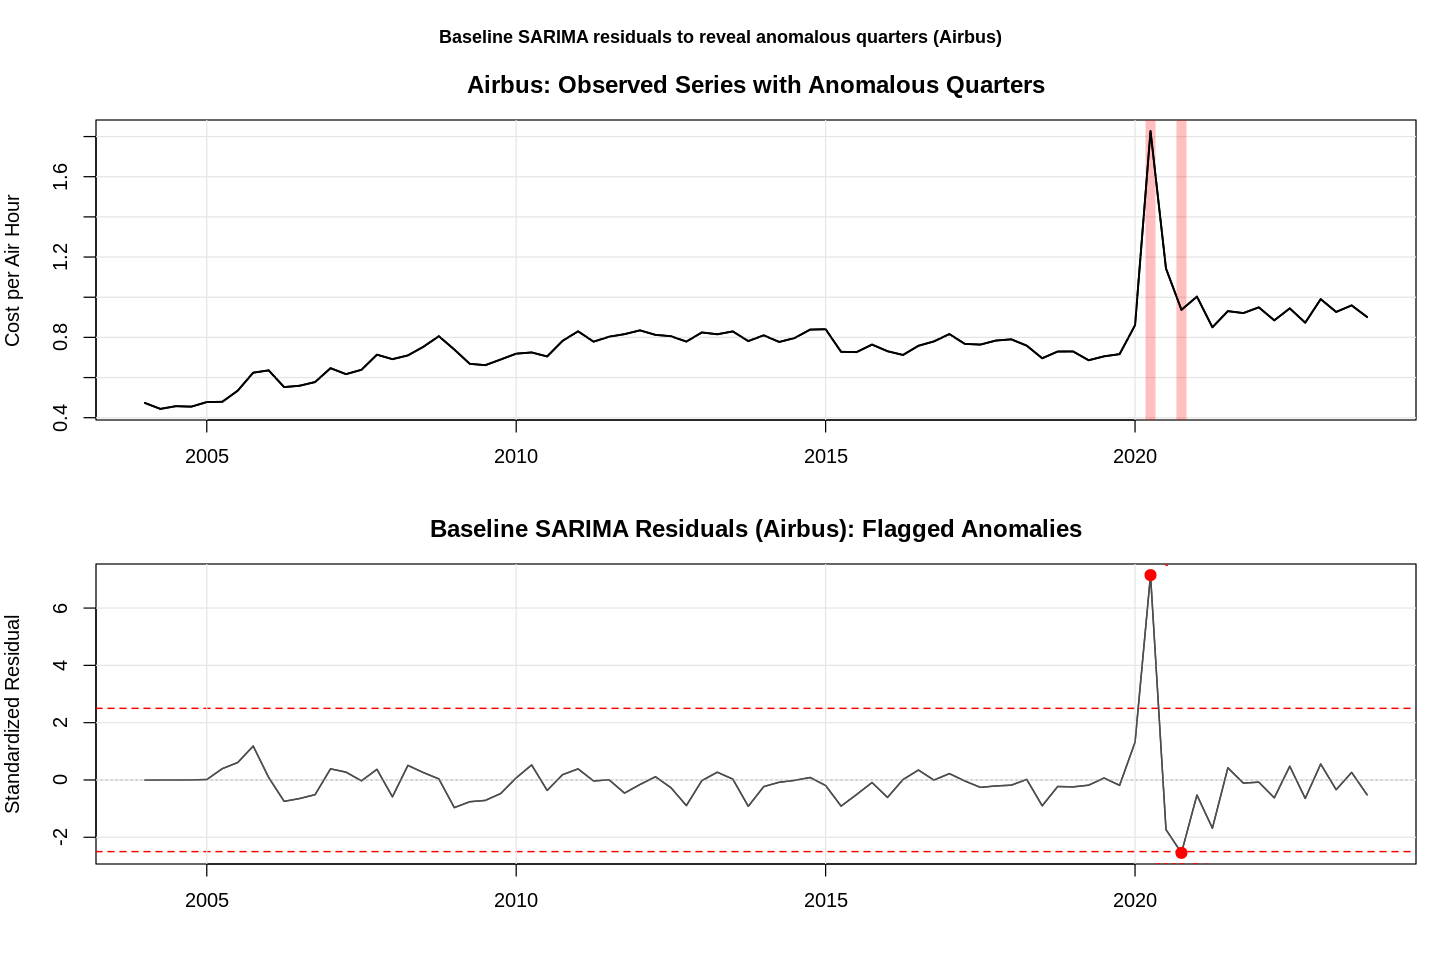

In [233]:
par(mfrow = c(2, 1), mar = c(3, 4, 3, 1), oma = c(1, 0, 2, 0))

# Recalculate necessary variables for Airbus residuals plot
residuals_airbus <- baseline_residuals_airbus
sigma_hat_airbus <- sd(residuals_airbus)
z_scores_airbus <- residuals_airbus / sigma_hat_airbus
time_axis_airbus <- as.numeric(time(residuals_airbus))

# Extract flagged points from already computed flag_df_a
flag_times_airbus <- as.numeric(as.yearqtr(flag_df_a$Quarter))
flag_z_airbus <- flag_df_a$z_score


# Panel 1: Original series for Airbus
y_orig_airbus <- y.t_airbus
plot(y_orig_airbus, type = "l", lwd = 1.5, col = "black",
     xlab = "", ylab = "Cost per Air Hour",
     main = "Airbus: Observed Series with Anomalous Quarters")
grid(col = "grey90", lty = 1)
for (ft in flag_times_airbus) {
  abline(v = ft, col = adjustcolor("red", alpha = 0.25), lwd = 8)
}
lines(y_orig_airbus, lwd = 1.5, col = "black")   # redraw on top

# Panel 2: Standardized residuals for Airbus
plot(time_axis_airbus, as.numeric(z_scores_airbus), type = "l", lwd = 1.2, col = "grey30",
     xlab = "Year", ylab = "Standardized Residual",
     main = "Baseline SARIMA Residuals (Airbus): Flagged Anomalies")
abline(h = c(-2.5, 2.5), lty = "dashed", col = "red", lwd = 1.2)
abline(h = 0, lty = "dotted", col = "grey50")
grid(col = "grey90", lty = 1)
lines(time_axis_airbus, as.numeric(z_scores_airbus), lwd = 1.2, col = "grey30")  # redraw
points(flag_times_airbus, flag_z_airbus, pch = 19, col = "red", cex = 1.2)
text(flag_times_airbus, flag_z_airbus,
     labels = format(as.yearqtr(flag_times_airbus)),
     pos = ifelse(flag_z_airbus > 0, 3, 1), cex = 0.7, col = "red")

mtext("Baseline SARIMA residuals to reveal anomalous quarters (Airbus)",
      outer = TRUE, cex = 0.9, font = 2)
par(mfrow = c(1, 1), oma = c(0,0,0,0), mar = c(5,4,4,2))

In [234]:
flag_times_airbus
flag_times_boeing

[1] 2020.25 2020.75

[1] 2020.25

The identification of only the anomoly in 2012 may indicate the SARIMA model addressed the impact of COVID on Airbus' maintainace cost per hour well.

# ARIMAX with Anomolies

A baseline model found using the SARIMA analysis is used to compare how much improvement can be made with incorporating additional predictors through ARIMAX and by incorporating the presence of anomolies. These anomolies are likely what draw the residuals away from normal, as seen in the shapiro-wilk test and histogram above.

In [235]:
make_xreg_base <- function(df, cols, lags = setNames(rep(0L, length(cols)), cols)) {
  out <- matrix(NA_real_, nrow = nrow(df), ncol = length(cols),
                dimnames = list(NULL, cols))
  for (col in cols) {
    k <- lags[[col]]
    x <- as.numeric(df[[col]])
    if (k == 0L) out[, col] <- x
    else         out[, col] <- c(rep(NA_real_, k), x[seq_len(length(x) - k)])
  }
  out
}

# after = 1: also flag the quarter immediately following each anomaly to
# absorb the spike-and-correction pair typical of large macro shocks.
build_anom_dummy <- function(flag_df, n, after = 1L) {
  dummy <- integer(n)
  for (i in flag_df$idx + 1L) {
    dummy[i : min(n, i + after)] <- 1L
  }
  dummy
}

# Find which quarters are flagged for COVID specifically
# these could be one and the same, but just in case data lengths differ, create one for each series
tp_b <- df_sarima_b$TIME_POINT
covid_shock_b    <- as.integer(tp_b >= 2020.00 & tp_b <= 2020.25)
covid_recovery_b <- as.integer(tp_b >= 2020.50 & tp_b <= 2020.75)

tp_a <- df_sarima_a$TIME_POINT
covid_shock_a    <- as.integer(tp_a >= 2020.00 & tp_a <= 2020.25)
covid_recovery_a <- as.integer(tp_a >= 2020.50 & tp_a <= 2020.75)


# log predictors to put on same scale as series
df_sarima_b <- df_sarima_b %>%
  mutate(log_ops  = log(TOT_FLY_OPS),
         log_util = log(UTILISATION),
         log_ncar = log(N_CARRIERS))

df_sarima_a <- df_sarima_a %>%
  mutate(log_ops  = log(TOT_FLY_OPS),
         log_util = log(UTILISATION),
         log_ncar = log(N_CARRIERS))

pred_cols <- c("log_ops", "log_util", "log_ncar")
lag_spec  <- c(log_ops = 1L, log_util = 1L, log_ncar = 1L)

xreg_b_train <- cbind(make_xreg_base(df_sarima_b, pred_cols, lag_spec),
                shock = covid_shock_b,
                recovery = covid_recovery_b)

xreg_a_train <- cbind(make_xreg_base(df_sarima_a, pred_cols, lag_spec),
                shock = covid_shock_a,
                recovery = covid_recovery_a)

# Drop row 1 (full of NAs) from response and xreg together
y_b_fit  <- ly_b_train[-1]
y_a_fit  <- ly_a_train[-1]
xreg_b_fit <- xreg_b_train[-1, ]
xreg_a_fit <- xreg_a_train[-1, ]

# Fit ARIMAX models
fit_arimax_b <- arima(y_b_fit, order = c(0, 1, 1),
                      seasonal = list(order = c(0, 1, 1), period = 4),
                      xreg = xreg_b_fit, include.mean = FALSE)

fit_arimax_a <- arima(y_a_fit, order = c(0, 1, 1),
                      seasonal = list(order = c(0, 1, 1), period = 4),
                      xreg = xreg_a_fit, include.mean = FALSE)

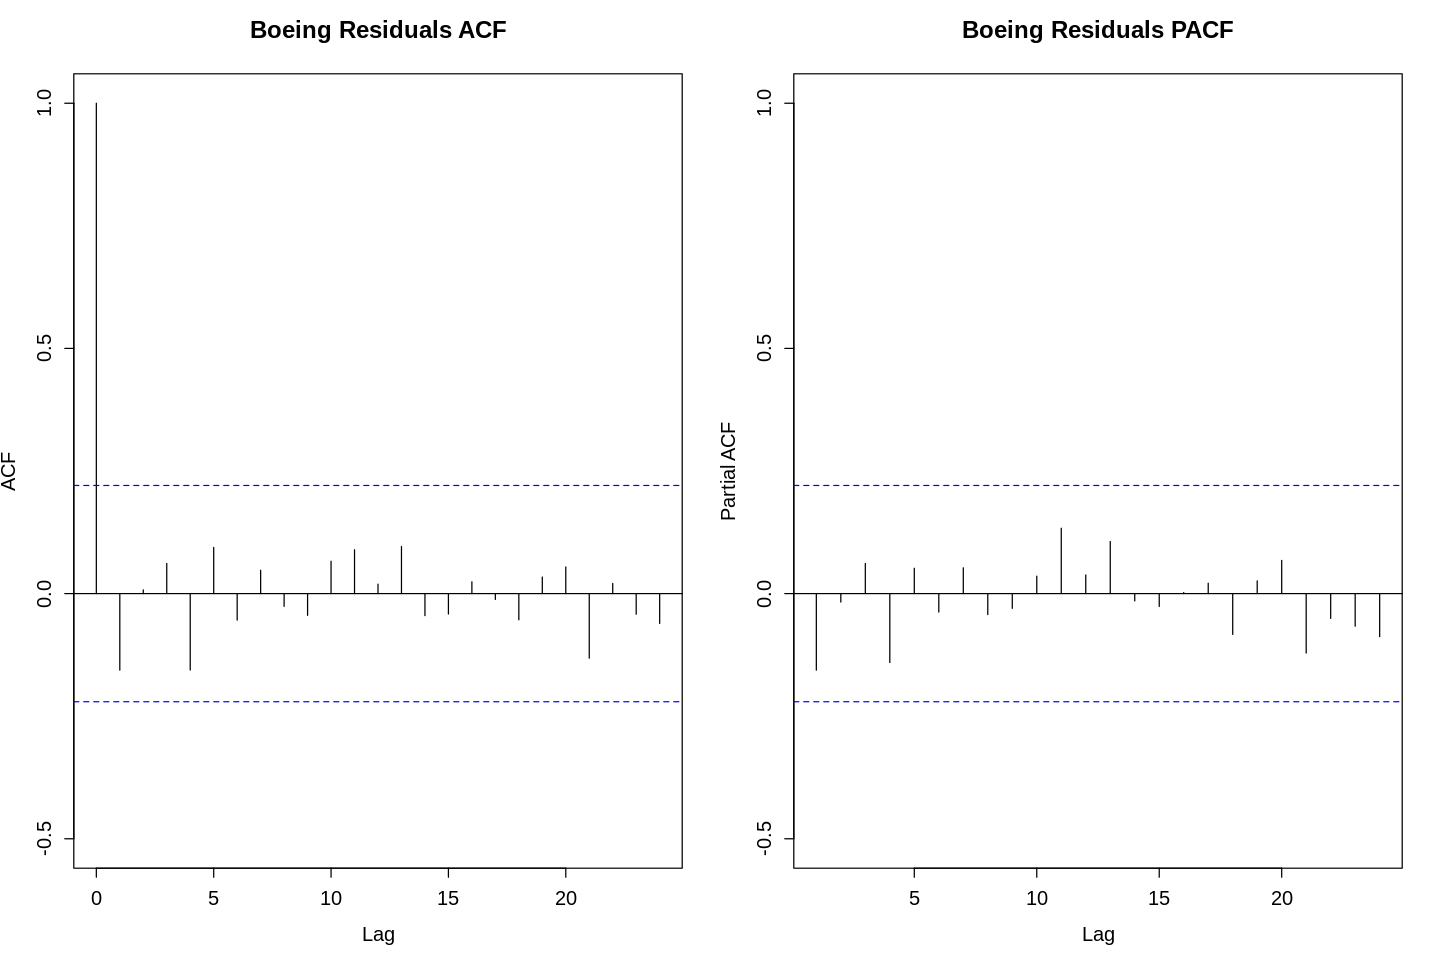

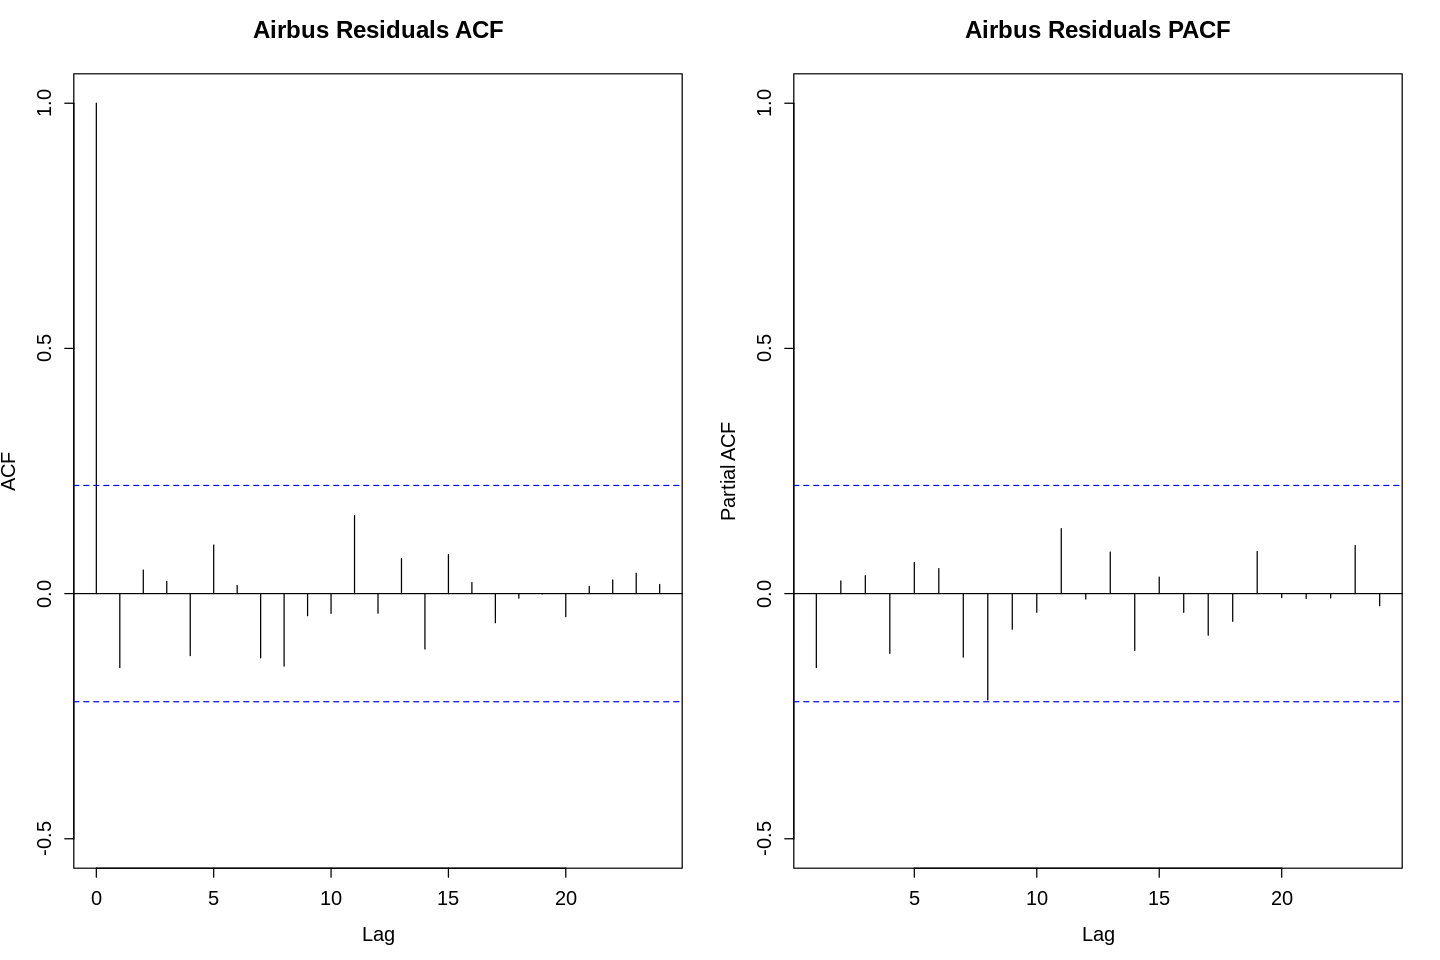

In [236]:
# Set plot options for larger size
options(repr.plot.width = 12, repr.plot.height = 8)

# Lag plots of ARIMAX residuals
par(mfrow = c(1,2), mex = 0.75)
acf(residuals(fit_arimax_b), ylim = c(-0.5, 1), lag.max = 24,
    main = "Boeing Residuals ACF")
pacf(residuals(fit_arimax_b), ylim = c(-0.5, 1), lag.max = 24,
     main = "Boeing Residuals PACF")
par(mfrow = c(1,1))

par(mfrow = c(1,2), mex = 0.75)
acf(residuals(fit_arimax_a), ylim = c(-0.5, 1), lag.max = 24,
    main = "Airbus Residuals ACF")
pacf(residuals(fit_arimax_a), ylim = c(-0.5, 1), lag.max = 24,
     main = "Airbus Residuals PACF")
par(mfrow = c(1,1))

Residuals resemble white noise for both models! Still would like to try another option for each

In [237]:
# Fit alternative models
fit_arimax_b_0 <- arima(y_b_fit, order = c(1, 1, 1),
                         seasonal = list(order = c(0, 1, 1), period = 4),
                         xreg = xreg_b_fit, include.mean = FALSE)

fit_arimax_a_0 <- arima(y_a_fit, order = c(0, 1, 1),
                         seasonal = list(order = c(0, 1, 0), period = 4),
                         xreg = xreg_a_fit, include.mean = FALSE)


# Make sure SARIMA models have the same number of points
fit_sarima_b_trimmed <- arima(y_b_fit, order = c(0,1,1),
                               seasonal = list(order = c(0,1,1), period = 4),
                               include.mean = FALSE)
fit_sarima_a_trimmed <- arima(y_a_fit, order = c(0,1,1),
                               seasonal = list(order = c(0,1,1), period = 4),
                               include.mean = FALSE)

In [238]:
# AICC and BIC for ARIMAX Models
IC_table <- data.frame(
  Model = c("Boeing SARIMA(0,1,1)(0,1,1)[4]", # to compare with SARIMA
            "Boeing ARIMAX(0,1,1)(0,1,1)[4]",
            "Boeing ARIMAX(1,1,1)(0,1,1)[4]",
            "Airbus SARIMA(0,1,1)(0,1,1)[4]", # to compare with SARIMA
            "Airbus ARIMAX(0,1,1)(0,1,1)[4]",
            "Airbus ARIMAX(0,1,1)(0,1,0)[4]"),

  AIC = c(AIC(fit_sarima_b_trimmed),
          AIC(fit_arimax_b),
          AIC(fit_arimax_b_0),
          AIC(fit_sarima_a_trimmed),
          AIC(fit_arimax_a),
          AIC(fit_arimax_a_0)),

  BIC = c(BIC(fit_sarima_b_trimmed),
          BIC(fit_arimax_b),
          BIC(fit_arimax_b_0),
          BIC(fit_sarima_a_trimmed),
          BIC(fit_arimax_a),
          BIC(fit_arimax_a_0)),

  AICC = arma.AICC(fit_sarima_b_trimmed,
                   fit_arimax_b,
                   fit_arimax_b_0,
                   fit_sarima_a_trimmed,
                   fit_arimax_a,
                   fit_arimax_a_0)
)

IC_table <- IC_table[order(IC_table$AICC), ]
IC_table

,Model,AIC,BIC,AICC
,<chr>,<dbl>,<dbl>,<dbl>
fit_arimax_b_0,"Boeing ARIMAX(1,1,1)(0,1,1)[4]",-196.77985,-176.04326,-193.96735
fit_arimax_b,"Boeing ARIMAX(0,1,1)(0,1,1)[4]",-195.99918,-177.56666,-193.78380
fit_sarima_b_trimmed,"Boeing SARIMA(0,1,1)(0,1,1)[4]",-166.45046,-159.53827,-166.10761
fit_arimax_a,"Airbus ARIMAX(0,1,1)(0,1,1)[4]",-111.17573,-92.74321,-108.96034
fit_sarima_a_trimmed,"Airbus SARIMA(0,1,1)(0,1,1)[4]",-86.50305,-79.59086,-86.16020
fit_arimax_a_0,"Airbus ARIMAX(0,1,1)(0,1,0)[4]",-76.14008,-60.01163,-74.44311


Based on AICC and BIC, only the Airbus ARIMAX model (with seasonality) outperform the single-predictor SARIMA models. AICC and BIC likely penalize these models more due to having more predictors and therefore more parameters.

In [239]:
boeing_best_fit <- fit_arimax_b_0
airbus_best_fit <- fit_arimax_a

**Assessment of Normality of Residuals**

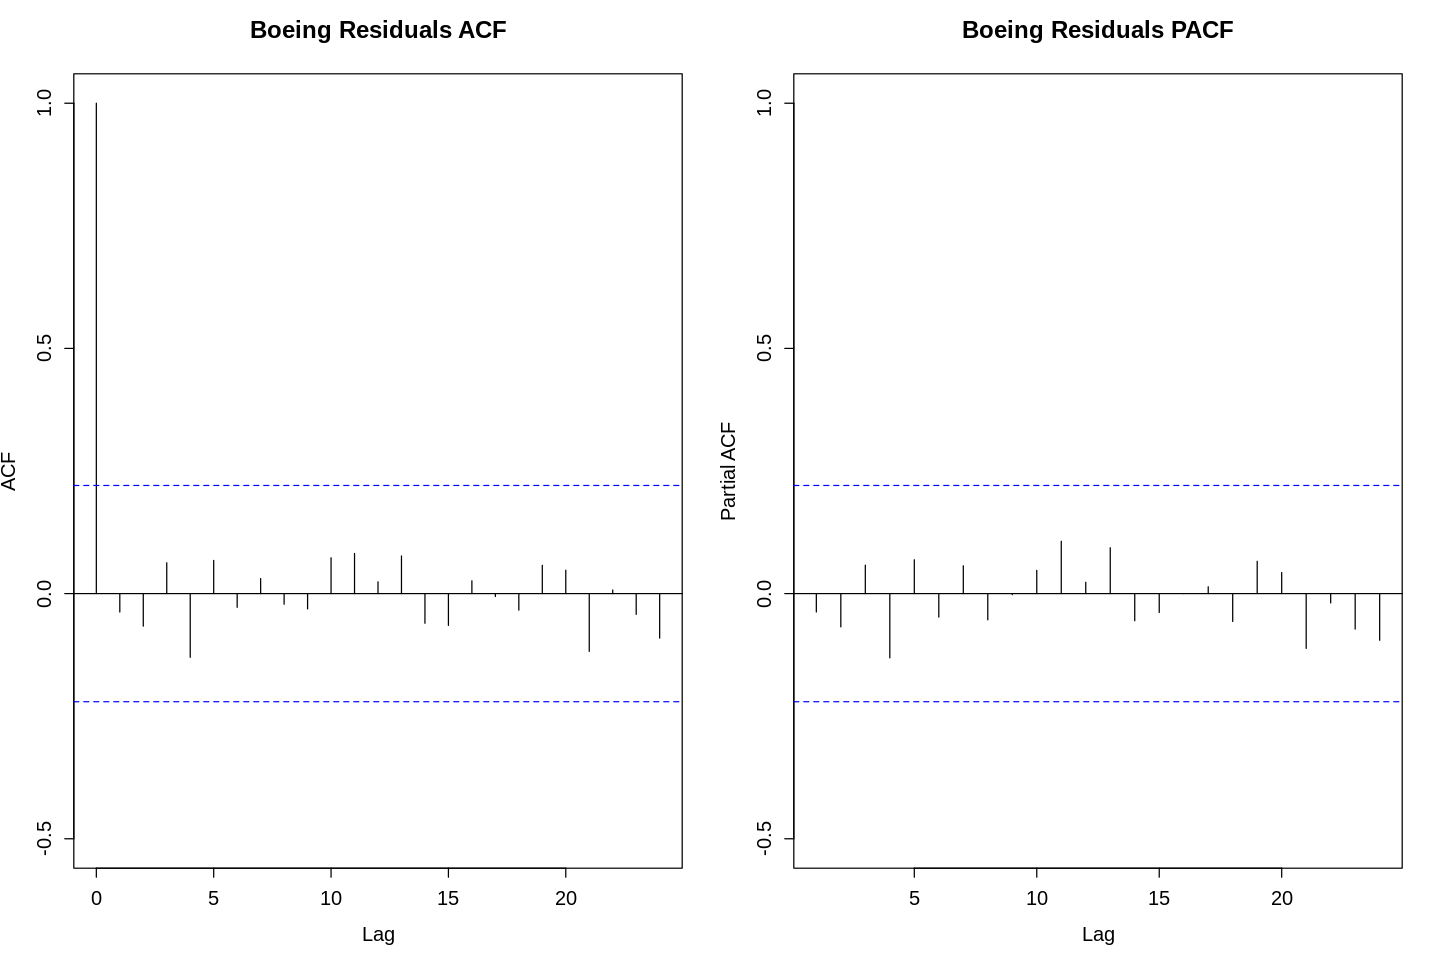

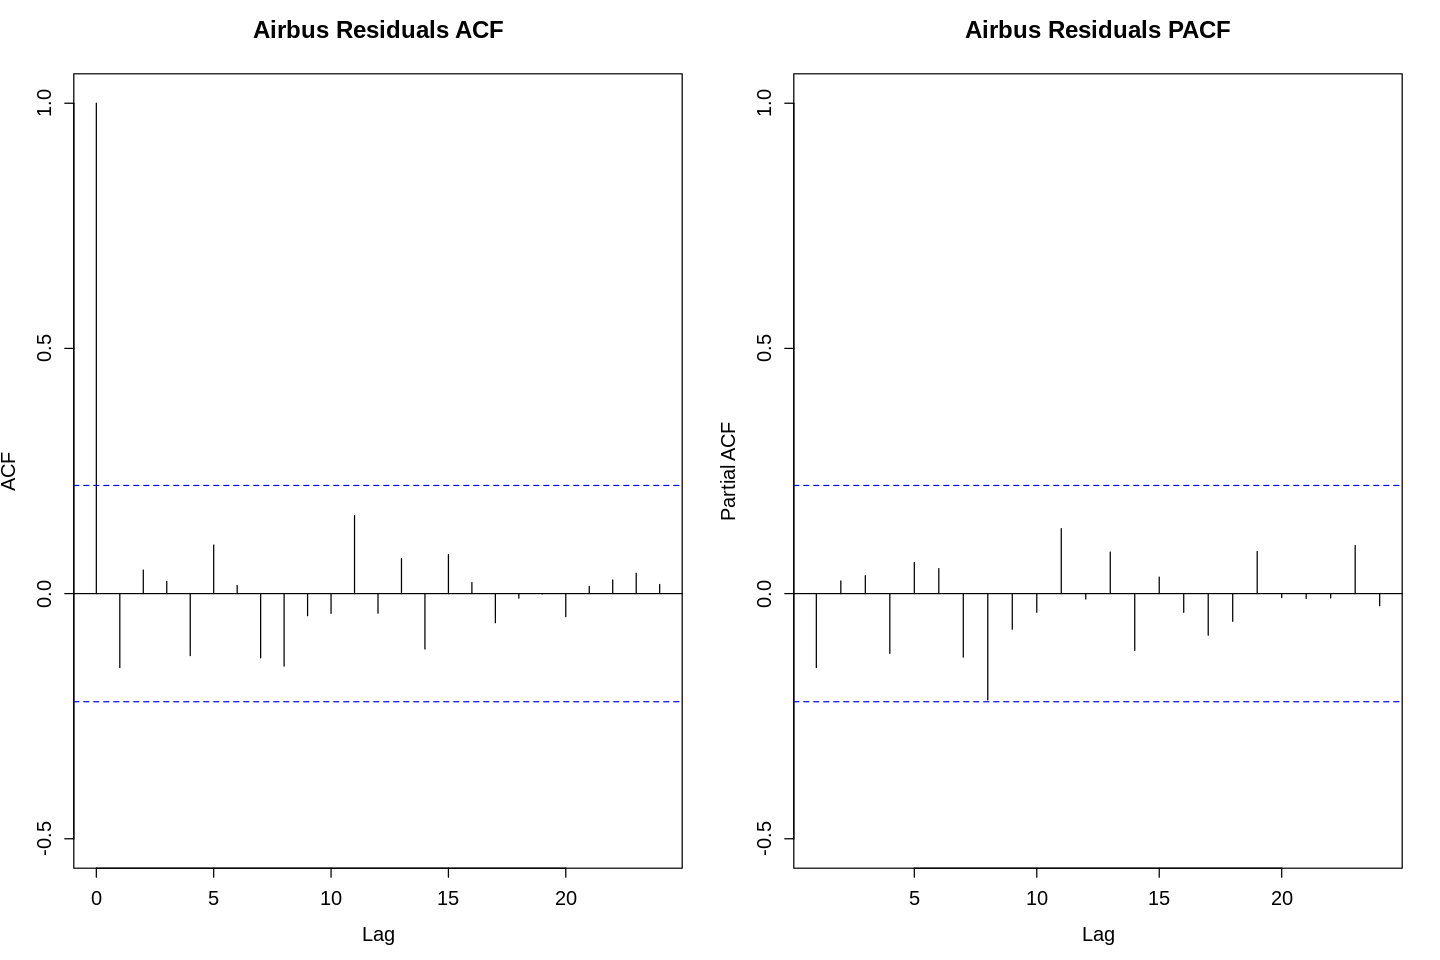

In [240]:
# Lag plots of ARIMAX residuals
w.t_b <- residuals(boeing_best_fit)
w.t_a <- residuals(airbus_best_fit)

par(mfrow = c(1,2), mex = 0.75)
acf(w.t_b, ylim = c(-0.5, 1), lag.max = 24,
    main = "Boeing Residuals ACF")
pacf(w.t_b, ylim = c(-0.5, 1), lag.max = 24,
     main = "Boeing Residuals PACF")
par(mfrow = c(1,1))

par(mfrow = c(1,2), mex = 0.75)
acf(w.t_a, ylim = c(-0.5, 1), lag.max = 24,
    main = "Airbus Residuals ACF")
pacf(w.t_a, ylim = c(-0.5, 1), lag.max = 24,
     main = "Airbus Residuals PACF")
par(mfrow = c(1,1))

These residuals also resemble white noise, which is promising.

Boeing Mean and s.d.,-0.00495,0.05011
Airbus Mean and s.d.,-0.01848,0.08956


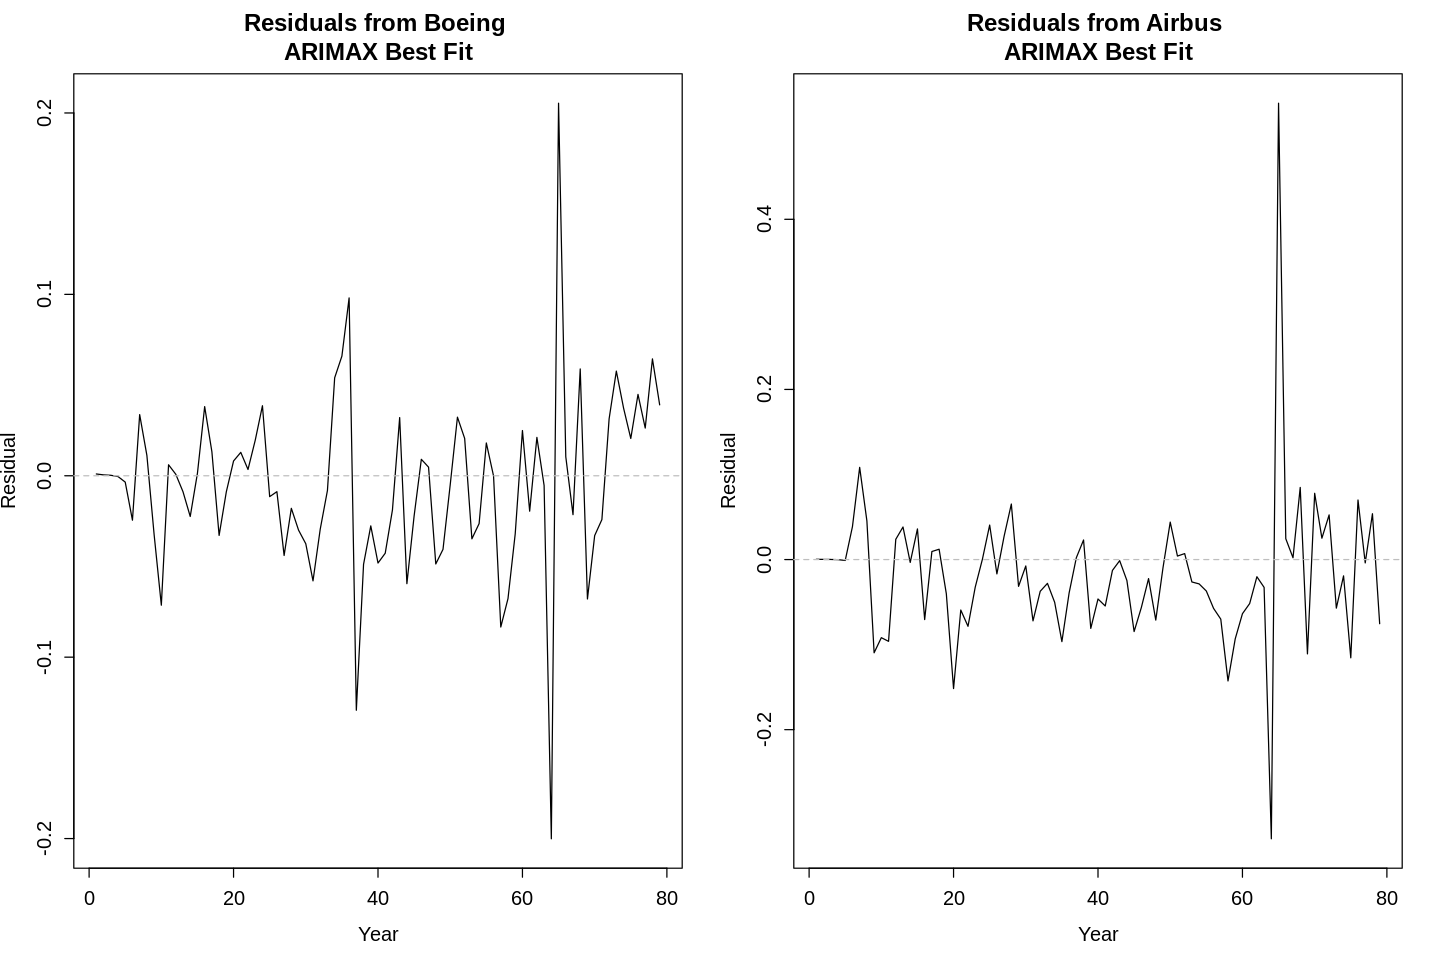

In [241]:
w_mean_b <- mean(w.t_b)
w_mean_a <- mean(w.t_a)
w_sd_b <- sd(w.t_b)
w_sd_a <- sd(w.t_a)

rbind(cbind("Boeing Mean and s.d.",round(w_mean_b, 5), round(w_sd_b,5)),
cbind("Airbus Mean and s.d.", round(w_mean_a,5), round(w_sd_a,5)))

par(mfrow = c(1, 2), mex = 0.75)
plot.ts(w.t_b,
        main = "Residuals from Boeing \nARIMAX Best Fit",
        xlab = "Year",
        ylab = "Residual")
abline(h = 0, col = "grey", lty = "dashed")
plot.ts(w.t_a,
        main = "Residuals from Airbus \nARIMAX Best Fit",
        xlab = "Year",
        ylab = "Residual")
abline(h = 0, col = "grey", lty = "dashed")

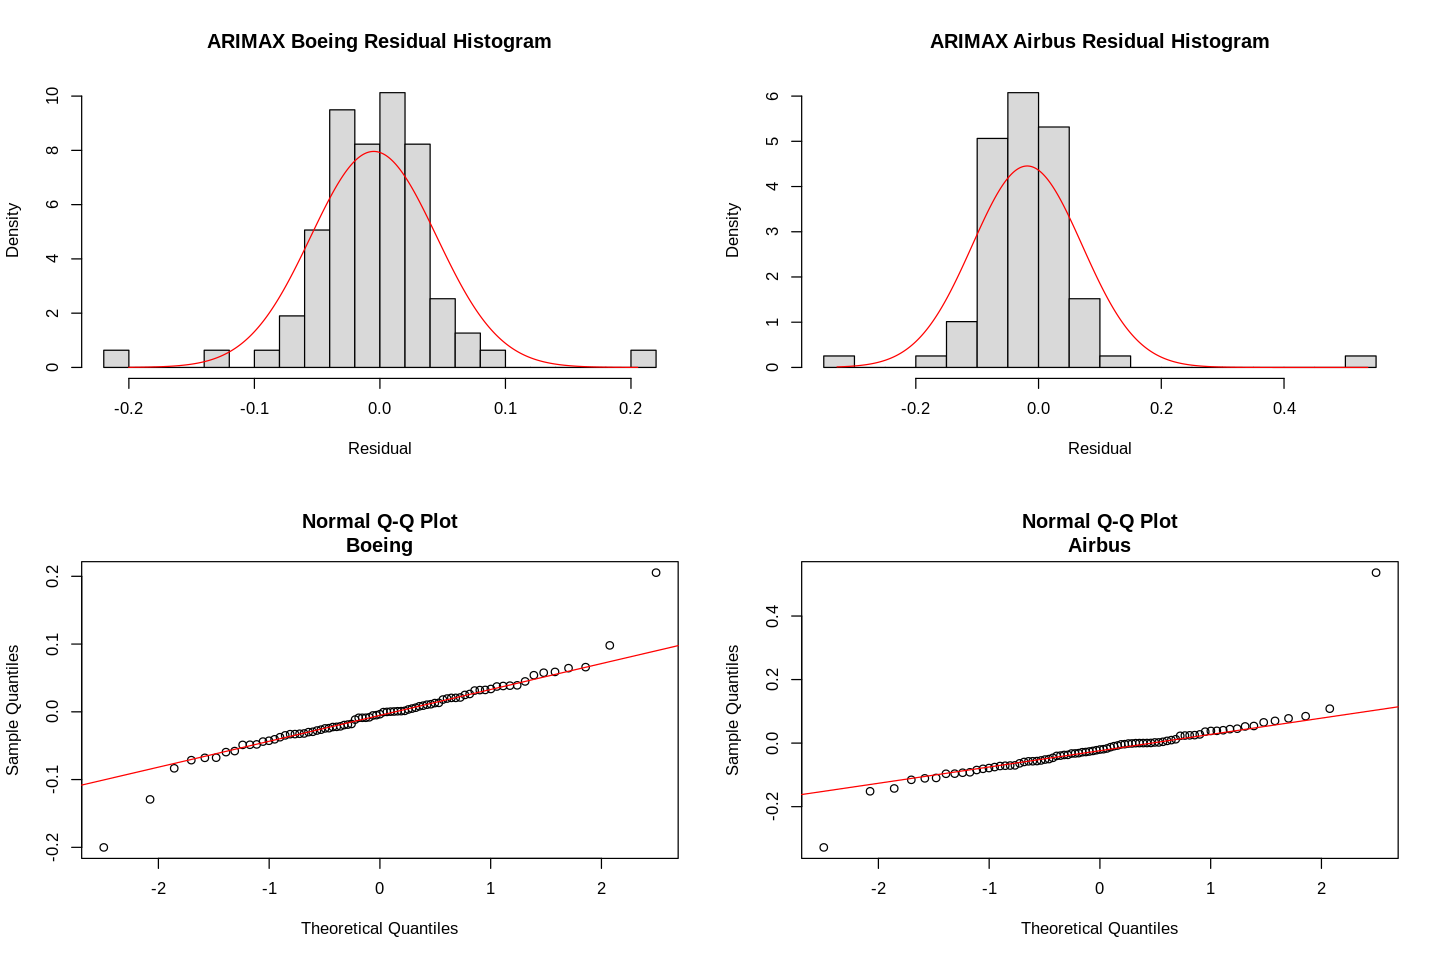

In [242]:
par(mfcol = c(2, 2))
hist(w.t_b,
     freq = FALSE,
     breaks = 15,
     col = "grey85",
     main = "ARIMAX Boeing Residual Histogram",
     xlab = "Residual")

z <- seq(min(w.t_b), max(w.t_b), length = 1000)

lines(z,
      dnorm(z, mean = w_mean_b, sd = w_sd_b),
      col = "red")

qqnorm(w.t_b)

qqline(w.t_b, col = "red")
title("Boeing", line = 0.5)

hist(w.t_a,
     freq = FALSE,
     breaks = 15,
     col = "grey85",
     main = "ARIMAX Airbus Residual Histogram",
     xlab = "Residual")

z <- seq(min(w.t_a), max(w.t_a), length = 1000)

lines(z,
      dnorm(z, mean = w_mean_a, sd = w_sd_a),
      col = "red")

qqnorm(w.t_a)
qqline(w.t_a, col = "red")
title("Airbus", line = 0.5)

In [243]:
cat("\nBoeing Normality Tests ----------------------------")
n_par_b <- length(coef(boeing_best_fit))
Box.test(w.t_b, lag = 8,  type = "Ljung-Box", fitdf = n_par_b)
Box.test(w.t_b, lag = 12, type = "Ljung-Box", fitdf = n_par_b)
shapiro.test(w.t_b)

cat("\nAirbus Normality Tests ----------------------------")
n_par_a <- length(coef(airbus_best_fit))
Box.test(w.t_a, lag = 8,  type = "Ljung-Box", fitdf = n_par_a)
Box.test(w.t_a, lag = 12, type = "Ljung-Box", fitdf = n_par_a)
shapiro.test(w.t_a)


Boeing Normality Tests ----------------------------


	Box-Ljung test

data:  w.t_b
X-squared = 2.8425, df = 0, p-value < 2.2e-16



	Box-Ljung test

data:  w.t_b
X-squared = 4.1113, df = 4, p-value = 0.3912



	Shapiro-Wilk normality test

data:  w.t_b
W = 0.91417, p-value = 5.657e-05



Airbus Normality Tests ----------------------------


	Box-Ljung test

data:  w.t_a
X-squared = 7.8494, df = 1, p-value = 0.005084



	Box-Ljung test

data:  w.t_a
X-squared = 10.717, df = 5, p-value = 0.0573



	Shapiro-Wilk normality test

data:  w.t_a
W = 0.74489, p-value = 2.109e-10


In [244]:
arimax_coef_table <- function(fit) {
  cf  <- coef(fit)
  se  <- sqrt(diag(fit$var.coef))
  z   <- cf / se
  p   <- 2 * (1 - pnorm(abs(z)))
  round(data.frame(Estimate=cf, SE=se, z=z, p=p,
                   CI_lo=cf-1.96*se, CI_hi=cf+1.96*se), 4)
}

cat("Boeing")
arimax_coef_table(boeing_best_fit)
cat("\nAirbus")
arimax_coef_table(airbus_best_fit)

Boeing

,Estimate,SE,z,p,CI_lo,CI_hi
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ar1,-0.2600,0.1462,-1.7786,0.0753,-0.5465,0.0265
ma1,-0.7243,0.1119,-6.4747,0.0000,-0.9436,-0.5051
sma1,-1.0000,0.0951,-10.5130,0.0000,-1.1864,-0.8135
log_ops,0.0678,0.0448,1.5144,0.1299,-0.0200,0.1556
log_util,-0.4203,0.0982,-4.2812,0.0000,-0.6127,-0.2279
log_ncar,0.1496,0.0982,1.5244,0.1274,-0.0428,0.3420
shock,0.2782,0.0351,7.9270,0.0000,0.2094,0.3470
recovery,-0.0998,0.0634,-1.5739,0.1155,-0.2241,0.0245



Airbus

,Estimate,SE,z,p,CI_lo,CI_hi
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ma1,-0.6711,0.0869,-7.7236,0.0000,-0.8414,-0.5008
sma1,-1.0000,0.4349,-2.2991,0.0215,-1.8525,-0.1475
log_ops,0.2221,0.0904,2.4564,0.0140,0.0449,0.3994
log_util,-0.4720,0.1457,-3.2403,0.0012,-0.7575,-0.1865
log_ncar,-0.0973,0.2084,-0.4669,0.6405,-0.5058,0.3112
shock,0.4838,0.0722,6.6998,0.0000,0.3423,0.6253
recovery,-0.0524,0.1164,-0.4499,0.6528,-0.2805,0.1757


**Four Quarter Forecast**

In [245]:
# Get next n quarters for boeing
n_ahead_forecast <- length(x.t_test)
pred_times_vector <- as.numeric(time(x.t_test))
pred_times <- data.frame(TIME_POINT = pred_times_vector)

# Construct newxreg for Boeing
# (use past predictor values for future maintainace cost prediction)
fit_boeing_ops <- lm(log_ops~TIME_POINT, data = df_sarima_b)
fit_boeing_util <-lm(log_util~TIME_POINT, data = df_sarima_b)
fit_boeing_ncar <-lm(log_ncar~TIME_POINT, data = df_sarima_b)

newxreg_boeing <- matrix(
  c(predict(fit_boeing_ops, pred_times),
    predict(fit_boeing_util, pred_times),
    predict(fit_boeing_ncar, pred_times),
    rep(0, n_ahead_forecast), # for shock
    rep(0, n_ahead_forecast)), # for recovery (All these are 0 because we don't expeck a shock)
  nrow = n_ahead_forecast, ncol = 5, byrow = FALSE
)
colnames(newxreg_boeing) <- colnames(xreg_b_fit)

prd_boeing <- predict(boeing_best_fit, n.ahead = n_ahead_forecast, newxreg = newxreg_boeing)

log_fc_boeing <- prd_boeing$pred # These are on log scale
log_se_boeing <- prd_boeing$se   # These are on log scale

# Point forecast (mean, bias-corrected for log-normal distribution)
fc_boeing <- exp(log_fc_boeing + 0.5 * log_se_boeing^2)

# Prediction intervals on original scale
lower_boeing <- exp(log_fc_boeing - 1.96 * log_se_boeing)
upper_boeing <- exp(log_fc_boeing + 1.96 * log_se_boeing)

# and airbus
# Construct newxreg for Airbus
fit_airbus_ops <-  lm(log_ops~TIME_POINT, data = df_sarima_a)
fit_airbus_util <- lm(log_util~TIME_POINT, data = df_sarima_a)
fit_airbus_ncar <- lm(log_ncar~TIME_POINT, data = df_sarima_a)

newxreg_airbus <- matrix(
  c(predict(fit_airbus_ops, pred_times),
    predict(fit_airbus_util, pred_times),
    predict(fit_airbus_ncar, pred_times),
    rep(0, n_ahead_forecast),
    rep(0, n_ahead_forecast)),
  nrow = n_ahead_forecast, ncol = 5, byrow = FALSE
)
colnames(newxreg_airbus) <- colnames(xreg_a_fit)

prd_airbus <- predict(airbus_best_fit, n.ahead = n_ahead_forecast, newxreg = newxreg_airbus)

log_fc_airbus <- prd_airbus$pred # These are on log scale
log_se_airbus <- prd_airbus$se   # These are on log scale

# Point forecast (mean, bias-corrected for log-normal distribution)
fc_airbus <- exp(log_fc_airbus + 0.5 * log_se_airbus^2) # Correct scale for predictions

# Prediction intervals on original scale
lower_airbus <- exp(log_fc_airbus - 1.96 * log_se_airbus)
upper_airbus <- exp(log_fc_airbus + 1.96 * log_se_airbus)

**Plot Predictions**

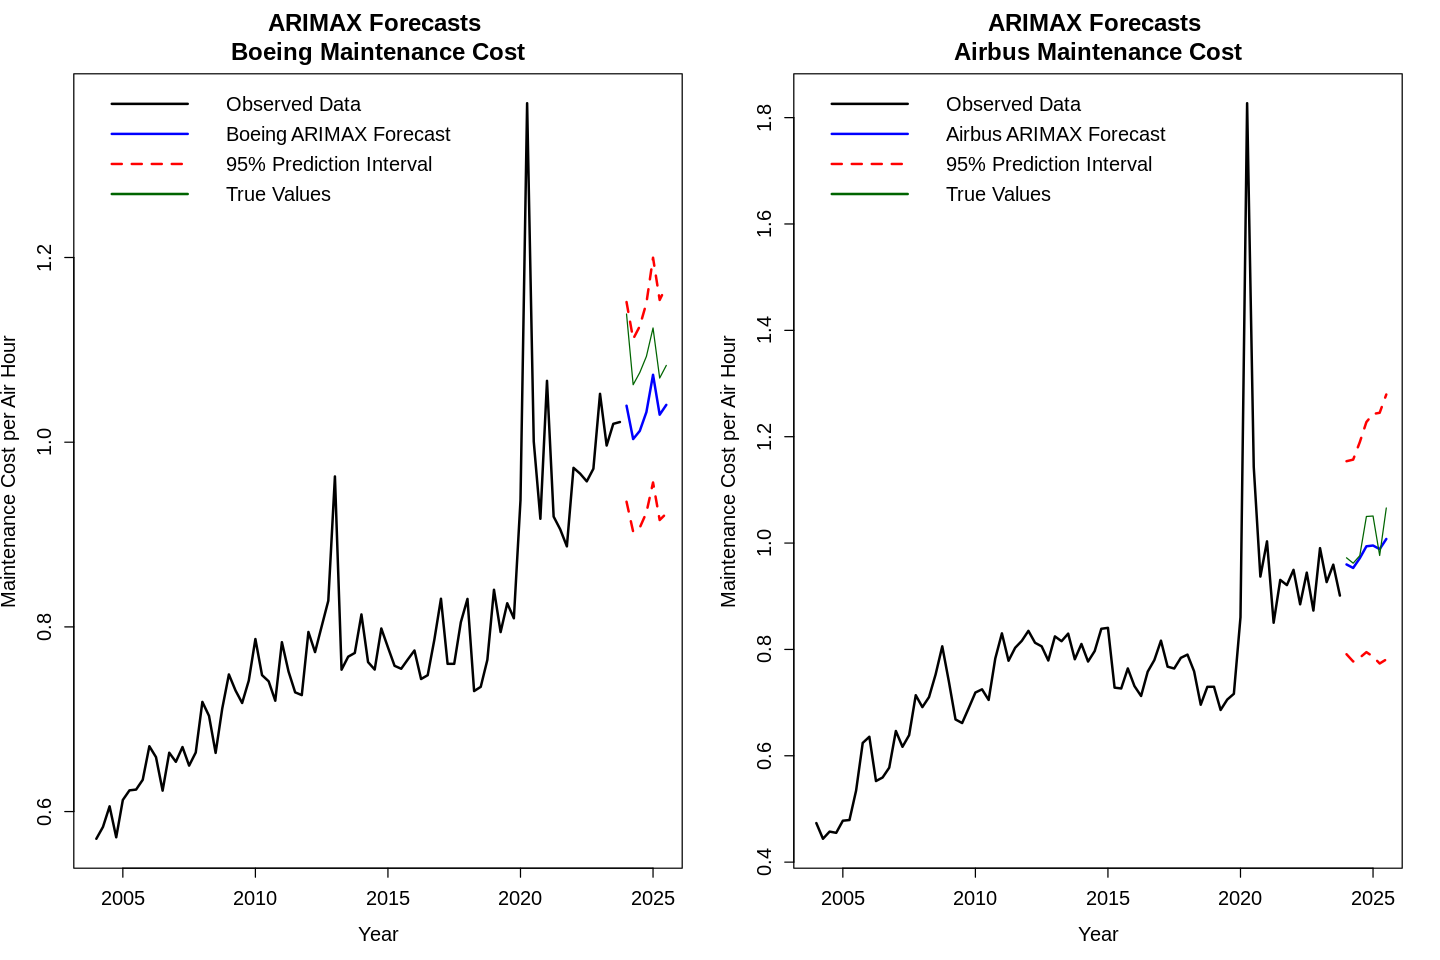

In [246]:
# Get forecast series
fc_start_boeing <- tsp(y_b)[2] + 1/4
fc_boeing_ts <- ts(fc_boeing, start = fc_start_boeing, frequency = 4)
lower_boeing_ts <- ts(lower_boeing, start = fc_start_boeing, frequency = 4)
upper_boeing_ts <- ts(upper_boeing, start = fc_start_boeing, frequency = 4)

fc_start_airbus <- tsp(y_a)[2] + 1/4
fc_airbus_ts <- ts(fc_airbus, start = fc_start_airbus, frequency = 4)
lower_airbus_ts <- ts(lower_airbus, start = fc_start_airbus, frequency = 4)
upper_airbus_ts <- ts(upper_airbus, start = fc_start_airbus, frequency = 4)

par(mfrow = c(1,2), mex = 0.75)

# Boeing ARIMAX Plot
plot.ts(y_b,
        xlim = c(start(y_b)[1], end(y_b)[1] + n_ahead_forecast/4 + 0.5),
        main = "ARIMAX Forecasts \nBoeing Maintenance Cost",
        xlab = "Year",
        ylab = "Maintenance Cost per Air Hour",
        col = "black",
        lwd = 2)

lines(fc_boeing_ts, col = "blue", lwd = 2)
lines(lower_boeing_ts, col = "red", lty = 2, lwd = 2)
lines(upper_boeing_ts, col = "red", lty = 2, lwd = 2)
lines(x.t_test, col = "dark green")

legend("topleft",
       legend = c("Observed Data", "Boeing ARIMAX Forecast", "95% Prediction Interval", "True Values"),
       col = c("black", "blue", "red", "dark green"),
       lty = c(1, 1, 2),
       lwd = c(2, 2, 2),
       bty = "n")

# Airbus ARIMAX Plot
plot.ts(y_a,
        xlim = c(start(y_a)[1], end(y_a)[1] + n_ahead_forecast/4 + 0.5),
        main = "ARIMAX Forecasts \nAirbus Maintenance Cost",
        xlab = "Year",
        ylab = "Maintenance Cost per Air Hour",
        col = "black",
        lwd = 2)

lines(fc_airbus_ts, col = "blue", lwd = 2)
lines(lower_airbus_ts, col = "red", lty = 2, lwd = 2)
lines(upper_airbus_ts, col = "red", lty = 2, lwd = 2)
lines(x.t_test_airbus, col = "dark green")


legend("topleft",
       legend = c("Observed Data", "Airbus ARIMAX Forecast", "95% Prediction Interval", "True Values"),
       col = c("black", "blue", "red", "dark green"),
       lty = c(1, 1, 2),
       lwd = c(2, 2, 2),
       bty = "n")

par(mfrow = c(1,1))

# Comparison of Predictions

~A plot that compares 7 quarters worth of maintainance cost per air hour over time for SARIMA, ARIMAX, NN

In [266]:
RNN_fct_raw <- read.csv(text = "Manufacturer,Forecast_Horizon,Predicted_MAINT_PER_AIR_HR
 AIRBUS,T+1,1.057
 AIRBUS,T+2,1.0635
 AIRBUS,T+3,1.0759
 AIRBUS,T+4,1.0897
 AIRBUS,T+5,1.1011
 AIRBUS,T+6,1.1071
 AIRBUS,T+7,1.1067
 BOEING,T+1,1.057
 BOEING,T+2,1.0635
 BOEING,T+3,1.0759
 BOEING,T+4,1.0897
 BOEING,T+5,1.1011
 BOEING,T+6,1.1071
 BOEING,T+7,1.1067") %>%
  mutate(Manufacturer = trimws(Manufacturer))
RNN_fct_a <- ts(RNN_fct_raw %>% filter(Manufacturer == "AIRBUS") %>% select(-Forecast_Horizon, -Manufacturer),
    start = c(2024,1), frequency = 4)
RNN_fct_b <- ts(RNN_fct_raw %>% filter(Manufacturer == "BOEING") %>% select(-Forecast_Horizon, -Manufacturer),
    start = c(2024,1), frequency = 4)

RNN_fct_b

,Qtr1,Qtr2,Qtr3,Qtr4
2024,1.0570,1.0635,1.0759,1.0897
2025,1.1011,1.1071,1.1067,


In [272]:
# Calcutate RMSE and MAPE of ARIMAX values and compare with SARIMA
error_boeing_ARIMAX <- fc_boeing - as.numeric(x.t_test)
error_airbus_ARIMAX <- fc_airbus - as.numeric(x.t_test_airbus)

error_boeing_rnn <- RNN_fct_b - as.numeric(x.t_test)
error_airbus_rnn <- RNN_fct_a - as.numeric(x.t_test_airbus)

# Boeing
rmse_boeing_rnn <- sqrt(mean(error_boeing_rnn^2, na.rm = TRUE))
mae_boeing_rnn  <- mean(abs(error_boeing_rnn), na.rm = TRUE)

rmse_boeing_ARIMAX <- sqrt(mean(error_boeing_ARIMAX^2, na.rm = TRUE))
mae_boeing_ARIMAX  <- mean(abs(error_boeing_ARIMAX), na.rm = TRUE)

# Airbus
rmse_airbus_ARIMAX <- sqrt(mean(error_airbus_ARIMAX^2, na.rm = TRUE))
mae_airbus_ARIMAX  <- mean(abs(error_airbus_ARIMAX), na.rm = TRUE)

rmse_airbus_rnn <- sqrt(mean(error_airbus_rnn^2, na.rm = TRUE))
mae_airbus_rnn  <- mean(abs(error_airbus_rnn), na.rm = TRUE)

# Create the data frame with full precision results
results_full <- data.frame(
  Model = c("Boeing SARIMA", "Boeing ARIMAX", "Airbus SARIMA", "Airbus ARIMAX", "Boeing RNN", "Airbus RNN" ),
  RMSE = c(rmse_boeing, rmse_boeing_ARIMAX, rmse_airbus, rmse_airbus_ARIMAX, rmse_boeing_rnn, rmse_airbus_rnn),
  MAE  = c(mae_boeing, mae_boeing_ARIMAX, mae_airbus, mae_airbus_ARIMAX, mae_boeing_rnn, mae_airbus_rnn)
)

# Create a new data frame for printing with rounded numeric columns
results_display <- data.frame(
  Model = results_full$Model,
  RMSE = round(results_full$RMSE, 4),
  MAE = round(results_full$MAE, 4)
)

results_display

Model,RMSE,MAE
<chr>,<dbl>,<dbl>
Boeing SARIMA,0.0794,0.0656
Boeing ARIMAX,0.0620,0.0592
Airbus SARIMA,0.0585,0.0452
Airbus ARIMAX,0.0378,0.0297
Boeing RNN,0.0362,0.0244
Airbus RNN,0.0847,0.0781


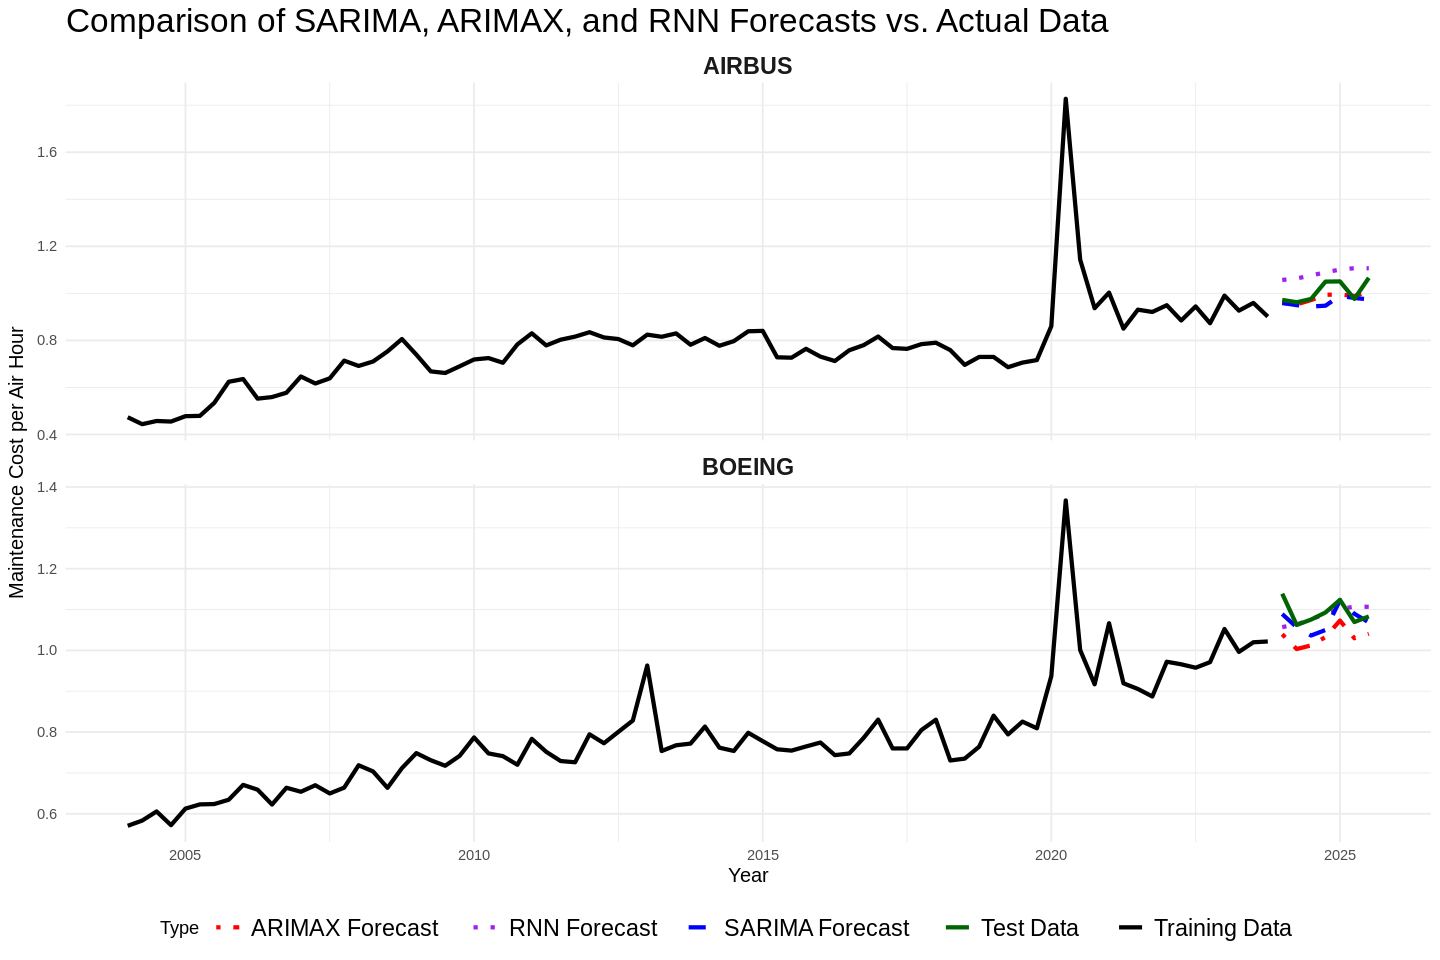

In [270]:
# Ensure SARIMA Airbus forecast is a time series object for plotting consistency
fc_start_airbus_sarima <- tsp(y.t_airbus)[2] + 1/4
fc.ts_airbus <- ts(fc_airbus_sarima, start = fc_start_airbus_sarima, frequency = 4)

# Prepare data frames for plotting

# Boeing data
boeing_train_data <- data.frame(
  Time = as.numeric(time(y.t)),
  Value = as.numeric(y.t),
  Type = "Training Data",
  Manufacturer = "BOEING"
)

boeing_test_data <- data.frame(
  Time = as.numeric(time(x.t_test)),
  Value = as.numeric(x.t_test),
  Type = "Test Data",
  Manufacturer = "BOEING"
)

boeing_sarima_forecast_data <- data.frame(
  Time = as.numeric(time(fc.ts)), # fc.ts is SARIMA Boeing forecast
  Value = as.numeric(fc.ts),
  Type = "SARIMA Forecast",
  Manufacturer = "BOEING"
)

boeing_arimax_forecast_data <- data.frame(
  Time = as.numeric(time(fc_boeing_ts)), # fc_boeing_ts is ARIMAX Boeing forecast
  Value = as.numeric(fc_boeing_ts),
  Type = "ARIMAX Forecast",
  Manufacturer = "BOEING"
)

boeing_rnn_forecast_data <- data.frame(
  Time = as.numeric(time(RNN_fct_b)), # RNN_fct_b is RNN Boeing forecast
  Value = as.numeric(RNN_fct_b),
  Type = "RNN Forecast",
  Manufacturer = "BOEING"
)

# Airbus data
airbus_train_data <- data.frame(
  Time = as.numeric(time(y.t_airbus)),
  Value = as.numeric(y.t_airbus),
  Type = "Training Data",
  Manufacturer = "AIRBUS"
)

airbus_test_data <- data.frame(
  Time = as.numeric(time(x.t_test_airbus)),
  Value = as.numeric(x.t_test_airbus),
  Type = "Test Data",
  Manufacturer = "AIRBUS"
)

airbus_sarima_forecast_data <- data.frame(
  Time = as.numeric(time(fc.ts_airbus)), # fc.ts_airbus is SARIMA Airbus forecast
  Value = as.numeric(fc.ts_airbus),
  Type = "SARIMA Forecast",
  Manufacturer = "AIRBUS"
)

airbus_arimax_forecast_data <- data.frame(
  Time = as.numeric(time(fc_airbus_ts)), # fc_airbus_ts is ARIMAX Airbus forecast
  Value = as.numeric(fc_airbus_ts),
  Type = "ARIMAX Forecast",
  Manufacturer = "AIRBUS"
)

airbus_rnn_forecast_data <- data.frame(
  Time = as.numeric(time(RNN_fct_a)), # RNN_fct_a is RNN Airbus forecast
  Value = as.numeric(RNN_fct_a),
  Type = "RNN Forecast",
  Manufacturer = "AIRBUS"
)

# Combine all data into one long format data frame for ggplot
all_forecast_data <- bind_rows(
  boeing_train_data, boeing_test_data, boeing_sarima_forecast_data,
  boeing_arimax_forecast_data, boeing_rnn_forecast_data,
  airbus_train_data, airbus_test_data, airbus_sarima_forecast_data,
  airbus_arimax_forecast_data, airbus_rnn_forecast_data
) %>% filter(Time <= max(boeing_rnn_forecast_data$Time))


# Plotting
ggplot(all_forecast_data, aes(x = Time, y = Value, color = Type)) +
  geom_line(aes(linetype = Type), size = 1.2) +
  facet_wrap(~ Manufacturer, scales = "free_y", ncol = 1) + # Set ncol to 1 to stack plots vertically
  scale_color_manual(values = c("Training Data" = "black", "Test Data" = "darkgreen",
                                "SARIMA Forecast" = "blue", "ARIMAX Forecast" = "red",
                                "RNN Forecast" = "purple")) +
  scale_linetype_manual(values = c("Training Data" = "solid", "Test Data" = "solid",
                                   "SARIMA Forecast" = "dashed", "ARIMAX Forecast" = "dotdash",
                                   "RNN Forecast" = "dotted")) +
  labs(title = "Comparison of SARIMA, ARIMAX, and RNN Forecasts vs. Actual Data",
       x = "Year",
       y = "Maintenance Cost per Air Hour") +
  theme_minimal() +
  theme(legend.position = "bottom", legend.text=element_text(size=14),
  plot.title = element_text(size=20),axis.title=element_text(size=12),
  strip.text = element_text(size = 14, face = "bold"))